# Исследование рынка общественного питания в Москве

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации](#1)
2. [<b>Предварительная обработка данных](#2)
    <br>[2.1. Проверка на дубликаты](#2.1)
    <br>[2.2. Проверка пропущенных значений](#2.2)
    <br>[2.3. Преобразование типов данных](#2.3)
    <br>[2.4. Добавление столбца `street` с названиями улиц](#2.4)
    <br>[2.5. Добавление столбца `day` и столбца `time` с данными о дне недели и времени работы заведения](#2.5)
    <br>[2.6. Добавление столбца `is_24/7` с данными о круглосуточном режиме работы заведения](#2.6)
    <br>[2.7. Добавление столбца `distance` с данными о расстоянии от центра города Москвы до заведения](#2.7)
    <br>[2.8. Обработка признака сетевых объектов `chain`](#2.8)
3. [<b>Исследовательский анализ данных](#3)
    <br>[3.1. Объекты общественного питания в разрезе категорий](#3.1)
    <br>[3.2. Количество посадочных мест в разрезе категории объекта общественного питания](#3.2)
    <br>[3.3. Соотношение сетевых и несетевых заведений](#3.3)
    <br>[3.4. Сетевые объекты общественного питания в разрезе категорий](#3.4)
    <br>[3.5. Популярные сети общественного питания в Москве (топ-15)](#3.5)
    <br>[3.6. Объекты общественного питания по административным районам](#3.6)
    <br>[3.7. Распределение средних рейтингов по категориям заведений](#3.7)
    <br>[3.8. Средний рейтинг объектов общественного питания в разрезе административных районов Москвы](#3.8)
    <br>[3.9. Обобщённая карта-схема объектов общественного питания Москвы](#3.9)
    <br>[3.10. Популярные улицы по количеству объектов общественного питания (топ-15)](#3.10)
    <br>[3.11. Одна улица - один объект общественного питания](#3.11)
    <br>[3.12. Средний чек объекта общественного питания в разрезе административного района](#3.12)
    <br>[3.13. Низкорейтинговые заведения как зона роста](#3.13)
    <br>[3.14. График работы заведений и его зависимость от расположения и категории заведения](#3.14)
    <br>[3.15. Бизнес-рекомендации](#3.15)
5. [<b>Детализация исследования: открытие кофейни](#4)
    <br>[4.1. Кофейня на карте: количество и расположение](#4.1)
    <br>[4.2. Круглосуточные кофейни](#4.2)
    <br>[4.3. Рейтинги кофеен в разрезе административных районов](#4.3)
    <br>[4.4. На какую стоимость чашки капучино стоит ориентироваться при открытии и почему?](#4.4)
6. [<b>Подготовка презентации для инвесторов](#5)
7. [<b>Выводы</b>](#6)

<a id=descr_proj></a>
## Описание проекта

Инвесторы из фонда «Shut Up and Take My Money» решили попробовать себя в новой области и открыть заведение общественного питания в Москве. Заказчики ещё не знают, что это будет за место: кафе, ресторан, пиццерия, паб или бар, — и какими будут расположение, меню и цены. Для начала они просят вас — аналитика — подготовить исследование рынка Москвы, найти интересные особенности и презентовать полученные результаты, которые в будущем помогут в выборе подходящего инвесторам места. Постарайтесь сделать презентацию информативной и лаконичной. Её структура и оформление сильно влияют на восприятие информации читателями вашего исследования. Выбирать инструменты (matplotlib, seaborn и другие) и типы визуализаций вы можете самостоятельно. Вам доступен датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках, и носит исключительно справочный характер.

<a id=descr_data></a>
## Описание данных
Исходный датафрейм `moscow_places.csv` является файлом, содержащим информацию об объектах общественного питания Москвы на летний период 2022 года в количестве 8406 срок на 14 столбцов.

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|:--------------------|:----------------|:--|:-----------------------|
|1. |`name`|название заведения|наименование |5614 уникальных наименований|
|2. |`address`|адрес заведения|физический адрес|5753 уникальных адресов |
|3. |`category`|категория типа заведения|кафе, ресторан, кофейня, пиццерия, бар/паб, быстрое питание, булочная, столовая|8 уникальных категорий|
|4. |`hours`|информация о днях и часах работы|дни недели вплоть до ежедневной работы и временной интервал вплоть до круглосуточной работы|1307 уникальных данных о днях и часах|
|5. |`lat`|географическкая широта|широта географической точки, в которой находится заведение|от 55.573942 до 55.928943|
|6. |`lng`|географическая долгота|долгота географической точки, в которой находится заведение|от 37.355651 до 37.874466|
|7. |`rating`|рейтинг|рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0)|от 1.0 до 5.0|
|8. |`price`|категория цен|низкие, средние, выше среднего, высокие|4 уникальных ценовых категории|
|9. |`avg_bill`|средняя стоимость заказа|средняя стоимость заказа в виде ценового диапазона, например: «Средний счёт: 1000–1500 ₽»; «Цена чашки капучино: 130–220 ₽»; «Цена бокала пива: 400–600 ₽».|897 уникальных данных о средней стоимости|
|10.|`middle_avg_bill`|средняя стоимость чека|число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»: <br>* если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений; <br>* если в строке указано одно число — цена без диапазона, то в столбец войдёт это число;<br>* если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.|230 уникальных данных стоимости среднего чека|
|11.|`middle_coffee_cup`|средняя стоимость чашки кофе|число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»: <br>* если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений; <br> * если в строке указано одно число — цена без диапазона, то в столбец войдёт это число; <br>* если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.|96 уникальных данных о средней стоимости чашки кофе|
|12.|`chain`|категория сетевой принадлежности|число, выраженное 0 или 1, которое показывает, является ли заведение сетевым <font color='red'>(для маленьких сетей могут встречаться ошибки)</font>|от 0 до 1|
|13.|`district`|административный район, в котором находится заведение|Восточный административный округ, Западный административный округ, Северный административный округ, Северо-Восточный административный округ, Северо-Западный административный округ, Центральный административный округ, Юго-Восточный административный округ, Юго-Западный административный округ, Южный административный округ|9 уникальных наименований|
|14.|`seats`|количество посадочных мест|штук|от 0 до 1288|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к вышеперечисленным датафреймам.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

In [1]:
# импорт библиотек
import pandas as pd 
import numpy as np
from numpy import sin, cos, arccos, pi, round
import seaborn as sns
import matplotlib.pyplot as plt
import json
import folium
from folium import Map, Choropleth, Marker
from folium.plugins import MarkerCluster
from geopy.distance import geodesic
import dataframe_image as dfi
from IPython.display import Image, display

# устанавливаем опцию вывода всех столбцов
pd.set_option('display.max_columns', None)

# устанавливаем опцию вывода максимальной ширины столбцов
pd.set_option('display.max_colwidth', None)

# устанавливаем форматирование отображения чисел типа float с двумя знаками после запятой
pd.options.display.float_format ='{:.2f}'.format

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

# настройка вывода визуализации
%matplotlib inline

In [2]:
# загрузка файла в датафрейм
try:
    rest = pd.read_csv('moscow_places.csv', sep=',')
except:
    rest = pd.read_csv('https://code.s3.yandex.net/datasets/moscow_places.csv', sep=',')

In [3]:
# выводим датафрейм для ознакомления
rest.head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,5.00,NaN,NaN,NaN,NaN,0,NaN
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,4.50,выше среднего,Средний счёт:1500–1600 ₽,1550.00,NaN,0,4.00
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",55.89,37.53,4.60,средние,Средний счёт:от 1000 ₽,1000.00,NaN,0,45.00
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.88,37.49,5.00,NaN,Цена чашки капучино:155–185 ₽,NaN,170.00,0,NaN
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.45,5.00,средние,Средний счёт:400–600 ₽,500.00,NaN,1,148.00


In [4]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков
rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8406 non-null   object 
 1   category           8406 non-null   object 
 2   address            8406 non-null   object 
 3   district           8406 non-null   object 
 4   hours              7870 non-null   object 
 5   lat                8406 non-null   float64
 6   lng                8406 non-null   float64
 7   rating             8406 non-null   float64
 8   price              3315 non-null   object 
 9   avg_bill           3816 non-null   object 
 10  middle_avg_bill    3149 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8406 non-null   int64  
 13  seats              4795 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 919.5+ KB


In [5]:
# выводим первичный статистический анализ по заказам и посетителям
rest.describe().astype(int)

,lat,lng,rating,middle_avg_bill,middle_coffee_cup,chain,seats
count,8406,8406,8406,3149,535,8406,4795
mean,55,37,4,958,174,0,108
std,0,0,0,1009,88,0,122
min,55,37,1,0,60,0,0
25%,55,37,4,375,124,0,40
50%,55,37,4,750,169,0,75
75%,55,37,4,1250,225,1,140
max,55,37,5,35000,1568,1,1288


**Выводы:** на этом этапе нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов. Осуществлена загрузка исходных данных методом `read_csv`. В работу поступил файл `moscow_places.csv`, содержащий данные о заведениях общественного питания Москвы. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа. 

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1></a>
### 2.1. Проверка на дубликаты

In [6]:
# расчёт количества и процентажа полных дубликатов
print('Всего в датафрейме', rest.duplicated().sum(), 'дубликатов, что в % составляет', 
      (rest.duplicated().sum() / len(rest)).round(3), 'от общего количества строк.')

Всего в датафрейме 0 дубликатов, что в % составляет 0.0 от общего количества строк.


In [7]:
# расчёт количества неполных дубликатов
rest = rest.drop_duplicates(subset = ['name', 'chain', 'category', 'address', 'lat', 'lng'], keep='first')
rest.shape

(8406, 14)

<a id=2.2></a>
### 2.2. Проверка пропущенных значений

In [8]:
# подсчитаем количество пропущенных значений в датафрейме
rest.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
lat                     0
district                0
address                 0
category                0
name                    0
rating                  0
lng                     0
chain                   0
dtype: int64


В данных на текущий момент имеются пропуски значений в 6 признаках из 14, при этом пропуски имеются в целевых признаках по количеству посадочных мест, графику работы, ценам и средним значениям заказа, чека, чашки кофе. В датафрейме пропусков в признаке `hours` насчитывается 536 позиций, в признаке `avg_bill` насчитывается 4590 позиций, равно как и по признакам `price` 5091 пропуск, `middle_avg_bill` 5257 пропуск, `middle_coffee_cup` 7871 пропуск. Поскольку эти данные отражают реальность и заполнены пользователями на основе их личного опыта, в данных условиях не представляется возможным ни заполнение этих пропусков синтетическими данными (к примеру, медианой), ни установление специальных `заглушек` (например, числа `8888`). Подобного рода манипуляции приведут к искажению данных, что в перспективе негативно скажется на финальных результатах исследования. Вышеперечисленные пропуски мы вынуждены оставить в исходном состоянии и количестве.

Одновременно с этим, признак `seats` несёт в себе сразу несколько видов искажений данных: имеются явные пропуски в данных и нулевое количество посадочных мест.

In [9]:
# выявим все типы заведений, в которых поличество посадочных мест в исходных данных было равно нулю
rest.loc[(rest['seats'] == 0)].category.value_counts()

category
кафе               44
кофейня            24
ресторан           20
быстрое питание    18
булочная           11
пиццерия           10
столовая            5
бар,паб             4
Name: count, dtype: int64

Помимо отсутствующих и нулевых значений, есть целый ряд объектов общественного питания, признак `seats` которых не соответствует законодательным нормам и требованиям. Ранее мы убедились, что медианные значения количества посадочных мест для всех присутствующих категорий объектов общественного питания находятся <b>в диапазоне от 50 до 86</b>.

Одновременно с этим, в соответствии с Московскими городскими строииельными нормами 4.14-98 от 1998 года с последующим дополнением и расширением типологии объектов общественного питания на основании ГОСТ Р 50762-2007 и ГОСТ 30389-2013, <b>нижняя граница количества посадочных мест соответствует 25 местам</b>. Выполнение этих требований юридическим лицом или индивидуальным предпринимателем, работающим в сфере общественного питания, <b>является обязательным</b> для получения ряда сертификатов и лицензий, делающих эту деятельность правомерной, а также обеспечивает более чёткое соответствие качества обслуживания уровню (классу) предприятия общественного питания.

In [10]:
# расчёт количества объектов, по которым в данных количество посадочных мест находится на грани нормативных 25 единиц
rest[(rest['seats'] < 25)].groupby('category').agg({'name': 'count'}).reset_index().sort_values(by='name', ascending=False)

,category,name
3,кафе,216
4,кофейня,125
6,ресторан,95
2,быстрое питание,86
5,пиццерия,82
1,булочная,36
0,"бар,паб",24
7,столовая,21


Таким образом, количество объектов общественного питания, по которым количество посадочных мест меньше нормативного, составляет 685 единиц. 

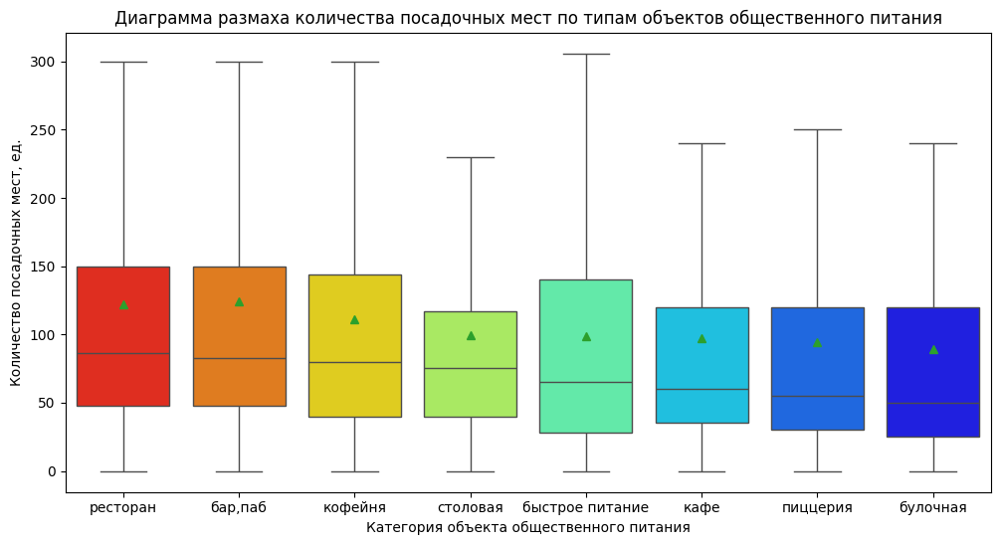

In [11]:
# визуализация медианы количества посадочных мест
# создадим ящик с усами по количеству посадочных мест в соответствии с типам объекта общественного питания
# dычисляем порядок категорий по убыванию медианного значения количества посадочных мест
order = rest.groupby('category')['seats'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=rest, y='seats', x='category', showmeans=True, palette='jet_r', showfliers=False, order=order).\
    set(xlabel='Категория объекта общественного питания', 
        ylabel='Количество посадочных мест, ед.', 
        title='Диаграмма размаха количества посадочных мест по типам объектов общественного питания')
plt.show()

Среди максимальных значений можно выделить группу объектов общественного питания, обладающих поистине огромными масштабами площадей, для которых оказание услуг по общественному питанию является только одним из многих направлений деятельности. В соответствии с диаграммой размаха, в первой группе "тяжеловесов" общественного питания находятся площадки массового пребывания людей, академические столовые и рестораны, кафе, кофейни при крупных гостиничных комплексах. Верхний порог значений для таких объектов начинается с отметки в 490 посадочных мест, иными словами На весь массив данных в 8404 записей таких объектов всего 85 единиц или 1%. Это значение чрезвычайно мало.

Во второй группе по количеству посадочных мест ожидаемо находятся рестораны, бары, кафе, кофейни, реже пиццерии и сети быстрого питания. Здесь количество посадочных мест варьируется от 60 до 490, и таких объектов всего 4749 единиц или 56.5%.

В третьей группе по количеству посадочных мест до 60 единиц находятся многочисленные кафе, рестораны, пиццерии, сети быстрого питания, булочные. Таких объектов 2191 или 26%.

Таким образом, мы можем принять решение о валидности больших значений количества посадочных мест в столбце 'seats' и использовать эти данные для дальнейшей работы. 

<a id=2.3></a>
### 2.3. Преобразование типов данных

In [12]:
# признак принадлежности к сетевому объекту изменяем на булев тип
rest = rest.replace({'chain' : {1:True, 0:False}})

In [13]:
# ознакомление с результатами преобразований
rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8406 non-null   object 
 1   category           8406 non-null   object 
 2   address            8406 non-null   object 
 3   district           8406 non-null   object 
 4   hours              7870 non-null   object 
 5   lat                8406 non-null   float64
 6   lng                8406 non-null   float64
 7   rating             8406 non-null   float64
 8   price              3315 non-null   object 
 9   avg_bill           3816 non-null   object 
 10  middle_avg_bill    3149 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8406 non-null   bool   
 13  seats              4795 non-null   float64
dtypes: bool(1), float64(6), object(7)
memory usage: 862.1+ KB


<a id=2.4></a>
### 2.4. Добавление столбца `street` с названиями улиц

In [14]:
# проверим наличие иных населённых пунктов в датафрейме
rest['address'].str.contains('Москва').sum()

np.int64(8406)

В данных представлены только московские точки питания, МО не включён в анализ. Всего в датафрейме имеются полные данные в количестве 8406 строк по адресным единицам, однако, указание на улицу как таковую встречается только в следующем количестве строк:

In [15]:
# расчёт количества вхождений слова `улица` в наименование адресной единицы
rest['address'].str.contains('улица').sum()

np.int64(4936)

Таким образом, только 59% адресов содержат название улицы как таковой. Предлагаем создать функцию для извлечения названия улицы из полного адреса объекта общественного питания и к ней список с ключевыми словами. Применим функцию к признаку `address ` и рассмотрим результаты.

In [16]:
# создадим список с ключевыми словами для извлечения улицы из полного адреса объекта
streets_names = ['улица', 'ул', 'ул.', 'шоссе', 'переулок', 'квартал', 'тупик', 'проезд', 'район',
                 'бульвар', 'проспект', 'пр-т', 'километр', 'линия', 'микрорайон', 'набережная', 'мост', 'вал', 
                 'площадь', 'территория', 'посёлок', 'поселение', 'просек', 'музей-заповедник', 
                 'парк', 'аллея', 'сквер', 'сад', 'лесопарк', 'бор', 'заказник']

In [17]:
# создадим функцию для извлечения названия улицы из полного адреса объекта
def get_street(address):
    for position in [0,1]: # список возможных позиций слова "улица" в полном названии адреса 
        for address_part in address.split(',')[position].split(' '): # разделим адрес на фрагменты между запятыми
            if address_part in streets_names:  # для каждорго фрагмента адреса найдём совпадение из списка с ключевыми словами 
                street = address.split(', ')[position] # присваиваем найденное значение переменной 'street'
                return street # возвращаем полученное значение улицы

In [18]:
# создадим новый признак `street` с названием улицы
# для этого применим ранее созданную функцию get_street к столбцу ['address'], где хранится полный адрес объекта
rest['street'] = rest['address'].apply(get_street)
rest[['address','street']].head()

,address,street
0,"Москва, улица Дыбенко, 7/1",улица Дыбенко
1,"Москва, улица Дыбенко, 36, корп. 1",улица Дыбенко
2,"Москва, Клязьминская улица, 15",Клязьминская улица
3,"Москва, улица Маршала Федоренко, 12",улица Маршала Федоренко
4,"Москва, Правобережная улица, 1Б",Правобережная улица


In [19]:
# количество пропусков в полученном признаке `street`
rest['street'].isna().sum()

np.int64(142)

После выделения улицы с помощью функции, в массиве данных осталось 142 строки, которые не содержат указанных выше вариантов наименований улицы либо слово улица находится в адресной строке дальше второй позиции. Для обработки пропусков по этому признаку отделим от основного датафрейма `rest` строки с `None` в признаке `street`, обработаем их и с помощью метода `concat` соединим заполненные данные.

In [20]:
# создаём датафрейм из строк с пропусками в признаке `street`
rest_street = rest[rest['street'].isna()]

In [21]:
# из основного датафрейма `rest` удаляем строки с пропусками в признаке `street`
rest = rest.dropna(subset=['street'])

In [22]:
# приступаем к заполнению пропусков в датафрейме `rest_street_check`
# ознакомление с уникальными значениями оставшихся адресов
rest_street['address'].unique()

array(['Москва, МКАД, 80-й километр, 1',
       'Москва, МКАД, 78-й километр, 14к1',
       'Москва, МКАД, 82-й километр, вл18',
       'Москва, МКАД, 87-й километр, 8',
       'Москва, МКАД, 87-й километр, 14',
       'Москва, Северный административный округ, Головинский район',
       'Москва, Северо-Западный административный округ, район Северное Тушино',
       'Москва, Северный административный округ, район Левобережный, территория парка Дружбы',
       'Москва, Северо-Восточный административный округ, район Отрадное',
       'Москва, Северо-Восточный административный округ, Останкинский район, Выставка достижений народного хозяйства, Кольцевая дорога',
       'Москва, Северо-Восточный административный округ, район Ростокино',
       'Москва, Северо-Восточный административный округ, Останкинский район, Выставка достижений народного хозяйства, Главная аллея',
       'Москва, Северо-Восточный административный округ, Останкинский район, территория парка Останкино, Останкинская аллея'

В своей массе выделяются значения `МКАД`, `административные округа` и ещё несколько единичных вкраплений адресных единиц.

In [23]:
# заполнение улиц по МКАД-у
location = ['МКАД']
rest_street_MKAD = rest_street[rest_street['address'].str.contains('|'.join(location))]
rest_street_MKAD['street'] = (rest_street['address'].str.split(', ').str[1])+\
', '+(rest_street['address'].str.split(', ').str[2])

In [24]:
# заполнение улиц административным округам, где указан полный адрес и где указан только район
location = ['Северный административный округ', 'Северо-Западный административный округ',
            'Северо-Восточный административный округ', 'Восточный административный округ',
            'Центральный административный округ', 'Западный административный округ',
            'Южный административный округ', 'Юго-Западный административный округ','Юго-Восточный административный округ']
rest_street_AO = rest_street[rest_street['address'].str.contains('|'.join(location))]
rest_street_AO['street'] = (rest_street['address'].str.split(', ').str[2])+\
', '+(rest_street['address'].str.split(', ').str[3])

# заполнение улиц административным округам, где указан только район
rest_street_AO_part = rest_street_AO[rest_street_AO['street'].isna()]
rest_street_AO = rest_street_AO.dropna(subset=['street'])

rest_street_AO_part = rest_street[rest_street['address'].str.contains('|'.join(location))]
rest_street_AO_part['street'] = (rest_street['address'].str.split(', ').str[2])

In [25]:
# заполним оставшиеся три уникальных значения адресов
rest_street.loc[(rest_street['address'] == 'Москва, № 7'), 'street'] = 'улица Нагорная, Спорткомплекc КАНТ, склон № 7'
rest_street.loc[(rest_street['address'] == 'Москва, Гагаринский тоннель'), 'street'] = 'Гагаринский тоннель'
rest_street.loc[(rest_street['address'] == 'Москва, Третье транспортное кольцо'), 'street'] = 'Третье транспортное кольцо'

# выделяем для соединения заполненные три строки с уникальными адресами
rest_street = rest_street.dropna(subset=['street'])

In [26]:
# объединение полученных массивов данных
rest = pd.concat([rest, rest_street_MKAD, rest_street_AO, rest_street_AO_part, rest_street])

In [27]:
# ознакомление с результатами преобразованиий
rest.head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,street
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,5.00,NaN,NaN,NaN,NaN,False,NaN,улица Дыбенко
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,4.50,выше среднего,Средний счёт:1500–1600 ₽,1550.00,NaN,False,4.00,улица Дыбенко
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",55.89,37.53,4.60,средние,Средний счёт:от 1000 ₽,1000.00,NaN,False,45.00,Клязьминская улица
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.88,37.49,5.00,NaN,Цена чашки капучино:155–185 ₽,NaN,170.00,False,NaN,улица Маршала Федоренко
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.45,5.00,средние,Средний счёт:400–600 ₽,500.00,NaN,True,148.00,Правобережная улица


In [28]:
# проверка результатов извлечения данных для создания признака `street`
rest['street'].isna().sum()

np.int64(0)

<a id=2.5></a>
### 2.5. Добавление столбца `day` и столбца `time` с данными о дне недели и времени работы заведения

In [29]:
# из общего признака `hours` выделяем в отдельные признаки день недели и время работы
rest['day'] = (rest['hours'].str.split(', ').str[0])
rest['time'] = (rest['hours'].str.split(', ').str[1])

<a id=2.6></a>
### 2.6. Добавление столбца `is_24/7` с данными о круглосуточном режиме работы заведения

In [30]:
# воспользуемся методом .assign()
# установим название столбца `allday` из-за присутствия математического символа деления в требуемом названии `is_24/7`
rest = rest.assign(allday=np.where((rest['day'] == 'ежедневно') & (rest['time'] == 'круглосуточно'), True, False))

In [31]:
# переименуем полученный столбец в соответствии с заданием
rest.rename(columns = {'allday' : 'is_24/7'}, inplace=True )

In [32]:
# ознакомление с результатами преобразований
rest.head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,street,day,time,is_24/7
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,5.00,NaN,NaN,NaN,NaN,False,NaN,улица Дыбенко,ежедневно,10:00–22:00,False
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,4.50,выше среднего,Средний счёт:1500–1600 ₽,1550.00,NaN,False,4.00,улица Дыбенко,ежедневно,10:00–22:00,False
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",55.89,37.53,4.60,средние,Средний счёт:от 1000 ₽,1000.00,NaN,False,45.00,Клязьминская улица,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",NaN,False
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.88,37.49,5.00,NaN,Цена чашки капучино:155–185 ₽,NaN,170.00,False,NaN,улица Маршала Федоренко,ежедневно,09:00–22:00,False
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.45,5.00,средние,Средний счёт:400–600 ₽,500.00,NaN,True,148.00,Правобережная улица,ежедневно,10:00–22:00,False


<a id=2.7></a>
### 2.7. Добавление столбца `distance` с данными о расстоянии от центра города Москвы до заведения

In [33]:
# координаты центра Москвы
moscow_center = (55.751244, 37.618423)

# расчёт расстояния между точками в километрах
rest['distance'] = [
    round(geodesic(moscow_center, (lat, lon)).km, 2) 
    for lat, lon in zip(rest['lat'], rest['lng'])
]

In [34]:
# выводим результат на ознакомление
rest.head()

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,street,day,time,is_24/7,distance
0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,5.00,NaN,NaN,NaN,NaN,False,NaN,улица Дыбенко,ежедневно,10:00–22:00,False,16.65
1,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.48,4.50,выше среднего,Средний счёт:1500–1600 ₽,1550.00,NaN,False,4.00,улица Дыбенко,ежедневно,10:00–22:00,False,16.21
2,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",55.89,37.53,4.60,средние,Средний счёт:от 1000 ₽,1000.00,NaN,False,45.00,Клязьминская улица,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00",NaN,False,16.41
3,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",55.88,37.49,5.00,NaN,Цена чашки капучино:155–185 ₽,NaN,170.00,False,NaN,улица Маршала Федоренко,ежедневно,09:00–22:00,False,16.63
4,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.45,5.00,средние,Средний счёт:400–600 ₽,500.00,NaN,True,148.00,Правобережная улица,ежедневно,10:00–22:00,False,17.93


<a id=2.8></a>
### 2.8. Обработка признака сетевых объектов `chain`

Поскольку нас уведомили о возможном наличии ошибок в отношении маленьких сетей питания, изучим этот признак подробнее. Сначала соберём данные по количеству сетевых объектов общественного питания.

In [35]:
# с помощью группировки данных и последовательных срезов мы можем выявить ошибки в части сетей питания и их названий
# топ-15 сетевых объектов до обработки признака `chain` 
chain_raw = rest.groupby('name').agg({'chain': 'count'}).sort_values(by='chain', ascending=False).head(15).reset_index()
chain_raw

,name,chain
0,Кафе,191
1,Шоколадница,120
2,Домино'с Пицца,76
3,Додо Пицца,74
4,One Price Coffee,71
5,Яндекс Лавка,69
6,Cofix,66
7,Prime,50
8,Хинкальная,44
9,Шаурма,43


In [36]:
# обработка ошибок в сетевой принадлежености: приведение к единообразию наименований объектов
# словарь приведения всех вариантов написания к уставному виду
name_mapping = {
    'Deli2Go': 'Deli2go', 'Wild bean cafe': 'Wild Bean Cafe', 'Даблби': 'ДаблБи',
    'Крошка картошка': 'Крошка Картошка', 'Правда Кофе': 'Правда кофе', 'Яндекс.Лавка': 'Яндекс Лавка',
    'ABC coffee roasters': 'ABC Coffee Roasters', 'Cofe Fest': 'CofeFest', 'Bổ': 'Bổ',
    'Free & Со': 'Free&co', 'Ho Cho Pho': 'Ho Chu Pho',
    'Jeffrey’s Coffeeshop': "Jeffrey's Coffeeshop", 'Korean chick': 'Korean Chick',
    'More poke': 'More Poke', 'One&double': 'One&Double', 'Poke House': 'Poke house',
    'Sova coffee': 'Sova Coffee', 'Star hit cafe': 'Star Hit Cafe',
    'Udcкафе Upside Down Cake': 'Udcкафе', 'Wave california poke': 'Wave California Poke',
    'Алло Пицца': 'Алло! Пицца', 'В парке вкуснее!': 'В парке вкуснее',
    "Домино'с": "Домино'с Пицца", "Домино'с пицца": "Домино'с Пицца", 'Доминос пицца': "Домино'с Пицца",
    'Донер хаус': 'Донер Хаус', 'Донер Хауз': 'Донер Хаус', 'Зарафшан': 'Зарафшон',
    'Кружкапаб': 'Кружка Паб', 'Ливан хаус': 'Ливан Хаус', 'Матрешка': 'Матрёшка',
    'Перекресток': 'Перекрёсток', 'Раковарня Клешни и Хвосты': 'Раковарня Клешни и хвосты',
    'Рамен-клаб': 'Рамен-Клаб', 'Старый Город': 'Старый город', 'Трапеза': 'ТрапеZа',
    'Трдельник': 'Трдельникъ', 'Халва, сеть почтоматов': 'Халва, Сеть Почтоматов',
    'Хинкали - Gали!': 'Хинкали-Gали!', 'Хинкали Gали': 'Хинкали-Gали!', 'Хинкали Gали!': 'Хинкали-Gали!',
    'Хинкали-Gaли': 'Хинкали-Gали!', 'Хинкали-Gали': 'Хинкали-Gали!',
    'Хлеб да выпечка': 'Хлеб да Выпечка', 'Чайхана Бишкек Сити': 'Чайхана Бишкек сити',
    'Bb grill': 'Bb Grill', 'Bb Grill': 'Bb Grill',
    'Carrots and beans': 'Carrots and Beans', 'Carrots and Beans': 'Carrots and Beans',
    'Di villaggio': 'Di Villaggio', 'Di Villaggio': 'Di Villaggio',
    'Han cook': 'Han Cook', 'Han Cook': 'Han Cook',
    'Hellopapaya': 'HelloPapaya', 'HelloPapaya': 'HelloPapaya',
    'IL pizzaiolo': 'IL Pizzaiolo', 'IL Pizzaiolo': 'IL Pizzaiolo',
    'Istanbul kebab': 'Istanbul Kebab', 'Istanbul Kebab': 'Istanbul Kebab',
    "It's СоТ - Кофейня": "It's СоТ-Кофейня", "It's СоТ-Кофейня": "It's СоТ-Кофейня",
    'Ku: рамен изакая бар': 'Ku: Рамен Изакая бар', 'Ku: Рамен Изакая бар': 'Ku: Рамен Изакая бар',
    'MainFood': 'Main Food', 'Main Food': 'Main Food',
    'Pasta cup & pizza': 'Pasta Cup & Pizza', 'Pasta Cup & Pizza': 'Pasta Cup & Pizza',
    'Pomodoro royal': 'Pomodoro Royal', 'Pomodoro Royal': 'Pomodoro Royal',
    'Saigon вьетнамская кухня': 'Saigon Bistro. Вьетнамская кухня', 'Saigon Bistro. Вьетнамская кухня': 'Saigon Bistro. Вьетнамская кухня',
    'Shake up': 'ShakeUp', 'ShakeUp': 'ShakeUp',
    'Авлабар': 'АвлаБар', 'АвлаБар': 'АвлаБар',
    'Аль Бухари': 'Аль-Бухари', 'Аль-Бухари': 'Аль-Бухари',
    'Важная персона': 'Важная Персона', 'Важная Персона': 'Важная Персона',
    'Вкусвилл, кафе': 'ВкусВилл, кафе', 'ВкусВилл, кафе': 'ВкусВилл, кафе',
    'Гастрорюмочная Шесть You Шесть': 'Гастрорюмочная Шесть-You-Шесть', 'Гастрорюмочная Шесть-You-Шесть': 'Гастрорюмочная Шесть-You-Шесть',
    'Глобус, ресторан': 'Глобус ресторан', 'Глобус ресторан': 'Глобус ресторан',
    'Гюмри хауз': 'Гюмри Хауз', 'Гюмри Хауз': 'Гюмри Хауз',
    'Донер & гриль': 'Донер & Гриль', 'Донер & Гриль': 'Донер & Гриль',
    'Здоровое питание': 'Здоровое Питание', 'Здоровое Питание': 'Здоровое Питание',
    'Иван Дурдинъ': 'Ив. Дурдинъ', 'Ив. Дурдинъ': 'Ив. Дурдинъ',
    'Кебаб Хауз': 'Кебаб Хаус', 'Кебаб-хауз': 'Кебаб Хаус', 'Кебаб Хаус': 'Кебаб Хаус',
    'Кофеin': 'КофеIN', 'КофеIN': 'КофеIN',
    'Между Булок': 'Между Булок', 'Между булок': 'Между Булок',
    'Новатор кофе': 'Новатор Кофе', 'Новатор Кофе': 'Новатор Кофе',
    'Новая Столовая': 'Новая Столовая', 'Новая столовая': 'Новая Столовая',
    'Нэм нэм': 'Нэм Нэм', 'Нэм Нэм': 'Нэм Нэм',
    'Ням-ням': 'Ням-Ням', 'Ням-Ням': 'Ням-Ням',
    'Семейная пекарня': 'Семейная Пекарня', 'Семейная Пекарня': 'Семейная Пекарня',
    'Токио рамен': 'Токио Рамен', 'Токио Рамен': 'Токио Рамен',
    'Хлеб Насущный экспресс': 'Хлеб Насущный Экспресс', 'Хлеб Насущный Экспресс': 'Хлеб Насущный Экспресс',
    'Центр плова': 'Центр Плова', 'Центр Плова': 'Центр Плова',
    'Чайхана ОШ сити': 'Чайхона ОШ Сити', 'Чайхона Ош сити': 'Чайхона ОШ Сити', 'Чайхона ОШ Сити': 'Чайхона ОШ Сити',
    'Чудо тандыр': 'Чудо Тандыр', 'Чудо Тандыр': 'Чудо Тандыр'
}

# векторизованная замена искажённых вариантов на уставные
rest['name'] = rest['name'].replace(name_mapping)

# присваиваем статус сетевых только тем объектам, которые совпадают с уставными названиями
rest.loc[rest['name'].isin(set(name_mapping.values())), 'chain'] = True

In [37]:
# после преобразований выполним повторную проверку на дубликаты
rest.duplicated().sum()

np.int64(0)

In [38]:
# удаляем неполные дубликаты
rest = rest.drop_duplicates(subset = ['name', 'chain', 'category', 'address', 'lat', 'lng'], keep='first')

In [39]:
# топ-15 сетевых объектов до и после обработки признака `chain` 
chain_clr = rest.groupby('name').agg({'chain': 'count'}).sort_values(by='chain', ascending=False).head(15).reset_index()
chain_clr = chain_clr.merge(chain_raw, on='name')
chain_clr.rename(columns = {'chain_x':'clear_data', 'chain_y':'raw_data'}, inplace = True)
chain_clr['diff_data'] = chain_clr['clear_data'] - chain_clr['raw_data']
chain_clr

,name,clear_data,raw_data,diff_data
0,Кафе,189,191,-2
1,Шоколадница,120,120,0
2,Домино'с Пицца,79,76,3
3,Додо Пицца,74,74,0
4,Яндекс Лавка,72,69,3
5,One Price Coffee,71,71,0
6,Cofix,65,66,-1
7,Prime,50,50,0
8,Хинкальная,44,44,0
9,Шаурма,43,43,0


In [40]:
# актуальный размер очищенного массива данных
rest.shape

(8404, 19)

In [41]:
# актуальная информация по признакам и типам данных
rest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8404 entries, 0 to 6309
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8404 non-null   object 
 1   category           8404 non-null   object 
 2   address            8404 non-null   object 
 3   district           8404 non-null   object 
 4   hours              7868 non-null   object 
 5   lat                8404 non-null   float64
 6   lng                8404 non-null   float64
 7   rating             8404 non-null   float64
 8   price              3314 non-null   object 
 9   avg_bill           3815 non-null   object 
 10  middle_avg_bill    3148 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8404 non-null   bool   
 13  seats              4794 non-null   float64
 14  street             8404 non-null   object 
 15  day                7868 non-null   object 
 16  time               5029 non-n

По итогу обработки признака сетевой принадлежности изменились количественные показатели сетевой принадлежности по объектам `Домино'с Пицца` (прирост на 3 точки до общего количества в 79 объектов) и `Яндекс Лавка` (прирост на 3 точки до общего количества в 72 объекта). Дублирующие строки по сетям `Кафе` и `Cofix` в общем количестве 3 штук были перезаписаны. Порядок расположения в топ-15 сетевых объектов не изменился.

**Вывод:** выполнена предварительная обработка данных. Проведена проверка на дубликаты полные и неполные по ряду ключевых признаков. Полных дубликатов в датафрейме нет, выявлено 2 неполных дубликата. По ряду признаков, а именно: `middle_coffee_cup`, `middle_avg_bill`, `price`, `avg_bill`, `seats`, `hours` в датафрейме имеются пропуски данных в количестве от 536 до 7871 позиций. Процедура восстановления значений синтетическими данными не представляется возможной в всязи с высокой вероятностью внесения существенных искажений данных.

Выполнено преобразование типов данных: в признаке `chain` значения стали булевыми, количество посадочных мест в соответствии с логикой приведены к целочисленному типу данных. В целях подготовки дополнительных признаков, позволяющих сделать исследование более глубоким и осмысленным, путём обработки признака `address` был добавлен признак `street` с информацией об улице, на которой расположен тот или иной объект общественного питания. Из комплесных данных признака `hours` были выделены день недели, время работы, формат круглосуточного режима доступа посетителей в заведение. На основании признаков широты и долготы и функции угла было рассчитано расстояние от центра города Москвы до заведения. Обработаны данные по сетевому признаку `chain`. 

<br>По итогам предвартельной обработки данных массив приобрёл размер 8404 строк на 19 столбцов. На этом этапе потери в данных составили 2 строки или 0.23%.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=3></a>
## Шаг 3. Исследовательский анализ данных

<a id=3.1></a>
### 3.1. Объекты общественного питания в разрезе категорий

In [42]:
# расчёт количества категорий в абсолютных и относительных показателях
category = rest.groupby(by='category').agg({'name':'count'}).reset_index().sort_values(by='name', ascending=False)
category['percent'] = category['name'] / len(rest) * 100
category

,category,name,percent
3,кафе,2378,28.30
6,ресторан,2042,24.30
4,кофейня,1413,16.81
0,"бар,паб",765,9.10
5,пиццерия,633,7.53
2,быстрое питание,602,7.16
7,столовая,315,3.75
1,булочная,256,3.05


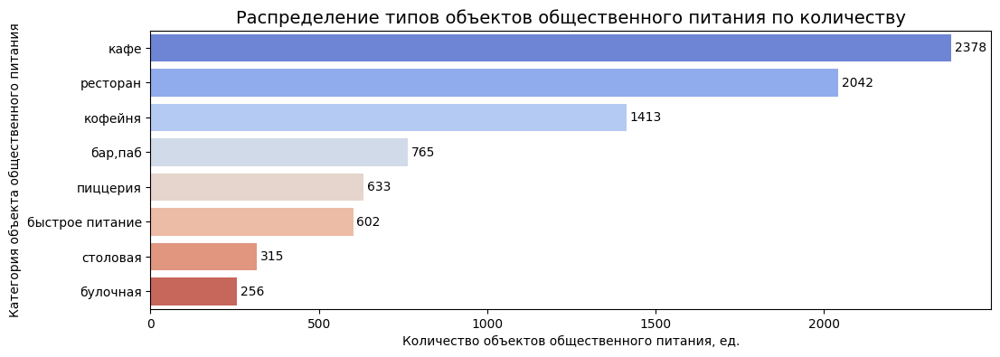

In [43]:
# создадим столбчатую диаграмму распределения типов объектов общественного питания по количеству
plt.figure(figsize=(12,4))
ax = sns.barplot(data=category, x='name', y='category', palette='coolwarm')

# подписи рядом со столбцами
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 10, p.get_y() + p.get_height() / 2, 
            f'{width:.0f}', ha='left', va='center', fontsize=10, color='black')
    
plt.title('Распределение типов объектов общественного питания по количеству', fontsize=14)
plt.ylabel('Категория объекта общественного питания')
plt.xlabel('Количество объектов общественного питания, ед.')
plt.show()

**Вывод:** самими многочисленными в массиве данных являются кафе, они занимают порядка 30% рынка общепита. Незначительную конкуренцию им могут составить рестораны, которые присутствуют в размере 24%. Тройку лидеров с большим отрывом замыкают кофейни, они составляют порядка 17% всех заведений общественного питания Москвы. Средний сегмент по численности включает в себя бары, пиццерии и объекты быстрого питания. Каждая из этих катгорий представлена порядка 600 - 700 объектами. Самые малочисленные, но со своей сложившейся аудиторией посетителей - столовые и булочные. В общем количестве объектов питания Москвы таких заведений насчитывается от 250 до 300.

Полученная диаграмма количественных значений наглядно иллюстрирует не просто популярность той или иной категории у посетителей как таковую, но и саму суть этой популярности: **градация объектов общественного питания основана на количестве времени, которое посетитель проводит на объекте, а также связана с уровнем эмоциональной вовлечённости посетителя в ходе визита.** Именно этот аспект станет критически важным для 4 шага данной исследовательской работы.

<a id=3.2></a>
### 3.2. Количество посадочных мест в разрезе категории объекта общественного питания

В нашем распоряжении имеется массив данных, в котором присутствует всего 8 категорий объектов общественного питания города Москва на период 2022 года: кафе, ресторан, кофейня, пиццерия, бар/паб, быстрое питание, булочная и столовая. Предлагаем методом срезов `query` исследовать количество посадочных мест по каждой категории.


 Описательная статистика количества посадочных мест по категориям: 



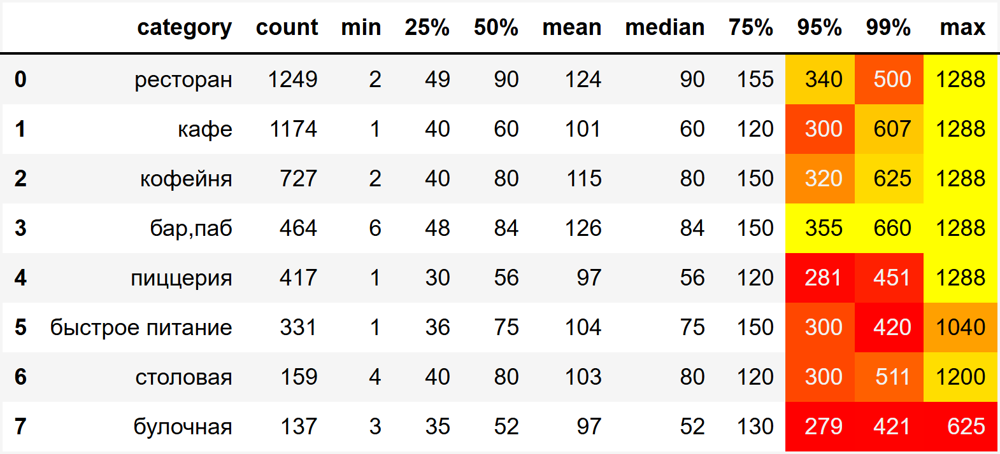

In [44]:
# описательная статистика признака количества посадочных мест в разрезе категорий
# фильтруем данные и исключаем пропущенные значения и нули
seats_cat = rest[rest['seats'].notna() & (rest['seats'] != 0)].reset_index(drop=True)

# базовая описательная статистка
seats_by_cat = seats_cat.groupby('category')['seats'].describe().sort_values(by='count', ascending=False).reset_index()

# вычисляем медиану и перцентили для каждой категории
grouped = seats_cat.groupby('category')['seats']
seats_by_cat['median'] = grouped.median().reindex(seats_by_cat['category']).values
seats_by_cat['95%'] = grouped.quantile(0.95).reindex(seats_by_cat['category']).values
seats_by_cat['99%'] = grouped.quantile(0.99).reindex(seats_by_cat['category']).values

# собираем и выводим исчерпывающие статистические данные
styled_table = seats_by_cat[['category', 'count', 'min', '25%', '50%', 'mean', 'median', '75%', '95%', '99%', 'max']].\
    style.background_gradient(subset=['95%', '99%', 'max'], cmap='autumn').format(precision=0)

# снимаем возможные CSS-ограничения высоты таблицы
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Описательная статистика количества посадочных мест по категориям: \n')

# экспорт изображения
dfi.export(styled_table, 'seats_by_cat_gradient.png', 
           table_conversion='chrome',      # бэкэнд рендеринга на базе Chromium
           max_rows=len(seats_by_cat),     # рендерим все строки в HTML
           fontsize=9,                     # оптимальный размер для широкой таблицы
           dpi=400)                        # высокая чёткость изображения

# отображение сохранённого изображения
display(Image(filename='seats_by_cat_gradient.png', width=600))

На полученной таблице агрегированных данных мы можем отметить, что 95-й перцентиль сильно варьируется: от 110 мест для булочных до 300+ мест для ресторанов и фудкортов.

In [45]:
# исследование по заведениям с максимальной посадкой
rest.query('seats > 1000')[['name', 'category', 'address', 'hours']].\
groupby('address').agg({'name':'count'}).sort_values(by='name', ascending=False)

,name
address,
"Москва, Измайловское шоссе, 71, корп. А",4
"Москва, проспект Вернадского, 121, корп. 1",3
"Москва, проспект Вернадского, 84, стр. 1",3
"Москва, проспект Вернадского, 97, корп. 1",2
"Москва, проспект Вернадского, 41, стр. 1",1
"Москва, Кутузовский проспект, 41, стр. 1",1
"Москва, проспект Вернадского, 51, стр. 1",1
"Москва, проспект Вернадского, 94, корп. 1",1


In [46]:
# исследование по заведениям с большой посадкой, вывод первых 10 строк для ознакомления
seast_big = rest.query('seats >= 200 & seats <1288')[['name', 'category', 'address', 'hours', 'chain']].\
groupby('address').agg({'name':'count', 'chain':'sum'}).sort_values(by='name',ascending=False).reset_index()
seast_big['percent'] = seast_big['chain'] / seast_big['name'] * 100
seast_big.head(10)

,address,name,chain,percent
0,"Москва, площадь Киевского Вокзала, 2",20,17,85.00
1,"Москва, Ярцевская улица, 19",20,16,80.00
2,"Москва, Пресненская набережная, 2",16,11,68.75
3,"Москва, Лесная улица, 20, стр. 3",16,6,37.50
4,"Москва, проспект Мира, 211, корп. 2",15,5,33.33
5,"Москва, улица Вавилова, 3",14,10,71.43
6,"Москва, Нижняя Красносельская улица, 35, стр. 59",11,4,36.36
7,"Москва, проспект Мира, 26, стр. 1",10,4,40.00
8,"Москва, Ленинградское шоссе, 16А, стр. 4",10,9,90.00
9,"Москва, Комсомольский проспект, 28",9,3,33.33


Объектов с максимальной посадкой на весь датафрейм - всего 11 адресов, объектов с большой посадкой - всего 375 адресов. Следовательно, мы имеем дело с 11 относительно новыми строениями, в которых <b>по типовому стандарту организованы большие зоны фудкортов</b>, на которых одномоментно могут пристутствовать до 20 различных объектов питания. Этот аргумент усилен дополнительным расчётом количества сетевых объектов общественного питания. Как мы видим на представленной выше таблице, количество сетевых заведений на таких объектах с общей большой зоной фудкорта составляет от 70% до 90%. 

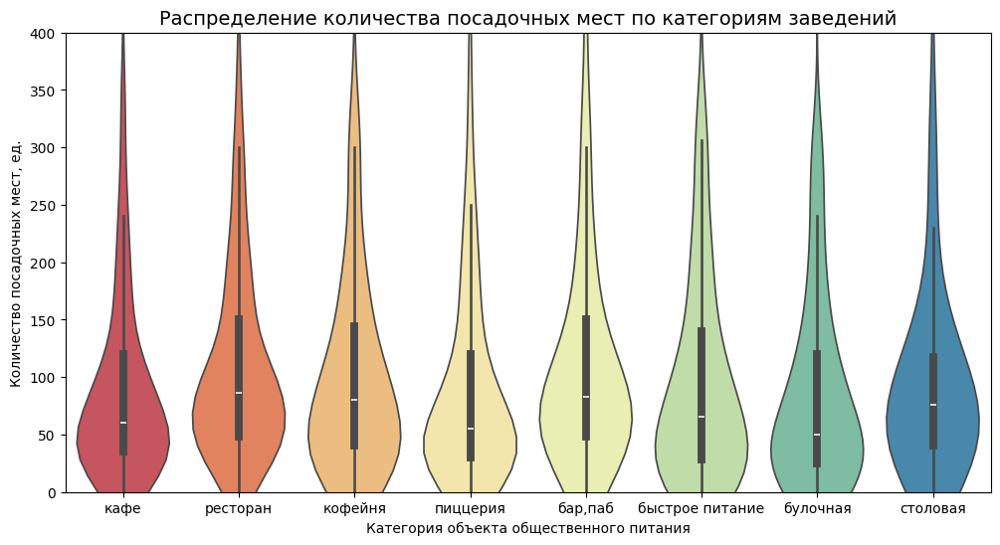

In [47]:
# визуализация распределения количества посадочных мест по категориям заведений
plt.figure(figsize=(12, 6))
plt.title('Распределение количества посадочных мест по категориям заведений', fontsize=14)
sns.violinplot(x= rest['category'], y=rest['seats'], palette='Spectral');
plt.ylabel('Количество посадочных мест, ед.')
plt.xlabel('Категория объекта общественного питания')
plt.ylim([0, 400]) # лимит по границе 99 перцентиля для булочной
plt.show()

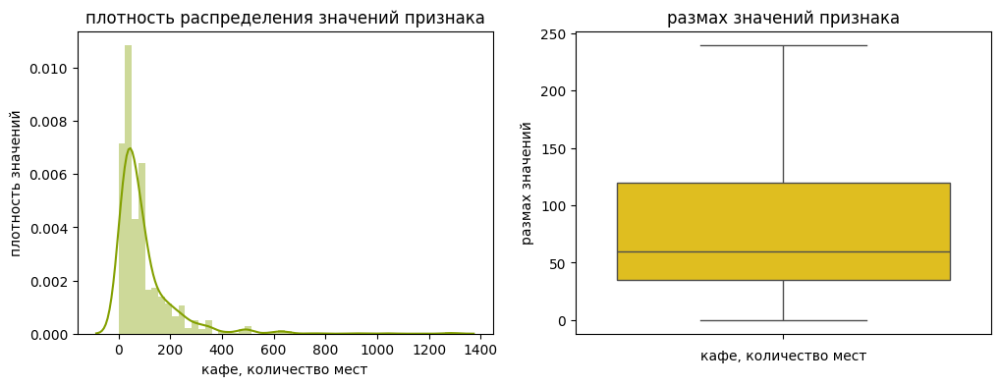

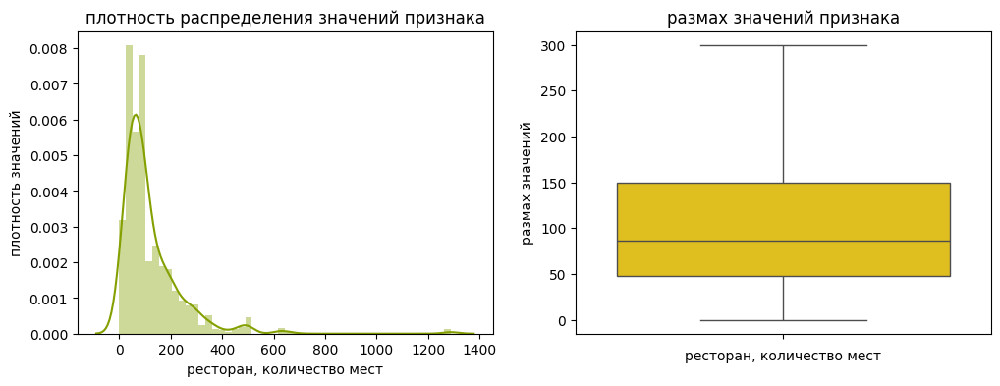

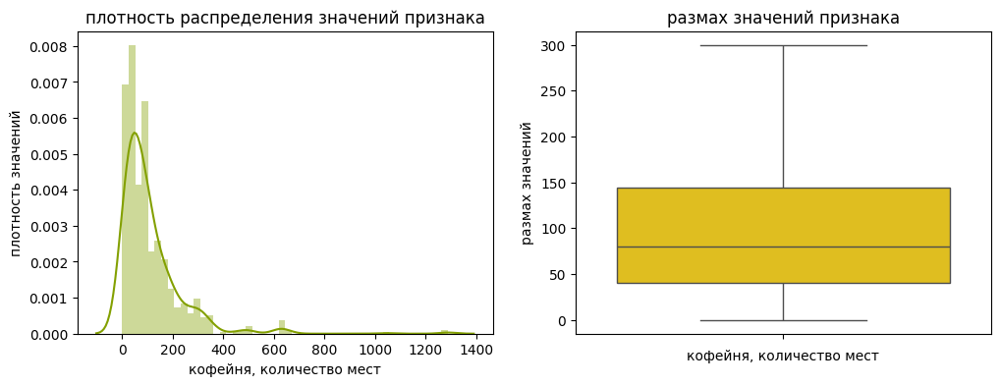

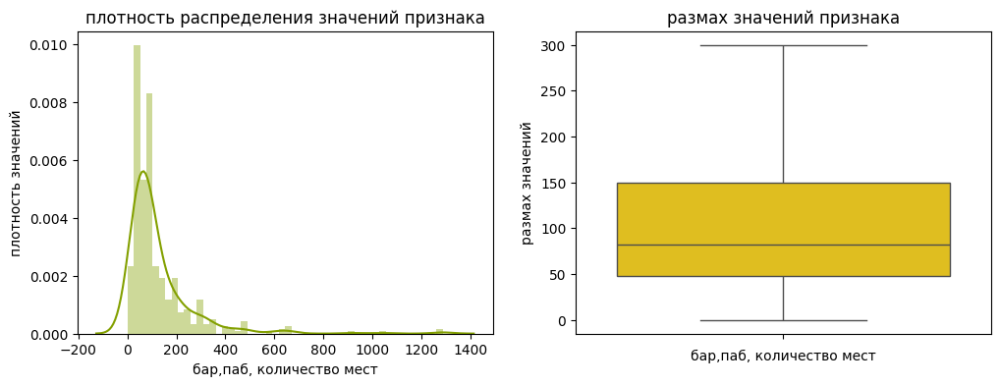

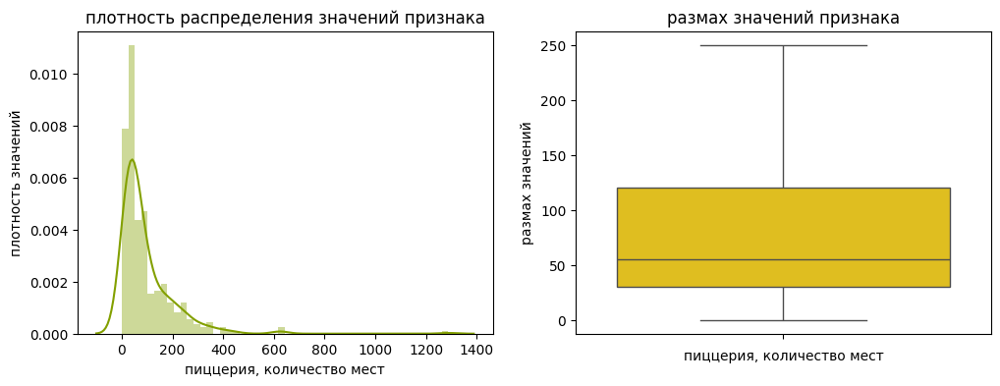

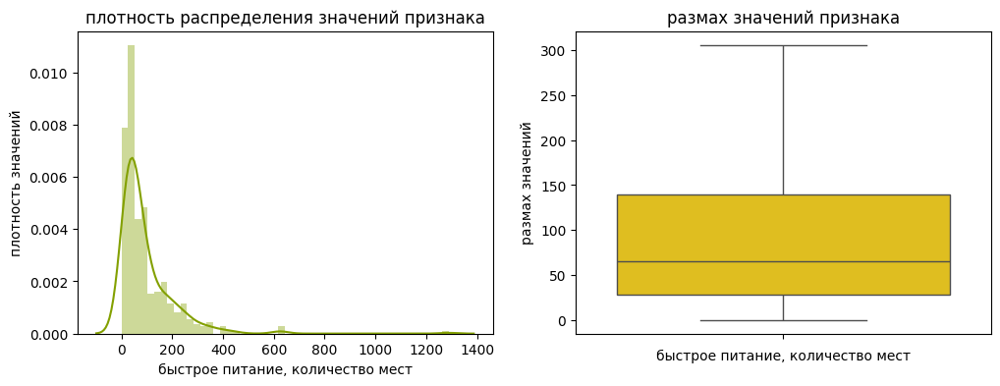

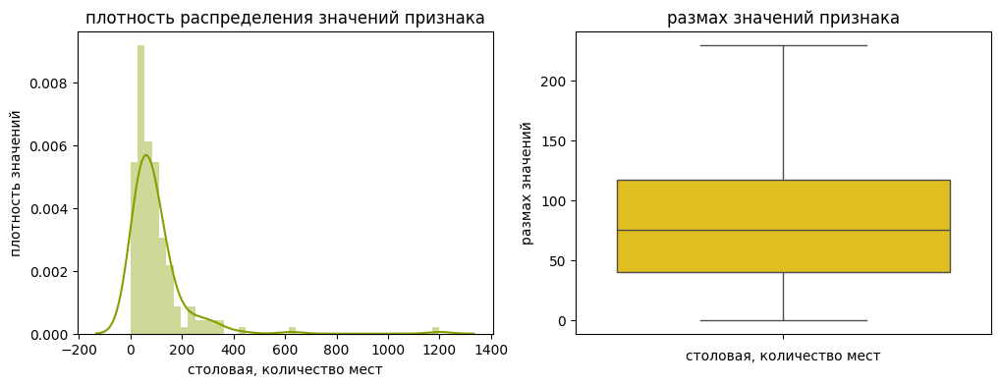

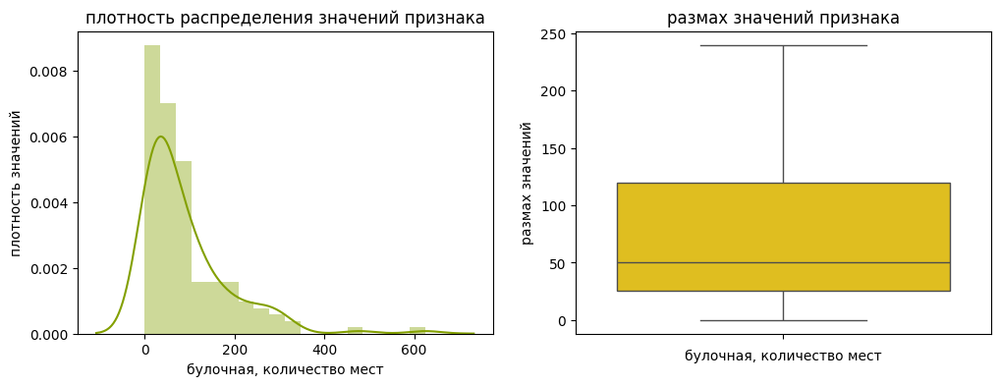

In [48]:
# парные диаграммы для всех категорий объектов общественного питания
# список с категориями заведений
categories = ['кафе', 'ресторан', 'кофейня', 'бар,паб', 'пиццерия', 'быстрое питание', 'столовая', 'булочная']

# цикл для вывода графиков
for i, category in enumerate(categories):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.title('плотность распределения значений признака')
    sns.distplot(rest.query(f'category == "{category}"')['seats'], color = '#83A000')\
    .set(ylabel='плотность значений', xlabel = f'{category}, количество мест')

    plt.subplot(1,2,2)
    plt.title('размах значений признака')
    sns.boxplot(y=rest.query(f'category == "{category}"')['seats'], color = '#FFD300', showfliers=False)\
    .set(ylabel='размах значений', xlabel = f'{category}, количество мест')
    plt.show()

**Выводы:** количество посадочных мест является одним из главных характерных признаков, позволяющих оценить "масштаб" деятельности как отдельного заведения, так и целой сети точек питания. Мини-заведения, в которых от одного до шести посадочных мест — самая малочисленная доля рынка общепита Москвы. В датафрейме таких заведений насчитывается 115 объектов, или ~1.4%. Считаем необходимым отметить, что малое количество посадочных мест не является признаком убыточности такого заведения: формат перекуса "кофе и булочка с собой" стал всемирным трендом. Посадку до 45 человек готовы предоставить порядка 41.6% всех объектов (в общем массиве данных насчитывается порядка 3500 таких заведений). Большинство заведений готовы принять одномоментно от 50 до 80 человек. Всего таких объектов питания порядка 3300 единиц, или 39%. Объекты с одновременной посадкой от 220 до 250 человек в большинстве своём представлены ресторанами и барами. Таких объектов всего 79, что составляет менее 1% общего массива данных. Многочисленная посадка гостей свыше 250 человек одновременно характерная для точек питания, присутствующих в крупных торгово-развлекательных с общей зоной фудкорта. На весь массив данных таких объектов насчитывается 400, что составляет 4.75%.

В разрезе каждой категории объекта общественного питания мы можем констатировать следующее:
* для категории `кафе` типовое количество посадочных мест находится в диапазоне от 30 до 60. Выше этой пороговой отметки находятся сетевые кафе с бошьшими зонами фудкортов, посадка на которых по объективным техническим причинам может исчисляться как сотнями, так и в редких случаях тысячами человек и достигать отметки 1288 мест.
* для категории `ресторан`самый распространённый вариант посадаки составляет диапазон от 75 до 100 мест. Выше отметки 100 - 120 мест находится люксовый сегмент и сетевые рестораны с большими зонами фудкортов. Выше отметки в 500 посадочных мест расположились сетевые рестораны в торговых и развлекательных центрах.
* `кофейни` в виду своей узкой специфики ассортимента по умолчанию не могут претендовать на большие значения количества посадочных мест. Распространённая норма посадки составляет порядка 80 - 90 мест. Эту тенденцию задают сетевые кофейни.
* для категории `бар/паб` распространённая норма посадки от 80 до 85 человек. В виду специфики ассортимента и возрастного ценза данный тип объекта общественного питания не может быть размещён в общедоступных торговых и развлекательных центрах, поэтому большие по количеству посадочных мест (более 300 единиц) бары или пабы встречаются довольно редко.
* `пиццерия` также является профилированной по ассортименту категорией объектов общественного питания и типовое количество посадки здесь находится в диапазоне от 50 до 80 мест. Все значения выше этой отметки мало характерны для этой категории. На весь массив данных таких "исключительно больших" по посадке пиццерий насчитывается всего лишь 157.
* рассчитанные на массового посетителя обхекты `быстрого питания` в большинстве своём готовы предложить от 60 до 80 посадочных мест единовременно. "Тяжеловесы" с большим количеством посадочных мест (до 350 единиц) размещены в торговых и развлекательных центрах.
* в `столовой` мы можем отметить сильную тенденцию к нормативности количества посадочных мест: от 75 до 80. Заведений в этой категории, готовых накормить одновременно более 80 человек - всего 70 объектов.
* `булочная`, предлагающая посетителям свежую ароматную выпечку, в основной массе ориентируется на 50 - 70 посадочных мест. история с маленьким количеством посадочных мест (менее 50 единиц) не характерна для этой категории объектов, на весь массив данных таких объектов насчитывается всего лишь 62. То же самое мы можем сказать и про булочные, где посадка больше 70 мест - таких объектов 64 штуки.

**Вне зависимости от категории, специфики, места расположения, графика работы и ценовой политики объекта общественного питания, для всех объектов общественного питания характерным является диапазон количества посадочных мест от 50 до 80 мест.**

<a id=3.3></a>
### 3.3. Соотношение сетевых и несетевых заведений

In [49]:
# расчёт соотношения сетевых и несетевых заведений в абсолютных значениях
rest['chain'].value_counts().to_frame()

,count
chain,
False,5089
True,3315


In [50]:
# расчёт соотношения сетевых и несетевых заведений в относительных значениях
round(rest['chain'].value_counts(normalize=True), 2).to_frame()

,proportion
chain,
False,0.61
True,0.39


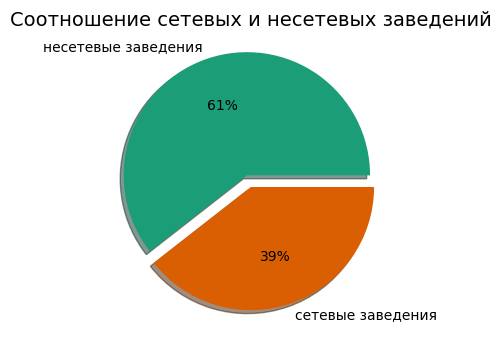

In [51]:
# круговая диаграмма для визуализации соотношения сетевых и несетевых заведений
plt.figure(figsize=(12,4))
labels = ['несетевые заведения', 'сетевые заведения']
colors = sns.color_palette('Dark2')
plt.pie(rest['chain'].value_counts(), labels = labels, colors = colors, autopct='%.0f%%', shadow=True, explode=(0.1, 0))
plt.title('Соотношение сетевых и несетевых заведений', fontsize=14)
plt.show()

**Вывод:** на основании полученных расчётов мы можем утверждать, что несетевых объектов общественного питания почти в полтора  раза больше, чем сетевых.

<a id=3.4></a>
### 3.4. Сетевые объекты общественного питания в разрезе категорий

In [52]:
# расчёт соотношения количестве сетевых и несетевых объектов в разрезе категорий
chain = rest.groupby('category').agg({'name':'count', 'chain':'sum'}).reset_index().sort_values(by='name', ascending=False)
chain['percent'] = chain['chain'] / chain['name'] * 100
chain.sort_values(by='percent', ascending=False)

,category,name,chain,percent
1,булочная,256,165,64.45
5,пиццерия,633,342,54.03
4,кофейня,1413,738,52.23
2,быстрое питание,602,242,40.20
6,ресторан,2042,743,36.39
3,кафе,2378,812,34.15
7,столовая,315,94,29.84
0,"бар,паб",765,179,23.40


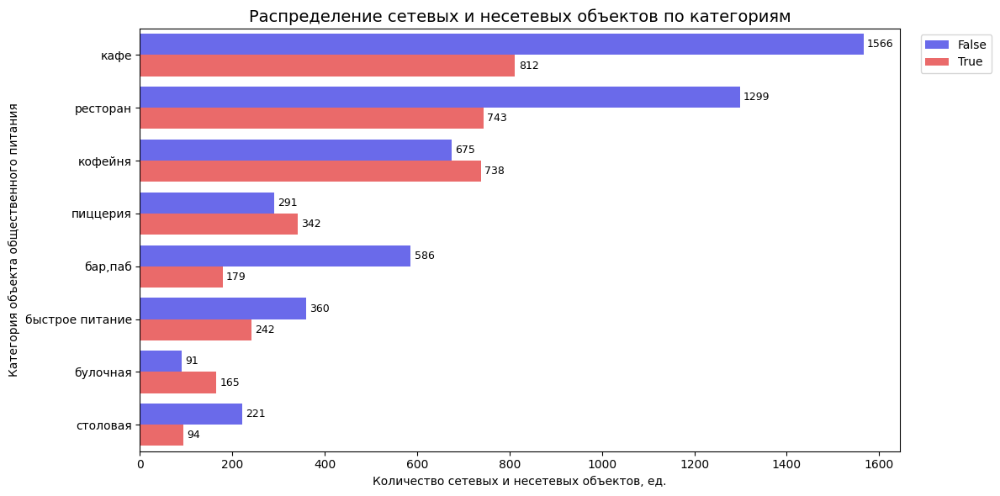

In [53]:
# создадим столбчатую диаграмму распределения типов объектов общественного питания по количеству сетевых и несетевых объектов
plt.figure(figsize=(12,6))
ax = sns.countplot(data=rest, y='category', hue='chain', palette='seismic')

# подписи данных
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=9)

# оформление вывода
plt.title('Распределение сетевых и несетевых объектов по категориям', fontsize=14)
plt.ylabel('Категория объекта общественного питания')
plt.xlabel('Количество сетевых и несетевых объектов, ед.')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Вывод:** чаще всего сетевую модель реализуют булочные, таких брендов почти 65%. По своей численности им почти не уступают сетевые пиццерии и кофейни, в обоих категориях таких брендов более 52%. Остальные категории в части сетевого формата существования не превышают порога 50%, при этом меньше всего в сетевой форме существует баров и пабов - только 23.4% из общей массы объектов общественного питания.

<a id=3.5></a>
### 3.5. Популярные сети общественного питания в Москве (топ-15)

In [54]:
# группируем сетевые заведения по наименованию
chain_top_15 = rest.query('chain == True').groupby('name').agg({'address':'count'}).\
sort_values(by='address', ascending=False).head(15)

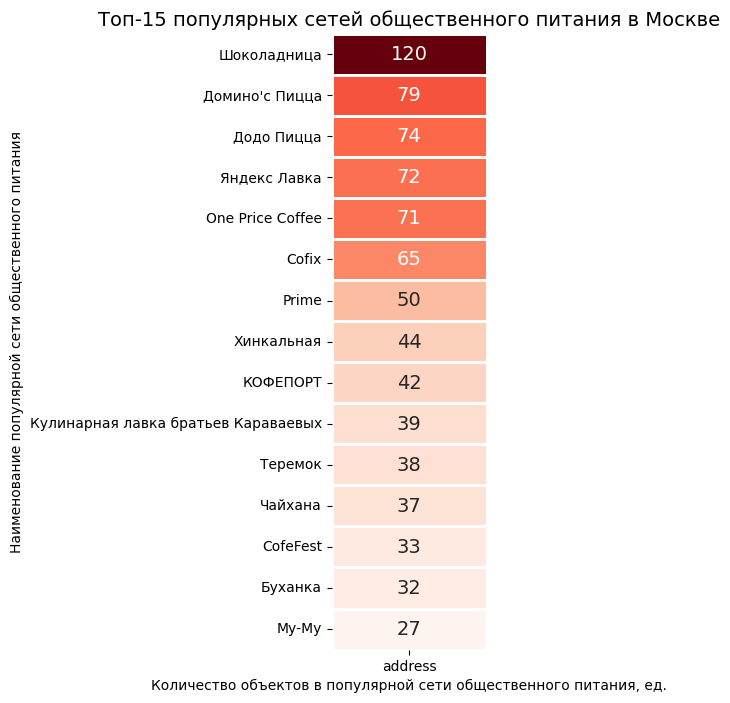

In [55]:
# визуализация топ-15 популярных сетей общепита в Москве
plt.figure(figsize=(2,8))
sns.heatmap(chain_top_15, annot=True, linewidths=1, cbar=False, cmap='Reds', fmt='.0f', annot_kws={'size':14})
plt.title('Топ-15 популярных сетей общественного питания в Москве', size=14)
plt.ylabel('Наименование популярной сети общественного питания')
plt.xlabel('Количество объектов в популярной сети общественного питания, ед.')
plt.show()

Из представленных на визуализации сетевых заведений, на территории пребывания автора исследования осуществляют свою деятельность `Шоколадница`, `Домино'с Пицца`, `Додо Пицца`, `Cofix` и `Чайхана`. Из указанных сетей питания знакомы все. На первый взгляд, главный признак, который объединяет все вышеперечисленные сети питания - их **распространённость и многочисленность.** Рассмотрим основные потребительские параметры и на основании полученных результатов попробуем составить "социальный портрет" фаворита пользователей. 

In [56]:
# исследуем полученный срез по 15 топовым сетям объектов общественного питания на предмет общих характерных признаков
# создаём список наименований топ-15 сетевых заведений
chain_top_15_index = chain_top_15.index.tolist()

In [57]:
# фильтруем датафрейм по списку этих наименований
chain_top_15_full = rest.loc[rest['name'].isin(chain_top_15_index), \
['name', 'category', 'district', 'hours', 'rating', 'price', 'avg_bill', 'seats', 'day', 'time', 'is_24/7']]

In [58]:
# топ-15 популярных сетевых заведений по режиму, круглосуточный график
chain_top_15_full['is_24/7'].value_counts().to_frame().head(10)

,count
is_24/7,
False,781
True,42


In [59]:
# топ-15 популярных сетевых заведений по категориям, всего
chain_top_15_full['hours'].value_counts().head(10)

hours
ежедневно, 10:00–22:00      100
ежедневно, 08:00–23:00       56
ежедневно, 07:00–00:00       46
ежедневно, круглосуточно     42
ежедневно, 10:00–23:00       39
ежедневно, 08:00–22:00       34
пн-пт 08:00–19:00            32
пн-пт 08:00–18:30            28
ежедневно, 09:00–23:00       28
ежедневно, 09:00–22:00       25
Name: count, dtype: int64

In [60]:
# топ-15 популярных сетевых заведений по режиму, дни работы
chain_top_15_full['day'].value_counts().to_frame().head(10)

,count
day,
ежедневно,518
пн-пт 08:00–19:00,32
пн-пт 08:00–18:30,28
"пн-пт 08:00–22:00; сб,вс 09:00–22:00",15
"пн-пт 07:00–22:00; сб,вс 08:00–22:00",13
"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00",10
"пн-пт 07:00–22:00; сб,вс 08:00–21:00",8
пн-пт 07:00–20:00,7
"пн-пт 09:00–22:00; сб,вс 10:00–22:00",7


In [61]:
# топ-15 популярных сетевых заведений по режиму, часы работы
chain_top_15_full['time'].value_counts().to_frame().head(10)

,count
time,
10:00–22:00,100
08:00–23:00,56
07:00–00:00,46
круглосуточно,42
10:00–23:00,39
08:00–22:00,34
09:00–23:00,28
09:00–22:00,25
07:00–22:00,20


In [62]:
# топ-15 популярных сетевых заведений по количеству посадочных мест
chain_top_15_full['seats'].value_counts().to_frame().head(10)

,count
seats,
40.00,23
100.00,22
60.00,21
20.00,16
45.00,15
70.00,15
200.00,14
150.00,14
80.00,13


In [63]:
# топ-15 популярных сетевых заведений по ценовым категориям, всего
chain_top_15_full['price'].value_counts().to_frame()

,count
price,
средние,212
низкие,23
выше среднего,6
высокие,2


In [64]:
# топ-15 популярных сетевых заведений по ценовым категориям
chain_top_15_full['avg_bill'].value_counts().to_frame().head(10)

,count
avg_bill,
Цена чашки капучино:239–274 ₽,43
Цена чашки капучино:90–100 ₽,31
Цена чашки капучино:от 60 ₽,30
Средний счёт:от 500 ₽,26
Средний счёт:300 ₽,12
Средний счёт:300–500 ₽,11
Средний счёт:450 ₽,11
Средний счёт:400 ₽,8
Средний счёт:400–600 ₽,6


In [65]:
# топ-15 популярных сетевых заведений по рейтингу
chain_top_15_full['rating'].value_counts().to_frame()

,count
rating,
4.20,210
4.30,178
4.10,154
4.40,70
4.00,68
3.90,29
4.50,22
3.80,15
3.70,10


In [66]:
# топ-15 популярных сетевых заведений в разрезе категорий
chain_top_15_full.groupby('name')['category'].value_counts().to_frame()

count
name                                category              
CofeFest                            кофейня             32
                                    кафе                 1
Cofix                               кофейня             65
One Price Coffee                    кофейня             71
Prime                               ресторан            49
                                    кафе                 1
Буханка                             булочная            25
                                    кофейня              6
                                    кафе                 1
Додо Пицца                          пиццерия            74
Домино'с Пицца                      пиццерия            79
КОФЕПОРТ                            кофейня             42
Кулинарная лавка братьев Караваевых кафе                39
Му-Му                               кафе                12
                                    ресторан             8
                                    быстрое питание      2
                                    кофейня              2
                                    бар,паб              1
                                    пиццерия             1
                                    столовая             1
Теремок                             ресторан            36
                                    быстрое питание      2
Хинкальная                          кафе                19
                                    ресторан            15
                                    быстрое питание      6
                                    бар,паб              3
                                    столовая             1
Чайхана                             кафе                26
                                    ресторан             9
                                    быстрое питание      2
Шоколадница                         кофейня            119
                                    кафе                 1
Яндекс Лавка                        ресторан            72

In [67]:
# топ-15 популярных сетевых заведений по категориям, всего
chain_top_15_full['category'].value_counts().to_frame()

,count
category,
кофейня,337
ресторан,189
пиццерия,154
кафе,100
булочная,25
быстрое питание,12
"бар,паб",4
столовая,2


In [68]:
# общее количество заведений по административным округам
cat_distr = chain_top_15_full.groupby('district').agg({'category':'count'}).\
sort_values(by='category', ascending=False).reset_index()
cat_distr['percent'] = cat_distr['category'] / sum(cat_distr['category']) * 100
cat_distr

,district,category,percent
0,Центральный административный округ,215,26.12
1,Южный административный округ,89,10.81
2,Западный административный округ,89,10.81
3,Северный административный округ,88,10.69
4,Северо-Восточный административный округ,86,10.45
5,Восточный административный округ,82,9.96
6,Юго-Западный административный округ,71,8.63
7,Юго-Восточный административный округ,56,6.80
8,Северо-Западный административный округ,47,5.71


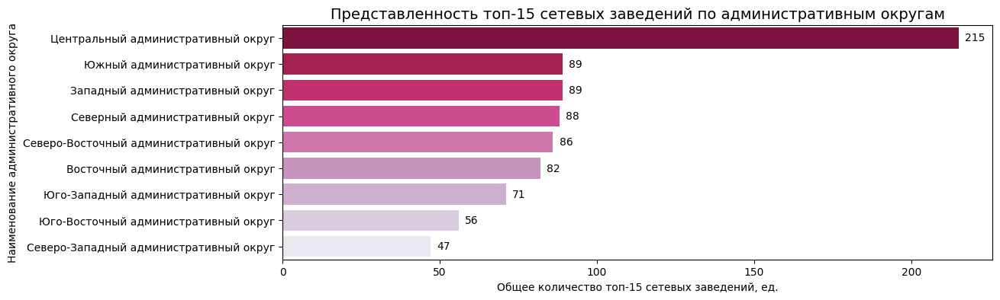

In [69]:
# создадим столбчатую диаграмму распределения суммарного количества объектов общественного питания по округам
plt.figure(figsize=(12,4))
ax = sns.barplot(data=cat_distr, x='category', y='district', palette='PuRd_r')

# подписи рядом со столбцами
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 2, p.get_y() + p.get_height() / 2, 
            f'{width:.0f}', ha='left', va='center', fontsize=10, color='black')
    
plt.title('Представленность топ-15 сетевых заведений по административным округам', fontsize=14)
plt.ylabel('Наименование административного округа')
plt.xlabel('Общее количество топ-15 сетевых заведений, ед.')
plt.show()


 Количество заведений по административным округам в разрезе категорий 



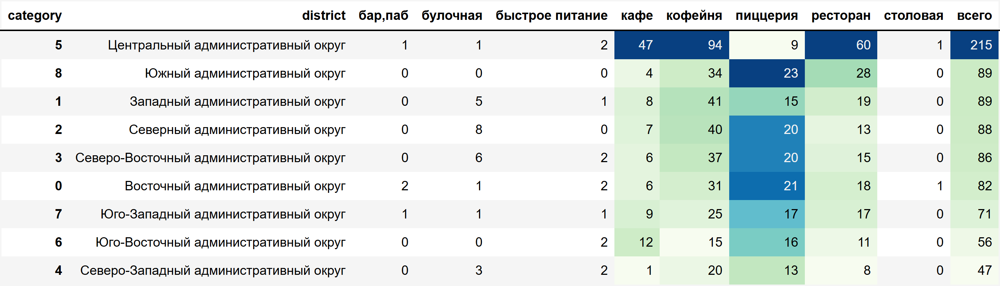

In [70]:
# общее количество заведений по административным округам в разрезе категорий
pivot_styled = (chain_top_15_full.pivot_table(index='district', columns='category', \
                 values='name', aggfunc='count', margins=True, \
                 margins_name='всего').fillna(0)
    .astype(int).reset_index().sort_values(by='всего', ascending=False).iloc[1:])

# градиентная заливка для ключевых значений
styled_table = pivot_styled.style.background_gradient(
    subset=['кофейня', 'ресторан', 'пиццерия', 'кафе', 'всего'], cmap='GnBu')

# убираем ограничения для рендера таблицы
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Количество заведений по административным округам в разрезе категорий \n')

# оформление в виде изображения
dfi.export(styled_table, 'districts_categories_heatmap.png', table_conversion='chrome', max_rows=len(pivot_styled), fontsize=9, dpi=400)

# вывод стилизованной таблицы
display(Image(filename='districts_categories_heatmap.png', width=900))

**Вывод:** мы получили не только топ-15 популярных сетей общественного питания в Москве, но и на основании дополнительных расчётов и пользовательских характеристик объектов, составили портрет идеального соотношения цены и качества заведения.

Относительно графика работы объекта: заведение открыто ежедневно в период с 10:00–22:00 (100 объектов) или 08:00–23:00 (56 объектов). Для посетителей оборудовано 80 мест. Ценовой сегмент заведения: средний. Средний счёт от 300 до 500 рублей, цена чашки капучино может варьироваться от 60 до 100 рублей, а может быть в районе 250 рублей в случае, если это профильный объект питания (кафе, кофейня). Рейтинг у такого объекта зачастую находится в диапазоне от 4.1 до 4.3 включительно. Абсолютное большинство таких народных любимцев – это кофейня, расположенная в Центральном административном округе. 

Если полученные описательные характеристики перенести на почву реальности, то абсолютным и по праву заслуженным признанием покупателей пользуется бренд `Шоколадница`. Некоторую конкуренцию ему могут составить кофейни сети `One Price Coffee` и `Cofix`.

<a id=3.6></a>
### 3.6. Объекты общественного питания по административным районам

In [71]:
# перечень наименований административных районов Москвы
rest['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [72]:
# общее количество заведений по административным округам
cat_tot = rest.groupby('district').agg({'category':'count'}).sort_values(by='category', ascending=False).reset_index()
cat_tot['percent'] = cat_tot['category'] / sum(cat_tot['category']) * 100
cat_tot

,district,category,percent
0,Центральный административный округ,2242,26.68
1,Северный административный округ,899,10.70
2,Южный административный округ,891,10.60
3,Северо-Восточный административный округ,891,10.60
4,Западный административный округ,851,10.13
5,Восточный административный округ,798,9.50
6,Юго-Восточный административный округ,714,8.50
7,Юго-Западный административный округ,709,8.44
8,Северо-Западный административный округ,409,4.87


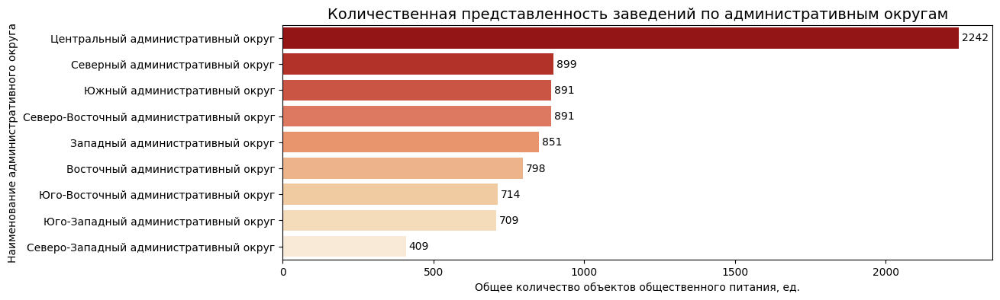

In [73]:
# создадим столбчатую диаграмму распределения суммарного количества объектов общественного питания по округам
plt.figure(figsize=(12,4))
ax = sns.barplot(data=cat_tot, x='category', y='district', alpha=1, palette='OrRd_r')

# подписи рядом со столбцами
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 10, p.get_y() + p.get_height() / 2, 
            f'{width:.0f}', ha='left', va='center', fontsize=10, color='black')
    
plt.title('Количественная представленность заведений по административным округам', fontsize=14)
plt.ylabel('Наименование административного округа')
plt.xlabel('Общее количество объектов общественного питания, ед.')
plt.show()

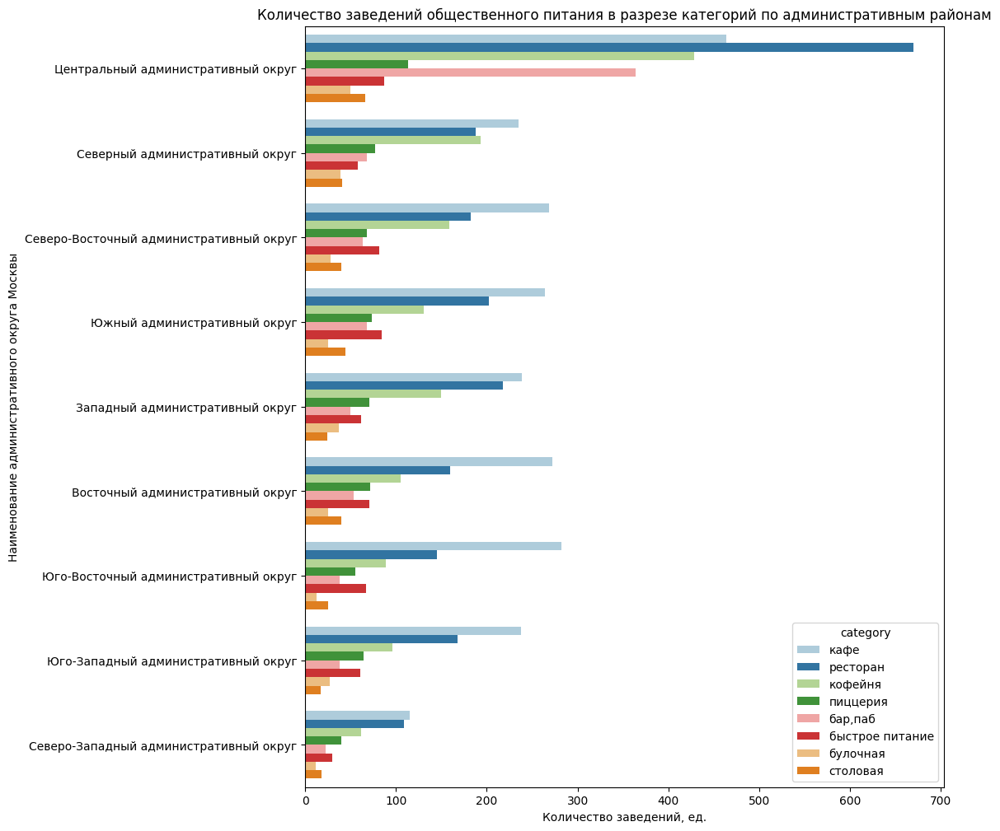

In [74]:
# задаём порядок отображения топ-15 улиц на графике
order_index = rest.pivot_table(index='district', columns='category', values='name', aggfunc='count', margins=True, \
                             margins_name='всего').sort_values(by='всего', ascending=False)[1:].index

# визуализация общего количества заведений по административным районам
plt.figure(figsize=(10,12))
sns.countplot(data=rest, y='district', hue='category', palette='Paired', order=order_index)
plt.xlabel('Количество заведений, ед.')
plt.ylabel('Наименование административного округа Москвы')
plt.title('Количество заведений общественного питания в разрезе категорий по административным районам')
plt.show()


 Количество заведений по административным округам в разрезе категорий 



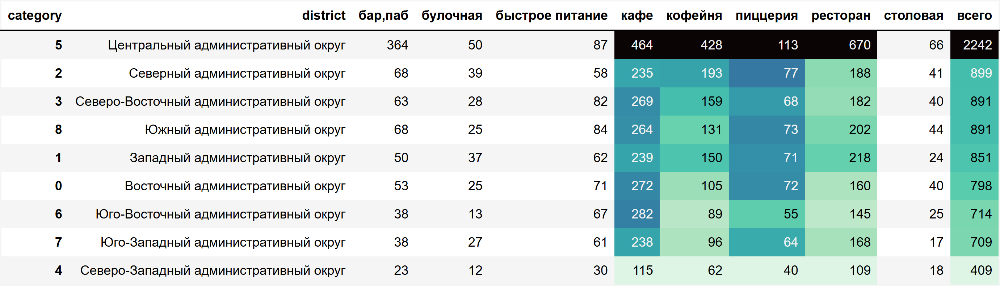

In [75]:
# количество заведений по округам в разрезе категорий
pivot_df = (rest.pivot_table(index='district', columns='category', values='name', aggfunc='count', 
                             margins=True, margins_name='всего').fillna(0).astype(int).reset_index().\
    sort_values(by='всего', ascending=False).iloc[1:])
    
# градиентная заливка для ключевых значений
styled_table = pivot_df.style.background_gradient(subset=['кофейня', 'ресторан', 'пиццерия', 'кафе', 'всего'], cmap='mako_r')

# убираем возможные ограничения высоты таблицы в рендерере
styled_table = styled_table.set_table_styles([
    {'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Количество заведений по административным округам в разрезе категорий \n')

# оформление в виде изображения
dfi.export(styled_table, 
           'districts_categories_heatmap.png',
           table_conversion='chrome', # рендеринг через Chromium для точной передачи стилей
           max_rows=len(pivot_df),    # гарантируем отображение всех строк
           fontsize=9,                # читаемый размер шрифта
           dpi=400)                   # высокое разрешение

display(Image(filename='districts_categories_heatmap.png', width=900))

**Выводы:** частная картина распределения заведений общественного питания в разрезе топ-15 самых популярных сетей и в общем по всем формам (и сетевым, и несетевым) подтверждает доминирование Центрального административного округа над остальными округами Москвы. На долю Центрального округа приходится порядка 27% общего количества заведений Москвы, второе место по численности на уровне 10% занимают ряд округов, а именно Северный, Северо-Восточный, Западный, Южный. Их догоняют Восточный, Юго-Восточный, Юго-Западный административные округа, количество заведений на этих территориях не превышает 8% - 9% от общего количества заведений Москвы. Особняком держится Северо-Западный административный округ с большим количеством промзон действующих и заброшенных: суммарное количество объектов общественного питания на этой территории составляет всего 409 объектов, что составляет порядка 5% от общей численности объектов питания Москвы в целом.

<a id=3.7></a>
### 3.7. Распределение средних рейтингов по категориям заведений

In [76]:
# создаем сводную таблицу средних рейтингов по категориям
cat_rating = pd.pivot_table(rest, values='rating', index='category', aggfunc='mean').sort_values(by='rating', ascending=False)

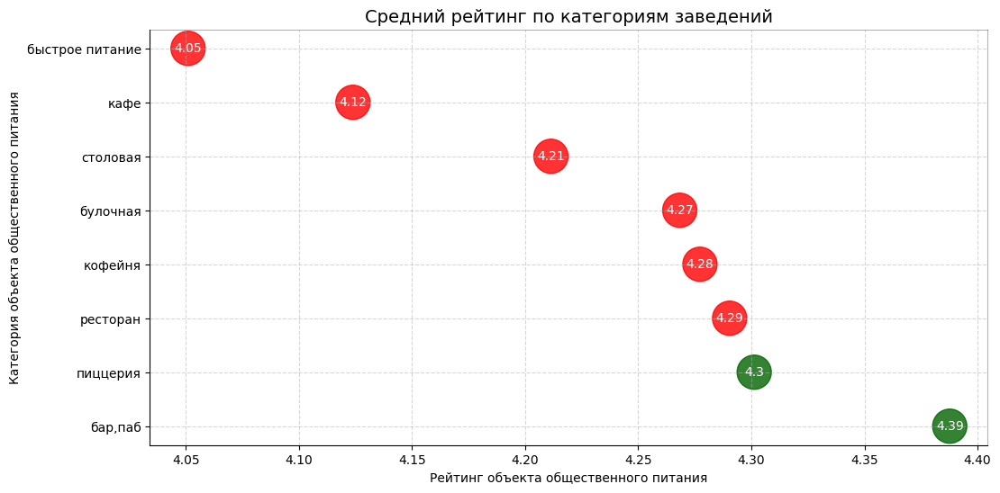

In [77]:
# визуализация распределения средних рейтингов по категориям заведений
plt.figure(figsize=(12,6), dpi= 100)

cat_rating['colors'] = ['red' if x <= 4.30 else 'darkgreen' for x in cat_rating['rating']]
plt.scatter(cat_rating['rating'], cat_rating.index, s=750, alpha=0.8, color=cat_rating['colors'])

for x, y, tex in zip(cat_rating['rating'], cat_rating.index, cat_rating['rating']):
    t = plt.text(x, y, round(tex, 2), horizontalalignment='center', 
                 verticalalignment='center', fontdict={'color':'white'})

# светлые границы у точек на графике
plt.gca().spines['top'].set_alpha(0.3)
plt.gca().spines['bottom'].set_alpha(1)
plt.gca().spines['right'].set_alpha(0.3)
plt.gca().spines['left'].set_alpha(1)

plt.yticks(cat_rating.index)
plt.title('Средний рейтинг по категориям заведений', fontsize=14)
plt.xlabel('Рейтинг объекта общественного питания')
plt.ylabel('Категория объекта общественного питания')
plt.grid(linestyle='--', alpha=0.5)
plt.show()

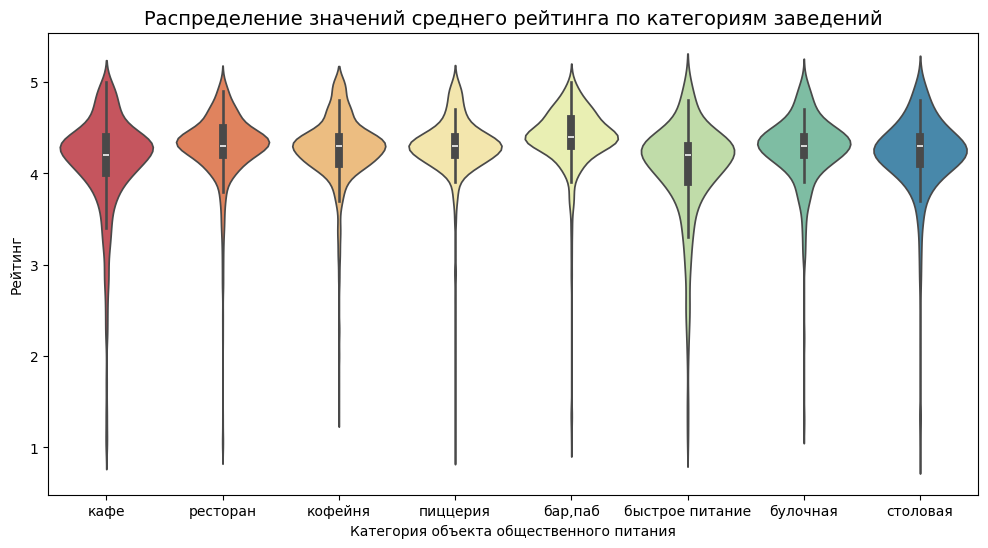

In [78]:
# визуализация распределения средних рейтингов по категориям заведений
plt.figure(figsize=(12, 6))
plt.title('Распределение значений среднего рейтинга по категориям заведений', fontsize=14)
sns.violinplot(x= rest['category'], y=rest['rating'], palette='Spectral');
plt.ylabel('Рейтинг')
plt.xlabel('Категория объекта общественного питания')
plt.show()

**Вывод:** на основании полученных средних значений рейтинга каждого типа объекта общественного питания мы наблюдаем очень плавный рост значений в пределах 0.4. В этом случае мы не можем говорить о наличии критической разницы между рейтингами разных категорий объектов общепита, но эта, казалось бы маленькая деталь хорошо дополняет тезис о соотношении рейтинга заведения и количества проведённого в нём времени посетителем.

<a id=3.8></a>
### 3.8. Средний рейтинг объектов общественного питания в разрезе административных районов Москвы

In [79]:
# расчёт среднего рейтинга по административным округам
rating_df = rest.groupby('district', as_index=False)['rating'].agg('mean')
rating_df.sort_values(by='rating', ascending=False)

,district,rating
5,Центральный административный округ,4.38
2,Северный административный округ,4.24
4,Северо-Западный административный округ,4.21
8,Южный административный округ,4.19
1,Западный административный округ,4.18
0,Восточный административный округ,4.17
7,Юго-Западный административный округ,4.17
3,Северо-Восточный административный округ,4.15
6,Юго-Восточный административный округ,4.10


In [80]:
# загружаем JSON-файл с границами округов Москвы
state_geo = 'https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson'
# moscow_lat - широта центра Москвы, moscow_lng - долгота центра Москвы
moscow_lat, moscow_lng = 55.751244, 37.618423

# создаём карту Москвы
m = Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
Choropleth(
    geo_data=state_geo,
    data=rating_df,
    columns=['district', 'rating'],
    key_on='feature.name',
    fill_color='Reds',
    fill_opacity=0.7,
    legend_name='Медианный рейтинг заведений по районам').add_to(m)

# выводим фотоновую картограмму
m

**Вывод:** полученные нами расчёты складываются во вполне осмысленную и характерную картину. Центральный административный округ в силу своего динамичного развития предоставляет сервис общественного питания на высоком и выше среднего уровне, поэтому средний рейинг находится на отметке 4.38. Северный и Северо-Западный административные округа немногим уступают, однако и там достаточно высокий средний рейтинг заведений: пользовательская оценка находится в диапазоне от 4.21 до 4.24. Хуже всего дела обстоят в Юго-Восточномадминистративном округе: лесопарковая зона, горно-обогатительный комбинат, агрохимстанции и трасса М-5 едва ли могут конкурировать с деловым и культурным центром столицы. Средний рейтинг заведений здесь едва-едва переваливает за отметку 4.1.

<a id=3.9></a>
### 3.9. Обобщённая карта-схема объектов общественного питания Москвы

In [81]:
# заново создаём карту Москвы
moscow = Map(location=[moscow_lat, moscow_lng], zoom_start=15)

def create_marker(row):
    Marker([row['lat'], row['lng']],
        popup=f"{row['name']} {row['rating']}").add_to(moscow)

# создаём пустой кластер, добавляем его на карту
marker_cluster = MarkerCluster().add_to(moscow)

# пишем функцию, которая принимает строку датафрейма,
# создаёт маркер в текущей точке и добавляет его в кластер marker_cluster
def create_clusters(row):
    Marker(
        [row['lat'], row['lng']],
        popup=f"{row['name']} {row['rating']}",).add_to(marker_cluster)

# применяем функцию create_clusters() к каждой строке датафрейма
rest.apply(create_clusters, axis=1)

# выводим карту
moscow

<a id=3.10></a>
### 3.10. Популярные улицы по количеству объектов общественного питания (топ-15)

In [82]:
# формируем список топ-15 улиц Москвы по количеству заведений
street_top_15 = rest.groupby('street').agg({'name': 'count'}).sort_values(by='name', ascending=False).head(15)
street_top_15['percent'] = street_top_15['name'] / sum(street_top_15['name']) * 100
street_top_15

,name,percent
street,,
проспект Мира,184,14.84
Профсоюзная улица,122,9.84
проспект Вернадского,108,8.71
Ленинский проспект,107,8.63
Ленинградский проспект,95,7.66
Дмитровское шоссе,88,7.10
Каширское шоссе,77,6.21
Варшавское шоссе,76,6.13
Ленинградское шоссе,70,5.65


In [83]:
# из полученного топ-15 улиц по количеству объектов создаём список для дальнейшей фильтрации общего массива данных
street_top_15_index = street_top_15.index.tolist()

# фильтруем датафрейм по списку улиц из топ-15
street_top_15_full = rest.loc[rest['street'].isin(street_top_15_index)]


 Количество заведений по топ-15 улицам в разрезе категорий 



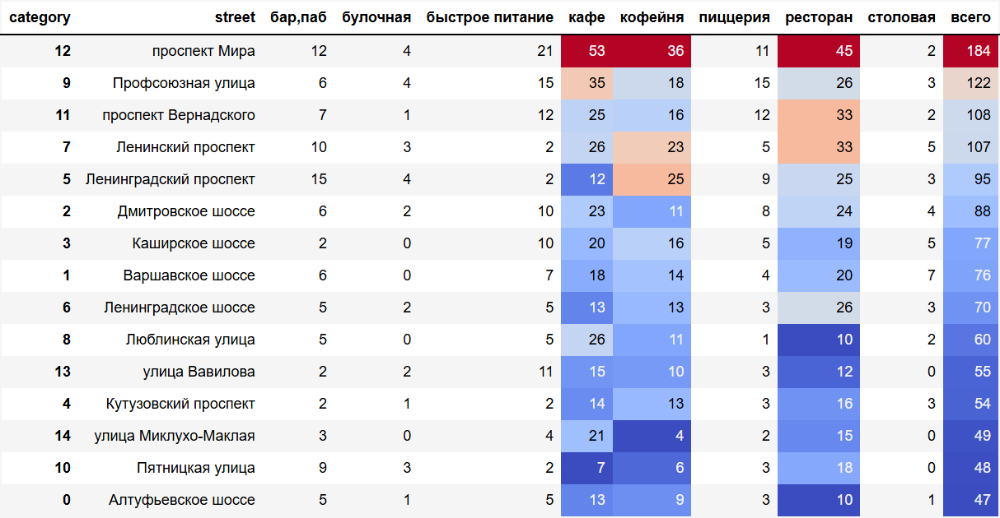

In [84]:
# количество заведений по топ-15 улиц в разрезе категорий
pivot_df = (street_top_15_full.pivot_table(index='street', columns='category', values='name', aggfunc='count', 
                                           margins=True, margins_name='всего').fillna(0).astype(int).reset_index().\
    sort_values(by='всего', ascending=False).iloc[1:])
    
# градиентная заливка для ключевых значений
styled_table = pivot_df.style.background_gradient(subset=['кофейня', 'ресторан', 'кафе', 'всего'], cmap='coolwarm')

# убираем возможные ограничения высоты таблицы в рендерере
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Количество заведений по топ-15 улицам в разрезе категорий \n')

# оформление в виде изображения
dfi.export(styled_table, 'streets_categories_heatmap.png', table_conversion='chrome', max_rows=len(pivot_df), fontsize=9, dpi=200)

display(Image(filename='streets_categories_heatmap.png', width=900))

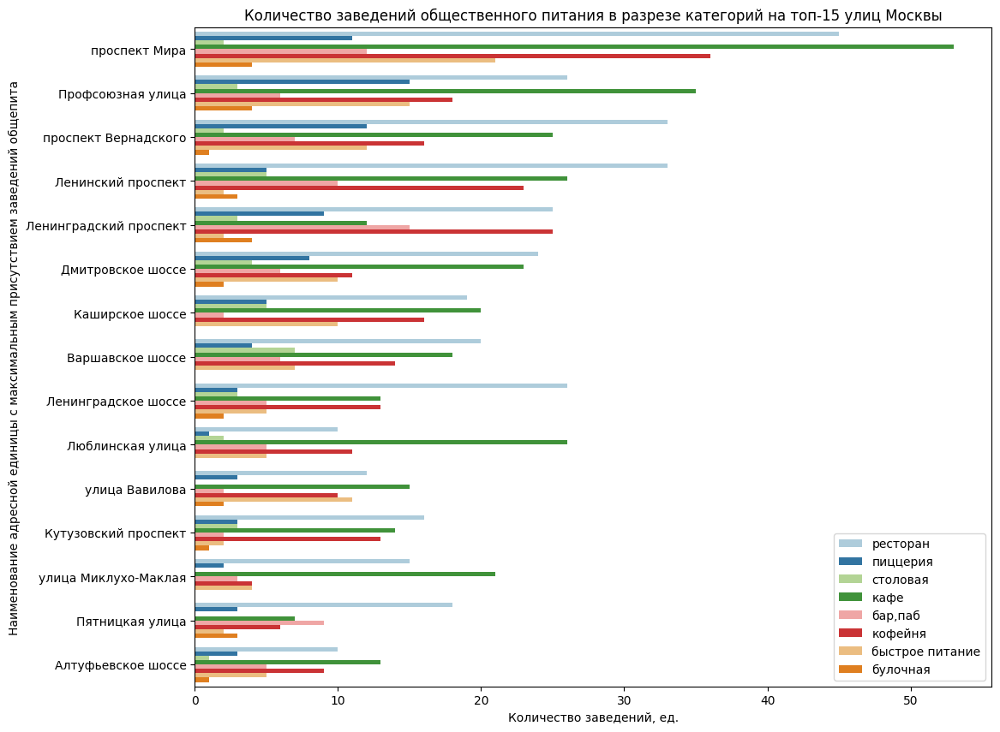

In [85]:
# задаём порядок отображения топ-15 улиц на графике
order_index = street_top_15_full.pivot_table(index='street', columns='category', values='name', aggfunc='count', margins=True, \
                             margins_name='всего').sort_values(by='всего', ascending=False)[1:].index

# визуализация представленности заведений по категориям на топ-15 улицах Москвы
plt.figure(figsize=(12,10))
sns.countplot(data=street_top_15_full, y='street', hue='category', palette='Paired', order=order_index)
plt.legend(loc='lower right')
plt.xlabel('Количество заведений, ед.')
plt.ylabel('Наименование адресной единицы с максимальным присутствием заведений общепита')
plt.title('Количество заведений общественного питания в разрезе категорий на топ-15 улиц Москвы')
plt.show()

**Вывод:** проспект Мира является доминантой по количеству объектов питания, здесь сосредоточено почти 15% всех заведений топ-15, а это порядка 190 торговых точек. Незначительную конкуренцию ему может составить Профсоюзная улица, на которой расположились 122 объекта, или порядка 10% всех заведений из списка топ-15 улиц. Третье место по популярности делят между собой проспект Вернадского и Ленинский проспект. На долю каждого из них приходится более 8% всех объектов общественного питания топа. Перечисленные улицы - лишь 4 позиции из 15, обозначенных в условиях данной исследовательской задачи. Исходя из полученных результатов в асболютных и относительных показателях. Количественные показатели свидетельствуют о незначительной целесообразности выделения топ-15 улиц с большим количеством объектов общественного питания. Гораздо более выразительные и характерные результаты могут быть получены в аналогичном разрезе формата топ-10.

На перечисленных выше улицах из топ-15 мы видим спектр заведений, характерный для рекреационных зон городского пространства. Из категорий общепита превалируют кафе, рестораны, кофейни. На десяток меньше - пиццерий и баров. Объекты быстрого питания, булочные, столовые мало распространены и плохо вписываются в культурный код этих пространств. 

<a id=3.11></a>
### 3.11. Одна улица - один объект общественного питания

Для того, чтобы составить своего рода социальный портрет заведений, в единственном числе присутствующих на той или иной улицы Москвы, мы предварительно отфильтруем общий массив данных, и затем последовательно изучим основные характерные потребительские черты объектов.

In [86]:
# отфильтруем из общего массива данных улицы только с одним заведением
one_obj_street = rest.groupby('street').agg({'name':'count'}).sort_values(by='name').reset_index()
one_obj_street = one_obj_street.loc[one_obj_street['name'] == 1].drop_duplicates(subset=['street'])
one_obj_street

,street,name
0,1-й Земельный переулок,1
1,1-й Капотнинский проезд,1
2,1-й Кирпичный переулок,1
3,1-я Парковая улица,1
4,1-я Стекольная улица,1
...,...,...
485,улица Шухова,1
486,улица Юннатов,1
487,1-й Автозаводский проезд,1
488,улица Усиевича,1


In [87]:
# из полученного списка улиц с одним объектом общепита создаём список для дальнейшей фильтрации общего массива данных
one_obj_street_index = one_obj_street['street'].tolist()

# фильтруем датафрейм по списку улиц с одним объектом общепита
one_obj_street_full = rest.loc[rest['street'].isin(one_obj_street_index)]

In [88]:
# улицы с 1 объектом: проверка на представленные категории заведений
one_obj_street_full.category.value_counts().to_frame()

,count
category,
кафе,176
ресторан,94
кофейня,93
"бар,паб",41
столовая,37
быстрое питание,24
пиццерия,15
булочная,10


In [89]:
# улицы с 1 объектом: география 
one_obj_street_full.district.value_counts().to_frame()

,count
district,
Центральный административный округ,147
Восточный административный округ,59
Северо-Восточный административный округ,58
Северный административный округ,57
Южный административный округ,44
Юго-Восточный административный округ,42
Западный административный округ,42
Северо-Западный административный округ,21
Юго-Западный административный округ,20


In [90]:
# улицы с 1 объектом: проверка на круглосуточный режим работы
one_obj_street_full['is_24/7'].value_counts().to_frame()

,count
is_24/7,
False,455
True,35


In [91]:
# улицы с 1 объектом: проверка на график работы
one_obj_street_full.day.value_counts().to_frame().head(10)

,count
day,
ежедневно,273
пн-пт 09:00–18:00,10
пн-пт 09:00–17:00,9
пн-пт 08:00–19:00,8
пн-пт 08:00–18:00,4
"пн-пт 08:00–21:00; сб,вс 09:00–21:00",4
пн-пт 11:00–18:00,3
пн-пт 08:30–17:00,3
"пн-пт 08:00–20:00; сб,вс 09:00–20:00",3


In [92]:
# улицы с 1 объектом: проверка на время работы
one_obj_street_full.time.value_counts().to_frame().head(10)

,count
time,
круглосуточно,35
10:00–22:00,27
11:00–23:00,26
12:00–00:00,20
09:00–22:00,15
10:00–23:00,15
09:00–21:00,12
08:00–23:00,10
10:00–21:00,9


In [93]:
# топ-15 популярных сетевых заведений в разрезе категорий
one_obj_street_full.seats.value_counts().to_frame().head(10)

,count
seats,
40.00,18
30.00,13
48.00,9
45.00,6
0.00,6
90.00,5
70.00,5
50.00,5
80.00,5


In [94]:
# улицы с 1 объектом: диапазон цен
one_obj_street_full.price.value_counts().to_frame()

,count
price,
средние,123
выше среднего,29
высокие,22
низкие,10


In [95]:
# улицы с 1 объектом: средний счёт
one_obj_street_full.avg_bill.value_counts().to_frame().head(10)

,count
avg_bill,
Средний счёт:1000–1500 ₽,10
Средний счёт:1500–2000 ₽,8
Средний счёт:200–300 ₽,8
Средний счёт:1500 ₽,6
Средний счёт:500–700 ₽,4
Средний счёт:1000 ₽,4
Средний счёт:от 1500 ₽,3
Средний счёт:500–800 ₽,3
Средний счёт:500–1000 ₽,3


In [96]:
# улицы с 1 объектом: средний чек
one_obj_street_full.middle_avg_bill.value_counts().to_frame().head(10)

,count
middle_avg_bill,
1500.00,11
250.00,11
1250.00,10
1000.00,9
1750.00,8
600.00,7
500.00,6
400.00,5
300.00,5


In [97]:
# улицы с 1 объектом: средняя стоимость чашки кофе
# в этом признаке частота значений среднего ценника на чашку кофе является непоказательной, сортируем данные по самой средней цене
one_obj_street_full.middle_coffee_cup.value_counts().to_frame().reset_index().sort_values(by='middle_coffee_cup')

,middle_coffee_cup,count
7,95.00,1
18,125.00,1
2,134.00,1
9,135.00,1
16,139.00,1
0,140.00,2
12,150.00,1
19,155.00,1
5,165.00,1
21,170.00,1


In [98]:
# проверка сетевого признака
one_obj_street_full['chain'].value_counts().to_frame()

,count
chain,
False,345
True,145


In [99]:
# улицы с 1 объектом: проверка на уникальные имена
one_obj_street_full.name.value_counts().head(10)

name
Кафе                    23
CofeFest                 6
Яндекс Лавка             6
Drive Café               5
Домино'с Пицца           3
Лаки Сувлаки             3
Кафе-столовая            3
Монастырская трапеза     3
Шаурма                   3
Вкус Востока             2
Name: count, dtype: int64

In [100]:
# улицы с 1 объектом: проверка на рейтинг
one_obj_street_full.rating.value_counts().to_frame().head(10)

,count
rating,
4.30,89
4.40,59
4.20,57
4.10,55
4.50,29
4.70,29
4.00,27
4.60,22
4.90,22


**Вывод:** в результате исследования нами было установлено наличие 490 улиц в Москве, на которых расположен единственный объект общественного питания. Такое положение дел является характерным для 5.8% всех объектов. Полагаем возможным выдвинуть предположение, что в числе таких объектов находятся "отстающие" и "опережающие", настолько сильно территориально удалённые и расположенные на краю мира (например, `Иду лесом` И `В парке вкуснее`) объекты общепита, у которых в виду этого нет конкурентов, а также уникальные объекты, владельцы которых обладают исключительными правами на строительство в данном конкретном месте (`Буфет Ботанического сада`, к примеру). Эта изолированность от конкуренции других объектов общественного питания не толькой той же категории, что и сам объект, но и в целом, создаёт выгодные условия для владельцев данного бизнеса.

На выявленных 490 улицах с 1 объектом общепита в большинстве расположены кафе (176 объектов), рестораны и кофейни. Таких объектов насчитывается порядка 90 в каждой категории. Бары и столовые представлены почти в 2 раза реже: их численность находится на отметке 40 объектов также в каждой указанной категории. Редко встречаются пиццерии и булочные (от 10 до 15 объектов), и этому есть логическое объяснение: будучи монополистом в сфере предоставления услуг по питанию в определённом районе города, объект будет скорее всего ориентирован на широкий ассортимент блюд и длительное время пребывания посетителя. Поэтому, кафе, ресторанов и кофеен на таких улицах ощутимо больше, чем булочных, пиццерий и даже объектов быстрого питания.

Относительно локализации таких улиц: общее правило доминанты Центрального административного округа подтверждается и на этом срезе данных. В ЦАО насчитывается 147 улиц с 1 объектом общепита. В полтора раза меньше таких улиц было выявлено в Восточном, Северо-Восточном и Северном административном округах (порядка 60 улиц в каждом). Меньше всего таких «единичных» объектов в Северо-Западном административном округе (21 улица) и Юго-Западном административном округе (20 улиц). Сказывается специфика градостроительной деятельности: промышленная зона и спальные районы едва ли располагают к активному отдыху, включающему посещение кафе или ресторана.

Относительно формата организации деятельности условно типового единственного заведения общепита на отдельно взятой улице. Чаще всего, это некруглосуточный (455 штук против 35 штук) и несетевой объект торговли (345 против 145 штук). Из сетевых чаще всего встречаются объекты бренда `Кафе`, дарксторы `Яндекс Лавки` с доставкой готовых ресторанных блюд, кофейни `CofeFest` и `Drive Café`.

Абсолютная доминанта: ежедневный график работы с круглосуточным или удлинённым режимом: с 10.00 до 22.00 (±2 часа, вплоть до полуночи). Такой объект чаще всего обладает залом на 80 или 60 человек. В заведении – средний ценовой порог. Средний счёт составляет от 1000 до 2000 рублей, а средний чек – от 1250 рублей до 1500 рублей, чашка кофе может обойтись посетителю в 150 рублей – 200 рублей.

Стоит отметить, что монополия на услуги питания влечёт за собой обязательство держать высокий уровень сервиса во избежание статуса «одноразового» заведения. Рейтинги большинства таких объектов-«одиночек» находится в диапазон 4.2 - 4.4, и очень редко опускается до 3.9.

<a id=3.12></a>
### 3.12. Средний чек объекта общественного питания в разрезе административного района

Значения средних чеков заведений хранятся в столбце `middle_avg_bill`. Эти числа показывают примерную стоимость заказа в рублях, которая чаще всего выражена диапазоном. Посчитаем медиану этого столбца для каждого района и используем это значение в качестве ценового индикатора района. Создадим фоновую картограмму (хороплет) с полученными значениями для каждого района и на основе этих данных проанализируем цены в Центральном административном округе и других, чтобы выяснить как удалённость от центра влияет на цены в заведениях.

In [101]:
# расчёт медианы среднего счёта в качестве ценового индикатора административного района
# в данных есть выбросы, поэтому для расчётов используем медиану, а не среднее значение
mid_bill = rest.groupby('district', as_index=False).agg({'middle_avg_bill':'median'}).\
sort_values(by='middle_avg_bill', ascending=False)
mid_bill

,district,middle_avg_bill
1,Западный административный округ,1000.00
5,Центральный административный округ,1000.00
4,Северо-Западный административный округ,700.00
2,Северный административный округ,650.00
7,Юго-Западный административный округ,600.00
0,Восточный административный округ,575.00
3,Северо-Восточный административный округ,500.00
8,Южный административный округ,500.00
6,Юго-Восточный административный округ,450.00


In [102]:
# загружаем JSON-файл с границами округов Москвы
state_geo = 'https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson'

# moscow_lat - широта центра Москвы, moscow_lng - долгота центра Москвы
moscow_lat, moscow_lng = 55.751244, 37.618423

# создаём карту Москвы
moscow_bill = Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
Choropleth(geo_data=state_geo, data=mid_bill, columns=['district', 'middle_avg_bill'],
    key_on='feature.name', fill_color='Blues', fill_opacity=0.6,
    legend_name='Средний рейтинг заведений по районам').add_to(moscow_bill)

# выводим фотоновую картограмму
moscow_bill

Выполним статистический анализ цен в разрезе администратвиных районов Москвы.


 Статистический анализ среднего чека по административным округам 



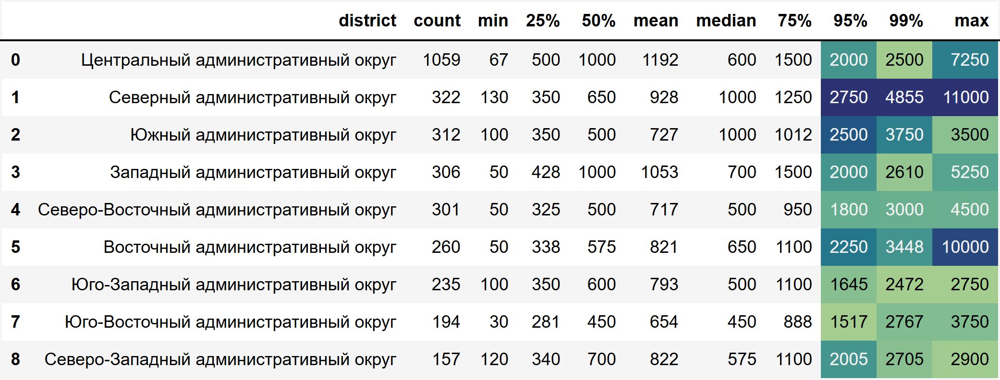

In [103]:
# статистический анализ цен по округам
# создаём копию основного датафрейма
bill_by_distr = rest.copy()

#удаляем пропуски значений средней цены и удаляем строки, где была заполнено нулевая цена
bill_by_distr = bill_by_distr.dropna(subset=['middle_avg_bill']).reset_index(drop=True)
bill_by_distr = bill_by_distr.drop(np.where(bill_by_distr['middle_avg_bill'] == 0)[0])

# удаляем аномальное значение чека в 35000 по Южному административному округу
bill_by_distr = bill_by_distr.drop(index=2767)

# группируем данные по административным округам
bill = bill_by_distr.groupby('district')['middle_avg_bill'].describe().sort_values(by='count', ascending=False).reset_index()

# список с названиями округов
districts = ['Юго-Западный административный округ', 'Центральный административный округ', 'Западный административный округ',
             'Северо-Западный административный округ', 'Северо-Восточный административный округ', 'Северный административный округ',
             'Южный административный округ', 'Юго-Восточный административный округ', 'Восточный административный округ']

# создаём словарь с данными о среднем чеке в каждом округе
data = {}
for district in districts:
    data[district] = bill_by_distr.query(f'district == "{district}"')['middle_avg_bill']

# вычисляем медиану и перцентили для каждого округа
medians = [data[district].median() for district in districts]
percentile_95 = [np.percentile(data[district], 95) for district in districts]
percentile_99 = [np.percentile(data[district], 99) for district in districts]

# добавляем данные о медиане и перцентилях в таблицу `bill`
bill['median'] = medians
bill['95%'] = percentile_95
bill['99%'] = percentile_99

# формируем итоговую таблицу с нужными колонками
result_df = bill[['district', 'count', 'min', '25%', '50%', 'mean', 'median', '75%', '95%', '99%', 'max']]

# градиентная заливка для ключевых значений
styled_table = result_df.style.background_gradient(subset=['95%', '99%', 'max'], cmap='crest').format(precision=0)

# убираем возможные ограничения высоты таблицы в рендерере
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Статистический анализ среднего чека по административным округам \n')

# оформление в виде изображения
dfi.export(styled_table, 'bill_by_district_stats.png', table_conversion='chrome', max_rows=len(result_df), fontsize=9, dpi=400)
display(Image(filename='bill_by_district_stats.png', width=900))

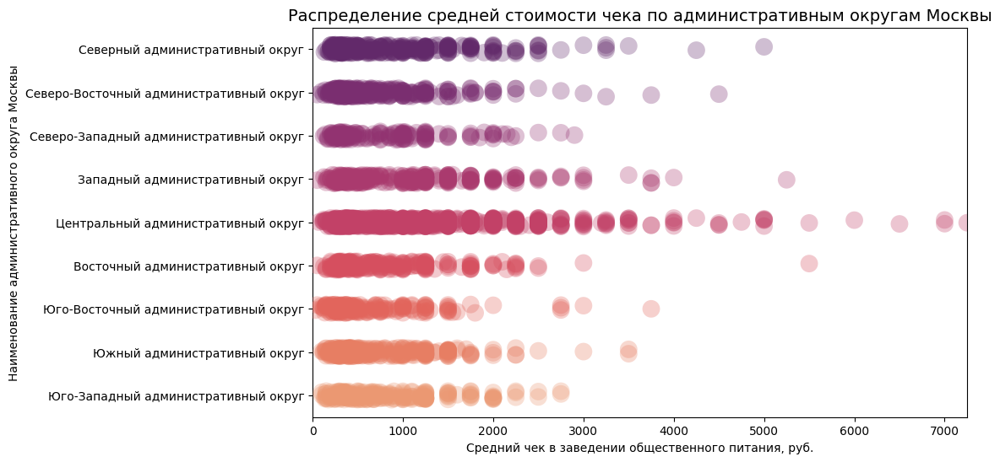

In [104]:
# визуализация распределения средней стоимости заказа по административным округам в Москве
plt.figure(figsize=(10,6))
sns.stripplot(data=bill_by_distr, 
              x='middle_avg_bill', y='district', s=15, alpha=0.3, palette='flare_r')
plt.title('Распределение средней стоимости чека по административным округам Москвы', fontsize=14)
plt.ylabel('Наименование административного округа Москвы')
plt.xlabel('Средний чек в заведении общественного питания, руб.')
plt.xlim([0,7250]) # порог по верхнему ценнику Центрального административного округа
plt.show()

In [105]:
# расчёт динамики цен в зависимости от удалённости от центра Москвы
price_mid_km = (bill_by_distr.pivot_table(index='distance', values='middle_avg_bill', aggfunc='mean')).reset_index()
price_mid_km['distance'] = price_mid_km['distance'].round()
price_mid_km = price_mid_km.groupby('distance').agg({'middle_avg_bill':'mean'}).reset_index()
price_mid_km

,distance,middle_avg_bill
0,0.00,1175.00
1,1.00,1377.20
2,2.00,1405.99
3,3.00,1045.74
4,4.00,1081.94
5,5.00,877.86
6,6.00,746.21
7,7.00,776.92
8,8.00,859.26
9,9.00,915.84


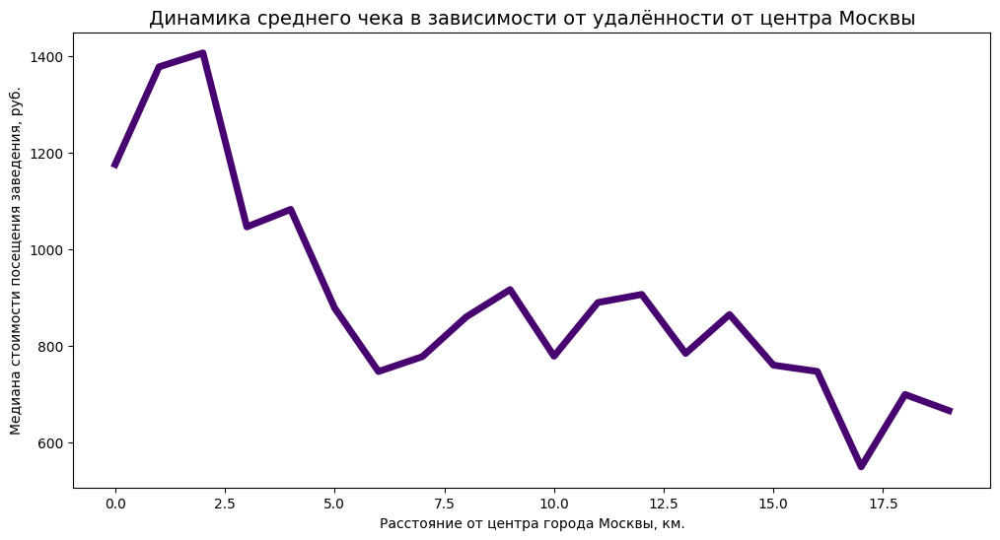

In [106]:
# визуализация динамики цен в зависимости от удалённости от центра Москвы: общие данные
price_mid_km.plot(x='distance', y='middle_avg_bill', kind='line', linewidth=5, color='#47036F', legend=False, figsize=(12, 6))
plt.title('Динамика среднего чека в зависимости от удалённости от центра Москвы', fontsize=14)
plt.ylabel('Медиана стоимости посещения заведения, руб.')
plt.xlabel('Расстояние от центра города Москвы, км.')
plt.show()

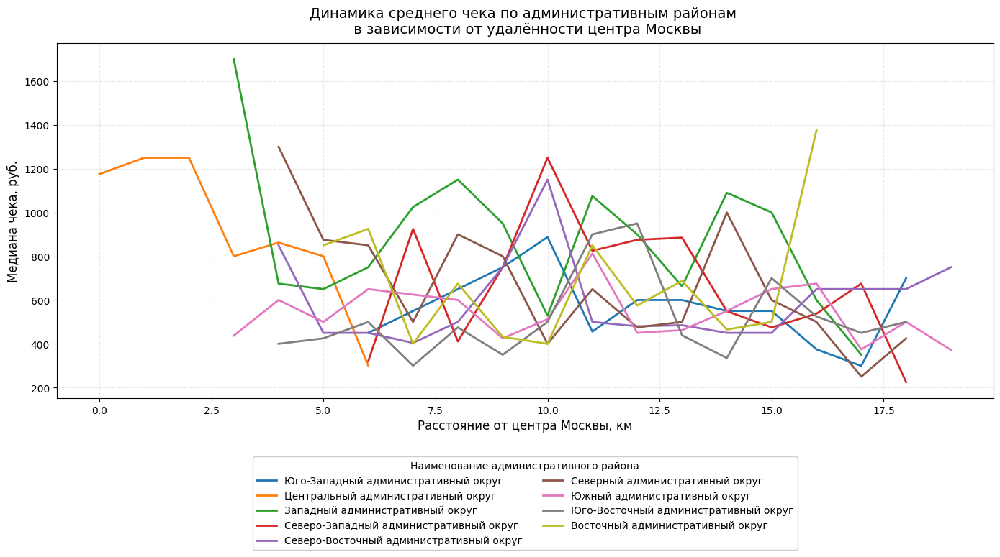

In [107]:
# визуализация динамики цен в зависимости от удалённости от центра Москвы: данные по административным районам
# агрегация данных
bill_by_distr['distance_bin'] = bill_by_distr['distance'].round().astype(int)
bill_grouped = (bill_by_distr.groupby(['district', 'distance_bin'])['middle_avg_bill'].median().reset_index(name='avg_bill_median'))

# сортируем данные, чтобы линии на графике не "ломались"
bill_grouped = bill_grouped.sort_values(['district', 'distance_bin'])

# устанавливаем количество цветов в палитре
colors = sns.color_palette('tab10', n_colors=bill_grouped['district'].nunique())

# визуализация
plt.figure(figsize=(14, 7))

for idx, district in enumerate(districts):
    data = bill_grouped[bill_grouped['district'] == district]
    plt.plot(data['distance_bin'], data['avg_bill_median'], label=str(district), color=colors[idx], linewidth=2)

plt.title('Динамика среднего чека по административным районам \n в зависимости от удалённости центра Москвы', fontsize=14, pad=10)
plt.xlabel('Расстояние от центра Москвы, км', fontsize=12)
plt.ylabel('Медиана чека, руб.', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')

# оформление легенды
plt.legend(title='Наименование административного района', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, framealpha=0.95, frameon=True)

# оформление вывода
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

**Вывод:** в данном тематическом блоке исследования перед нами стояла задача изучения и анализа стоимости услуг в заведениях общепита в разрезе административных округов и в разрезе удалённости от центра города Москва.

На основании рассчётов средних значений цен в разрезе административных округов нами были получены и визуализированы в виде фоновой куартограммы данные, свидетельствующие о высокой ценовой категории в Центральном и Западном административных округах. 

Центральный административный округ по целому ряду причин демонстрирует высокий уровень средних цен: стоимость квадратного метра в центре столицы, интенсивный трафик посетителей, развитая транспортная сеть, пешеходная доступность рекреационных и туристических зон, незначительная удалённость от деловых центров, высокая плотность расположения административных учреждений, вузов, объектов культуры.

Высокий средний чек в заведениях Западного административного округа связан с наличием в составе одиозных протуберанцев и эксклавов, таких, как Сколково и Рублёвка, исторически являющих собой территории дачной и усадебной застройки советской, а позднее российской элиты, фешенебельные коттеджные посёлки знаменитостей и писателей, резиденции высших должностных лиц государства (к примеру, Горки-2, Горки-10). К этой же административной единице относится и огромнейший комплекс аэропорта Внуково.

На территориях остальных административных районов ценовой диапазон существенно ниже в силу характера и плотности типовой застройки.

График динамики ценового диапазона в зависимости от удалённости от центра Москвы наглядно показывает 
**прямую зависимость стоимости товаров и услуг заведения от удалённости до географического центра Москвы**. Также на графике мы видим провал на отметке в 6 километров и на отметке 17.0 - 17.3 километра. Оба провала напрямую связаны с расположением на этих расстояниях от центра Москвы ТТК (Третьего транспортного кольца) и МКАД (Московской кольцевой автомобильной дороги). По обе стороны от каждого провала на графике - характерные снижения с последующим ростом стоимости на улуги из-за непосредственного близкого расположения автодороги и удаления от неё.

<a id=3.13></a>
### 3.13. Низкорейтинговые заведения как зона роста

Ранее нами были изучены верхний и нижний сегмент рынка общественного питания Москвы, где:
* очень низкая конкуренция (490 улиц с 1 объектом);
* очень высокая конкуренция (15 топ-улиц с максимальной концентраций объектов общепита).

Осталось изучить **сегмент слабой конкуренции.** Поскольку, потенциальными точками роста могут стать те улицы, на которых расположено мало объектов общественного питания или объекты питания работают в некомфортном для посетителей графике, или рейтинг заведения, даже с учётом удачной локации и приемлемого графика, оставляет желать лучшего. Открытие нового заведения общественного питания в таких условиях может стать прибыльным.

In [108]:
# условный порог хорошего сервиса установим на отметке 4.0 и выберем из датафрейма все объекты с рейтингом ниже
display(rest[rest['rating'] < 4.0].shape[0], rest[rest['rating'] < 4.0].shape[0] / len(rest) * 100)
bad_rat = rest[rest['rating'] < 4.0]
display(bad_rat.shape)
bad_rat.head()

1168

13.898143741075678

(1168, 19)

,name,category,address,district,hours,lat,lng,rating,price,avg_bill,middle_avg_bill,middle_coffee_cup,chain,seats,street,day,time,is_24/7,distance
36,Пекарня № 1 Грузинская кухня,кафе,"Москва, Коровинское шоссе, 33А",Северный административный округ,"ежедневно, 10:00–22:00",55.88,37.52,3.90,NaN,NaN,NaN,NaN,False,21.00,Коровинское шоссе,ежедневно,10:00–22:00,False,15.88
37,Халяль закусочная,кафе,"Москва, Коровинское шоссе, 46, стр. 5",Северный административный округ,"ежедневно, 08:00–23:00",55.89,37.52,3.90,NaN,NaN,NaN,NaN,False,NaN,Коровинское шоссе,ежедневно,08:00–23:00,False,16.54
40,Кафе,кафе,"Москва, Ижорская улица, 18, стр. 1",Северный административный округ,NaN,55.90,37.52,3.70,NaN,NaN,NaN,NaN,False,NaN,Ижорская улица,NaN,NaN,False,17.06
42,Варня кафе,быстрое питание,"Москва, Коровинское шоссе, 29, корп. 1",Северный административный округ,"ежедневно, 09:00–23:00",55.88,37.52,3.80,NaN,NaN,NaN,NaN,False,46.00,Коровинское шоссе,ежедневно,09:00–23:00,False,15.60
44,Кафетерий,кафе,"Москва, Ангарская улица, 24А",Северный административный округ,NaN,55.88,37.52,3.80,NaN,NaN,NaN,NaN,True,8.00,Ангарская улица,NaN,NaN,False,15.25


Заведений с плохим и очень плохим рейтингом (ниже отметки 4.0) насчитывается 1168, что составляет почти 14% всех объектов общественного питания Москвы. Сгруппируем эти данные по улицам и изучим количество объектов на них. В случае, если на улице будет только один объект - исключим её из этого тематического блока исследования.

In [109]:
# удаление из низкорейтинговых заведений объектов, являющихся единичными по расположению на какой-либо улице
one_obj = bad_rat['street'].value_counts()
to_remove = one_obj[one_obj == 1].index
bad_rat = bad_rat[~bad_rat['street'].isin(to_remove)] # исключили улицы с одним объектом
bad_rat = bad_rat[~bad_rat['street'].isin(street_top_15_index)] # исключили улицы, которые раее попали в топ-15
bad_rat.shape

(665, 19)

In [110]:
# оставляем в датафрейме ключевые признаки в необходимом смысловом порядке
bad_rat = bad_rat[['name', 'category', 'address', 'district', 'street', 'distance', 'rating', 'seats', 
         'middle_avg_bill', 'middle_coffee_cup', 'chain', 'day', 'time', 'is_24/7']]
bad_rat.head()

,name,category,address,district,street,distance,rating,seats,middle_avg_bill,middle_coffee_cup,chain,day,time,is_24/7
36,Пекарня № 1 Грузинская кухня,кафе,"Москва, Коровинское шоссе, 33А",Северный административный округ,Коровинское шоссе,15.88,3.90,21.00,NaN,NaN,False,ежедневно,10:00–22:00,False
37,Халяль закусочная,кафе,"Москва, Коровинское шоссе, 46, стр. 5",Северный административный округ,Коровинское шоссе,16.54,3.90,NaN,NaN,NaN,False,ежедневно,08:00–23:00,False
40,Кафе,кафе,"Москва, Ижорская улица, 18, стр. 1",Северный административный округ,Ижорская улица,17.06,3.70,NaN,NaN,NaN,False,NaN,NaN,False
42,Варня кафе,быстрое питание,"Москва, Коровинское шоссе, 29, корп. 1",Северный административный округ,Коровинское шоссе,15.60,3.80,46.00,NaN,NaN,False,ежедневно,09:00–23:00,False
44,Кафетерий,кафе,"Москва, Ангарская улица, 24А",Северный административный округ,Ангарская улица,15.25,3.80,8.00,NaN,NaN,True,NaN,NaN,False


In [111]:
# низкорейтинговые заведения: улицы
bad_rat['street'].value_counts().to_frame().head(15)

,count
street,
Новоясеневский проспект,14
Волгоградский проспект,12
Измайловское шоссе,10
Рязанский проспект,10
шоссе Энтузиастов,9
Щёлковское шоссе,9
Ореховый бульвар,8
улица Авиаконструктора Миля,8
"МКАД, 14-й километр",8


In [112]:
# низкорейтинговые заведения: категории
bad_rat['category'].value_counts().to_frame()

,count
category,
кафе,306
ресторан,109
быстрое питание,97
кофейня,75
пиццерия,21
"бар,паб",21
булочная,18
столовая,18


In [113]:
# низкорейтинговые заведения: сетевые и несетвые
bad_rat['chain'].value_counts().to_frame()

,count
chain,
False,434
True,231


In [114]:
# низкорейтинговые заведения: размещение в разрезе административных районов и их улиц
bad_rat.groupby('district').agg({'category':'count', 'street':'nunique'}
                                                              ).sort_values(by='category', ascending=False)

,category,street
district,,
Юго-Восточный административный округ,115,32
Восточный административный округ,100,29
Западный административный округ,96,33
Южный административный округ,84,24
Северный административный округ,67,24
Северо-Восточный административный округ,64,25
Центральный административный округ,53,21
Юго-Западный административный округ,48,14
Северо-Западный административный округ,38,14



 Низкорейтинговые заведения по административным округам в разрезе категорий 



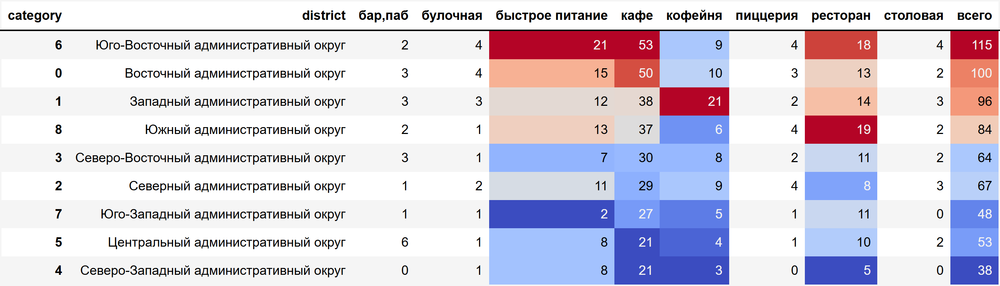

In [115]:
# низкорейтинговые заведения: представленность в административных округах в разрезе категорий
pivot_df = (bad_rat.pivot_table(index='district', columns='category', values='name', aggfunc='count',
                                margins=True, margins_name='всего').fillna(0).astype(int).reset_index().\
    sort_values(by=['кафе', 'быстрое питание', 'кофейня', 'ресторан', 'всего'], ascending=False).iloc[1:])

# градиентная заливка для ключевых значений
styled_table = pivot_df.style.background_gradient(subset=['кафе', 'быстрое питание', 'кофейня', 'ресторан', 'всего'], cmap='coolwarm')

# убираем возможные ограничения высоты таблицы в рендерере
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Низкорейтинговые заведения по административным округам в разрезе категорий \n')

# оформление в виде изображения
dfi.export(styled_table, 'bad_rating_districts_heatmap.png', table_conversion='chrome', max_rows=len(pivot_df), fontsize=9, dpi=400)
display(Image(filename='bad_rating_districts_heatmap.png', width=900))

In [116]:
# топ-15 улиц по количеству низкорейтинговых заведений
bad_rat.query('category != "кофейня"').groupby('street').agg({'category':
                                                              'count'}).sort_values(by='category', ascending=False)

,category
street,
Новоясеневский проспект,13
Волгоградский проспект,10
Измайловское шоссе,9
"МКАД, 14-й километр",8
Ореховый бульвар,8
...,...
улица Архитектора Власова,1
"район Левобережный, территория парка Дружбы",1
улица Маршала Федоренко,1


In [117]:
# топ-15 улиц по количеству низкорейтинговых заведений в разрезе категорий, там, где нет кофеен
no_caf = bad_rat.query('category != "кофейня"').pivot_table(index='street', columns='category', values='name', aggfunc='count', margins=True, \
                             margins_name='всего').fillna(0).astype(int).reset_index().\
sort_values(by=['всего'], ascending=False)[1:]
no_caf = bad_rat.query('category != "кофейня"')

In [118]:
# по списку улиц, где общепит имеет низкий рейтинг и отсутствуют кофейни, собрали отдельный датафрейм
low_rat_index = no_caf['street'].to_list()

low_rat = rest.loc[rest['street'].isin(low_rat_index), \
['name', 'category', 'district', 'street', 'distance', 'hours', 'rating', 'chain',
 'middle_avg_bill', 'middle_coffee_cup', 'seats', 'day', 'time', 'is_24/7']]

In [119]:
# количество заведений на улицах с низкорейтинговыми объектами
no_caf.shape[0]

590

In [120]:
# наиболее распространённые форматы режима работы и посадочных мест в разрезе категорий у низкорейтинговых объектов
results_list = []

for category in no_caf['category'].unique():
    # выбираем данные для этой категории
    data = no_caf.loc[no_caf['category'] == category, ['day', 'time', 'seats']]
    
    # считаем комбинации, берём дванаибольших и преобразуем в датафрейм с явным именем столбца
    counts = data.value_counts().head(2).reset_index(name='count')
    
    # добавляем столбец с названием категории
    counts['category'] = category
    
    # сохраняем часть в список
    results_list.append(counts)

# объединяем все части в один датафрейм
results = pd.concat(results_list, ignore_index=True)
results

,day,time,seats,count,category
0,ежедневно,круглосуточно,180.00,3,кафе
1,ежедневно,09:00–21:00,50.00,2,кафе
2,ежедневно,круглосуточно,12.00,3,быстрое питание
3,ежедневно,круглосуточно,40.00,3,быстрое питание
4,ежедневно,07:00–00:00,75.00,2,ресторан
5,ежедневно,10:00–22:00,0.00,2,ресторан
6,ежедневно,10:00–22:00,45.00,2,пиццерия
7,ежедневно,10:00–22:00,20.00,1,пиццерия
8,ежедневно,08:00–21:00,100.00,1,булочная
9,ежедневно,09:00–21:00,90.00,1,булочная


In [121]:
# наиболее распространённый средний чек за посещение в разрезе категорий 
results_list = []

for category in no_caf['category'].unique():
    # выбираем данные для этой категории
    data = no_caf.loc[no_caf['category'] == category, ['middle_avg_bill', 'chain']]
    
    # считаем комбинации, берём две самые большие и преобразуем в датафрейм с явным именем столбца
    counts = data.value_counts().head(2).reset_index(name='count')
    
    # добавляем столбец с названием категории
    counts['category'] = category
    
    # сохраняем часть в список
    results_list.append(counts)

# объединяем все части в один датафрейм
results2 = pd.concat(results_list, ignore_index=True)
results2

,middle_avg_bill,chain,count,category
0,750.00,False,3,кафе
1,1000.00,False,3,кафе
2,300.00,False,3,быстрое питание
3,400.00,True,2,быстрое питание
4,300.00,False,3,ресторан
5,300.00,True,2,ресторан
6,500.00,False,2,пиццерия
7,266.00,True,1,пиццерия
8,200.00,True,1,булочная
9,225.00,False,1,булочная


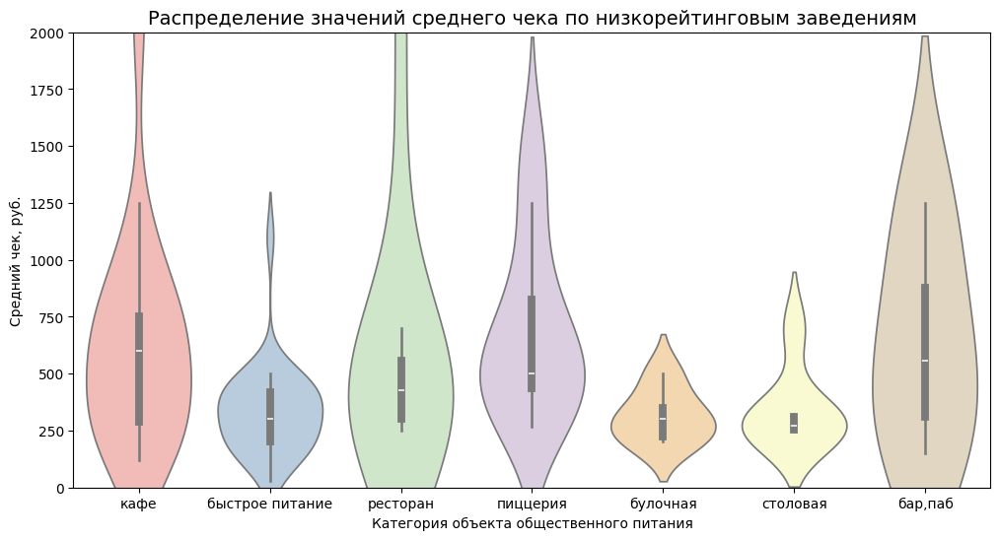

In [122]:
# визуализация распределения средних рейтингов по категориям заведений
plt.figure(figsize=(12, 6))
plt.title('Распределение значений среднего чека по низкорейтинговым заведениям', fontsize=14)
sns.violinplot(x=no_caf['category'], y=no_caf['middle_avg_bill'], palette='Pastel1');
plt.ylabel('Средний чек, руб.')
plt.xlabel('Категория объекта общественного питания')
plt.ylim([0,2000])
plt.show()

С помощью последовательной группировки данных по локализации и категориям заведений общественного питания мы смогли выделить несколько административных районов и улиц на них, где объекты общественного питания представлены слабо и имеют относительно низкий рейтинг. Следовательно, это перспективные территории для размещения не столько пилотного объекта общепита, который планирует открывать фонд «Shut Up and Take My Money», сколько обозначение зоны роста для второго или даже третьего заведения в сети. Мы установили, что в разрезе административных округов в данном случае речь идёт о САО, СВАО, ЮЗАО, СЗАО и вышеперечисленных улицах.

Типичный портрет низкорейтингового заведения составлен на основе 590 объектов. Относительно режима работы мы можем утверждать, что все эти заведения работают для посетителей ежедневно и по удлинённому времени с 7/8/10 утра до 21/22/23 часов или вовсе круглосуточно. Посадка в таких заведениях балансирует около значения 50 мест ±15 мест. «Тяжеловесами» выступают столовые по 100 мест и бары на 200 человек. Общую картину дополняют сведения о среднем чеке в этих заведениях. Посетители этих заведений готовы потратить за одно посещение 250 – 500 рублей, и этот диапазон характерен вообще для всех категорий объектов с низким рейтингом. Средний чек в ресторане здесь соответствует отметке 300 рублей, одновременно с этим в кафе с низким рейтингом посетители тратят от 700 до 1000 рублей. Вероятно, уровень качества сервиса в кафе существенно выше или мы имеем дело с сетевыми заведениями, формат работы с посетителями в которых стандартизирован и сохраняет высокую планку на территории всей Москвы в равной мере. Если переложить полученные численные характеристики на жизненные реалии, получатся небольшие заведения, в которые посетители приходят только за пищей телесной, а пища духовная, атмосфера, дизайн и все остальные сопутствующие эмоциональной картины восприятия заведения либо отсутствуют напрочь (в лучшем случае) или находятся в таком удручающем состоянии, что и без того средненькое заведение теряет баллы… и посетителей.

<a id=3.14></a>
### 3.14. График работы заведений и его зависимость от расположения и категории заведения

In [123]:
# создаём профильный датафрейм с информацией по графику и времени работы объектов
sked = rest[['category', 'district', 'distance', 'day', 'time']]
sked.shape[0]

8404

In [124]:
# количество пропусков по дням работы
print(sked[['day', 'time']].isna().sum())

# выводим пропуски в данных по графику работы
sked[(sked['day'].isna())].sort_values(by='distance')

day      536
time    3375
dtype: int64


,category,district,distance,day,time
4315,кафе,Центральный административный округ,1.38,NaN,NaN
4478,кафе,Центральный административный округ,1.57,NaN,NaN
5270,кафе,Центральный административный округ,1.81,NaN,NaN
3820,кафе,Центральный административный округ,2.13,NaN,NaN
4157,кафе,Центральный административный округ,2.35,NaN,NaN
...,...,...,...,...,...
217,кафе,Северо-Восточный административный округ,19.28,NaN,NaN
7775,кафе,Южный административный округ,19.30,NaN,NaN
7746,кафе,Южный административный округ,19.33,NaN,NaN
7774,кафе,Юго-Западный административный округ,19.47,NaN,NaN


Как мы могли убедиться, отсутствие информации о графике работы не связано с удалённостью от центра Москвы. Объекты, с отсутствующей информацией о графике работы можно встретить и в самом сердце столицы. Поскольку, мы не можем восстановить данные ни логическим, ни синтетиским путём, удаляем пропуски по признаку `day` и исследуем оставшиеся значения.

In [125]:
# удаляем пропуски в данных
sked = sked.dropna(subset=['day']).reset_index(drop=True)
sked.shape[0]

7868

In [126]:
# количество пропусков по дням работы
print(sked[['time']].isna().sum())
print(sked[['time']].isna().sum() / len(sked))

time    2839
dtype: int64
time   0.36
dtype: float64


Поскольку у нас в актуальных данных отсутствуют значения в 36% строк по признаку `time`. В нашем распоряжении 5029 строк с данными по этому признаку. Предлагаем вывести уникальные значения, которые присутствуют в массиве, и их количество.

In [127]:
display(sked['time'].nunique())
sked['time'].unique()

241

array(['10:00–22:00', nan, '09:00–22:00', '10:00–23:00', '12:00–00:00',
       'круглосуточно', '10:00–21:00', '08:00–22:00', '13:00–00:00',
       '09:00–21:00', '08:00–21:00', '09:00–23:00', '08:00–23:00',
       '11:00–00:00', '09:00–02:00', '12:00–23:00', '12:00–03:00',
       '16:00–06:00', '11:00–23:00', '09:00–06:00', '10:00–21:30',
       '08:00–00:00', '06:00–20:00', '10:00–20:00', '11:00–22:00',
       '10:30–23:00', '07:00–00:00', '13:00–04:00', '11:00–19:00',
       '16:00–04:00', '09:00–00:00', '10:00–01:00', '11:00–22:30',
       '07:30–00:30', '08:30–23:30', '13:00–01:00', '11:00–06:00',
       '07:00–23:00', '18:00–05:00', '11:00–21:30', 'перерыв 12:00–12:32',
       '10:00–00:00', '09:00–20:00', '11:30–00:00', '11:00–02:00',
       '07:00–02:00', '09:00–23:45', '12:00–05:00', '12:00–02:00',
       '12:00–01:00', '14:00–02:00', '09:00–21:30', '07:00–22:00',
       '10:00–04:00', '12:00–23:45', '08:00–19:00', '11:00–22:45',
       '17:00–05:00', '11:00–01:00', '13:00–23:

Универсальный макет графика работы объектов общественного питания представляет собой следующую схему:

| день недели | время             | абсолютное значение, ед. | относительное значение, % |
|-------------|-------------------|:------------------------:|:-------------------------:|
| ежедневно    | круглосуточно     | 729                      | 9.2                       |
| ежедневно    | временной интервал| 4290                     | 54.5                      |
|             | **всего:**        | **5019**                 | **63.7**                  |
| список дней | круглосуточно     | 44                       | 1.5                       |
| список дней | временной интервал| 767                      | 9.7                       |
|             | **всего:**        | **2849**                 | **36.2**                  |

Предстоит установить взаимосвязь категории объекта общественного питания, его дислокацию, удалённость от центра города Москвы и на основании этих черт составить характерный портрет. Но даже на основании этих подсчётов мы можем утверждать, что большинство заведений общественного питания открыты для посетителей ежедневно на определённом временном интревале. Мы видим, что в числе ожидаемого графика работы с временным интревалом в том числе находятся пропуски значений, отметки об обеденных перерывах в работе объекта, указания на день недели. Пропуски заполним нулями.

In [128]:
# пропуски значений по времени работы заполним нулями
sked['time'] = sked['time'].fillna(0)

Формируем массив данных с заведениями ежедневной формы работы:

In [129]:
# в этом массиве данных собраны заведения, работающие ежедневно круглосуточно и по времени
skedallday = sked.query('day == "ежедневно"')
len(skedallday) / len(sked)*100

63.79003558718861

Формируем массив данных с заведениями, работающих по установленному графику:

In [130]:
# в этом массиве данных собраны заведения, работающие по графику
skedtime = sked.query('day != "ежедневно"')

In [131]:
# на 2849 строк информации по таким объектам насчитывается 1064 индивидуальных графиков работы
skedtime['day'].nunique()

1064

In [132]:
# расщепляем строки и извлекаем какаждый временной интервал по отдельности
skedtime['day1'] = skedtime['day'].str.split('; ').str[0]
skedtime['day2'] = skedtime['day'].str.split('; ').str[1]
skedtime['day3'] = skedtime['day'].str.split('; ').str[2]
skedtime['day4'] = skedtime['day'].str.split('; ').str[3]
skedtime['day5'] = skedtime['time'].str.split('; ').str[0]
skedtime['day6'] = skedtime['time'].str.split('; ').str[1]
skedtime['day7'] = skedtime['time'].str.split('; ').str[2]
skedtime['day8'] = skedtime['time'].str.split('; ').str[3]

In [133]:
# расщепляем строки и извлекаем какаждый временной интервал по отдельности
skedtime['time1'] = skedtime['day1'].str.split(' ').str[1]
skedtime['time2'] = skedtime['day2'].str.split(' ').str[1]
skedtime['time3'] = skedtime['day3'].str.split(' ').str[1]
skedtime['time4'] = skedtime['day4'].str.split(' ').str[1]
skedtime['time5'] = skedtime['day5'].str.split(' ').str[1]
skedtime['time6'] = skedtime['day6'].str.split(' ').str[1]
skedtime['time7'] = skedtime['day7'].str.split(' ').str[1]
skedtime['time8'] = skedtime['day8'].str.split(' ').str[1]

In [134]:
# затираем значения в столбцах с днями и временем, оставляем только дни
skedtime['day1'] = skedtime['day1'].str.split(' ').str[0]
skedtime['day2'] = skedtime['day2'].str.split(' ').str[0]
skedtime['day3'] = skedtime['day3'].str.split(' ').str[0]
skedtime['day4'] = skedtime['day4'].str.split(' ').str[0]
skedtime['day5'] = skedtime['day5'].str.split(' ').str[0]
skedtime['day6'] = skedtime['day6'].str.split(' ').str[0]
skedtime['day7'] = skedtime['day7'].str.split(' ').str[0]
skedtime['day8'] = skedtime['day8'].str.split(' ').str[0]

После того, как мы получили максимальные данные о графике и времени работы объектов, мы можем исключить из анализа данные об обеденных перерывах в работе нескольких объектов. Само по себе обеденное время, установленное для объекта общественного питания, является атавизмом и неприятным исключением из правил хорошего тона по отношению к посетителям в XXI веке.

In [135]:
# перерывы в работе
skedtime['day5'].unique()

array([nan, 'перерыв', 'перерывы'], dtype=object)

In [136]:
# перерывы в работе
skedtime['time5'].unique()

array([nan, '12:00–12:32', '12:00–13:30', '11:00–12:00', '17:00–18:00',
       '05:00–07:00', '10:00–12:00', '10:00–20:00', '12:00–13:00'],
      dtype=object)

In [137]:
# убираем перерывы из исследования
skedtime = skedtime[['category', 'district', 'distance', 'day1', 'time1', 'day2', 'time2', 
                     'day3', 'time3', 'day4', 'time4', 'day6', 'time6', 'day7', 'time7', 'day8', 'time8']]

In [138]:
# в целях последующего объединения, переименовываем два столбца
skedallday = skedallday.rename(columns={'day':'day1', 'time':'time1'})

In [139]:
# объединение массивов и заполнение появившихся пропусков отбивкой
sked = pd.concat([skedallday, skedtime], axis=0, ignore_index=True).fillna('нет информации')

Выполним расчёт частотности вхождения того или иного дня в график работы объекта питания.


 Дни работы категории кафе:


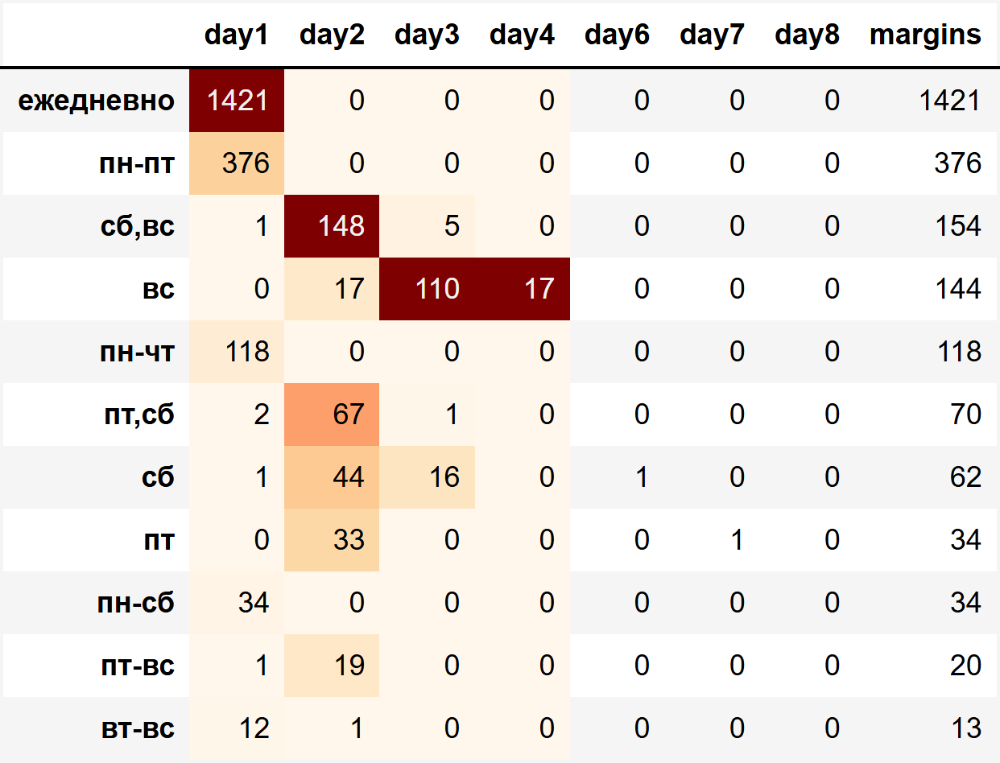


 Часы работы категории кафе:


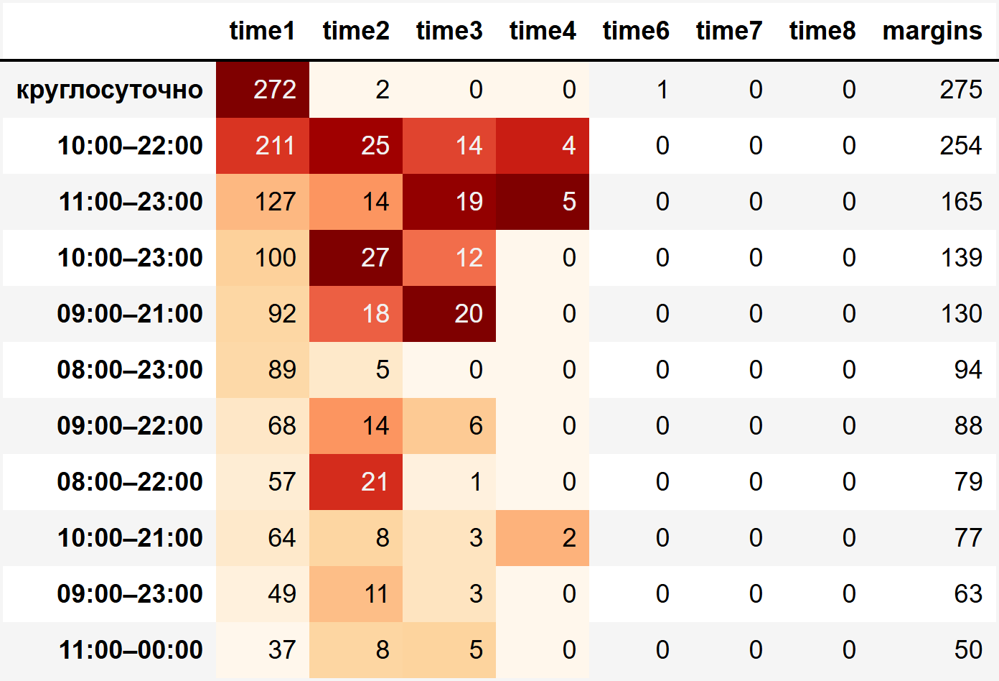


 Дни работы категории столовая:


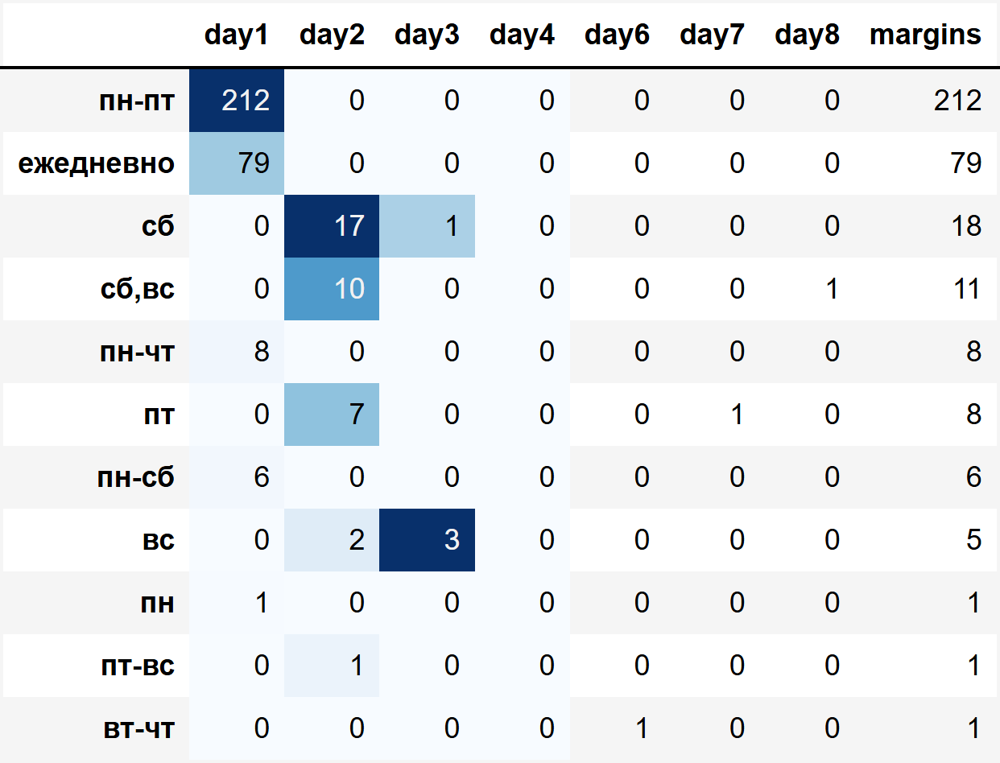


 Часы работы категории столовая:


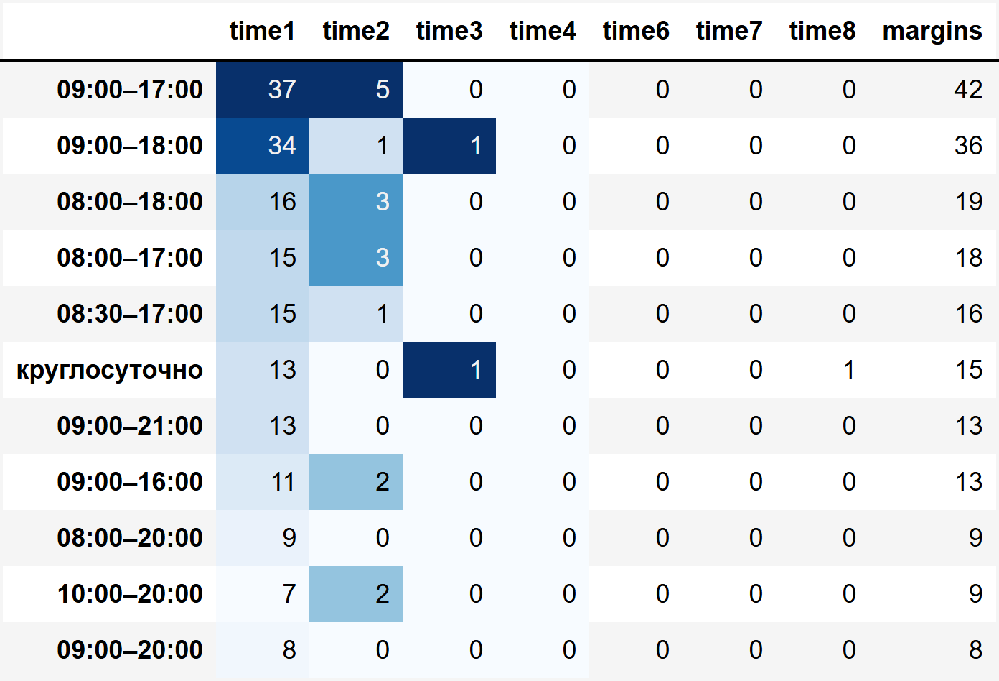


 Дни работы категории ресторан:


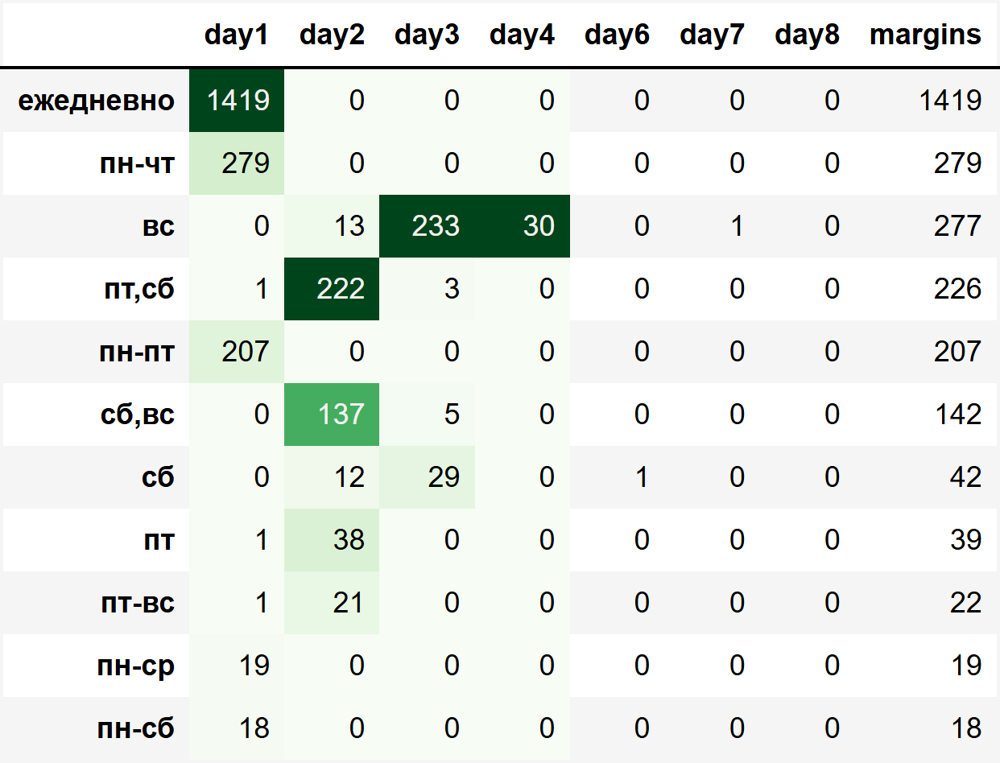


 Часы работы категории ресторан:


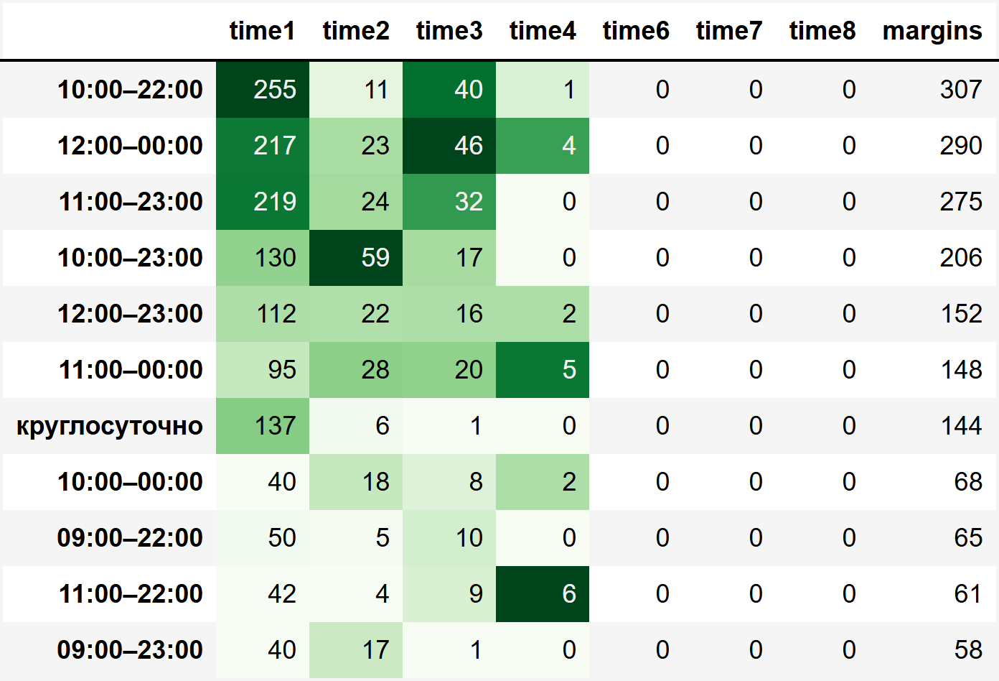


 Дни работы категории кофейня:


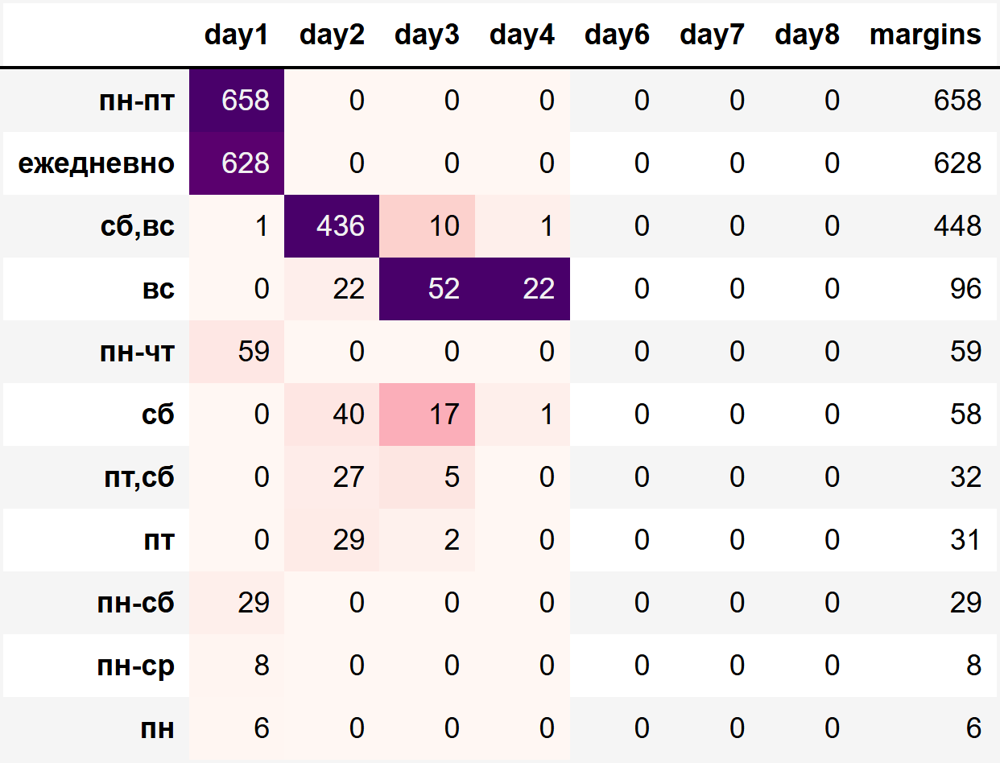


 Часы работы категории кофейня:


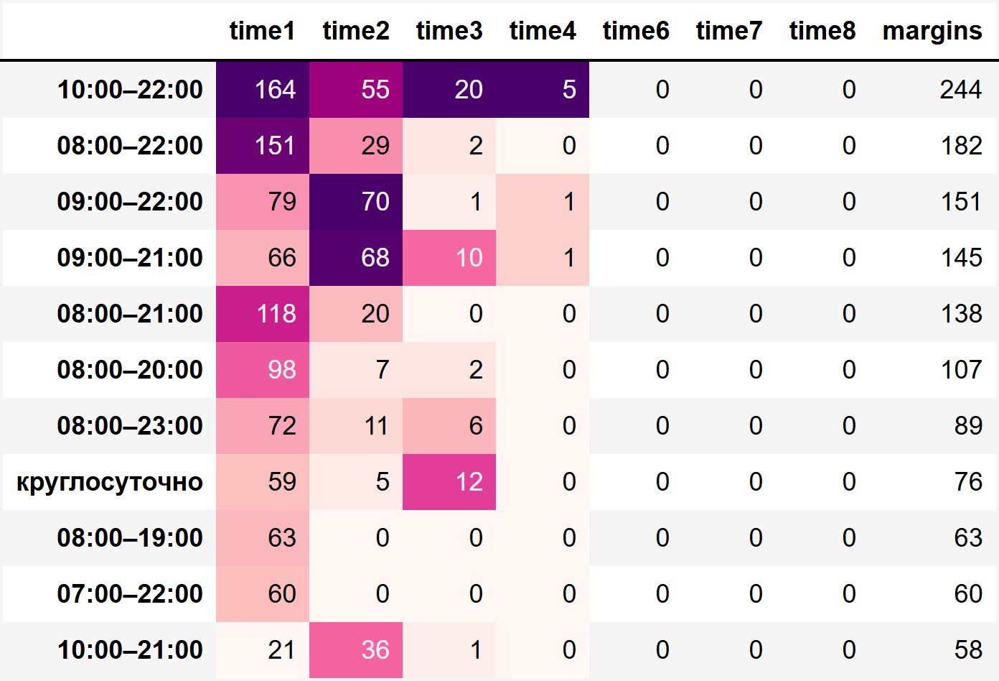


 Дни работы категории пиццерия:


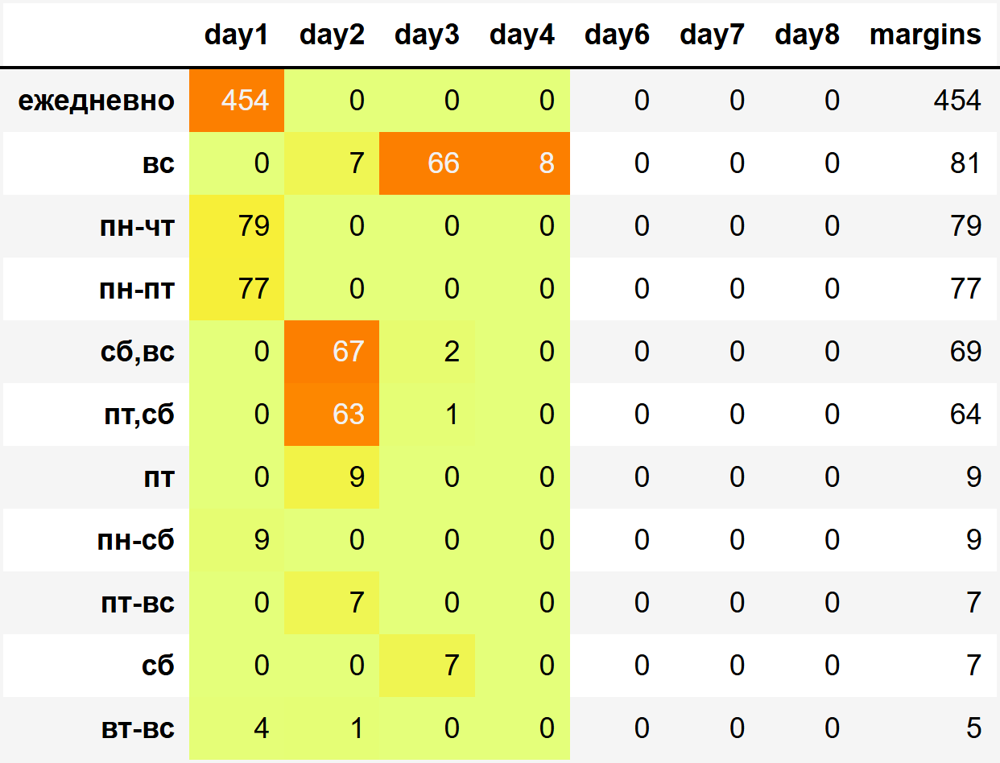


 Часы работы категории пиццерия:


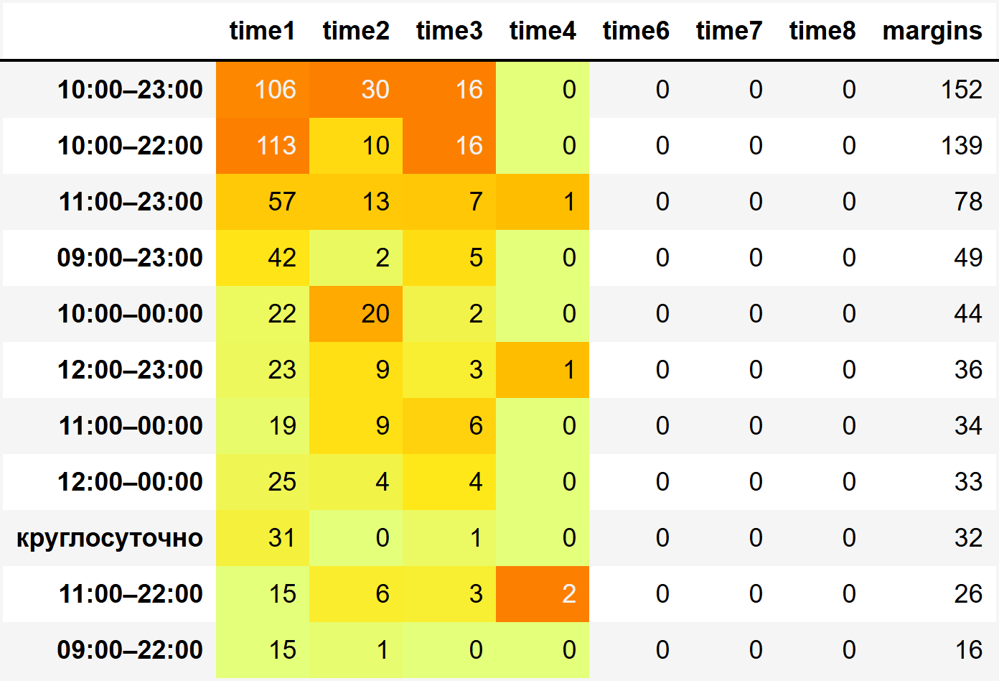


 Дни работы категории бар,паб:


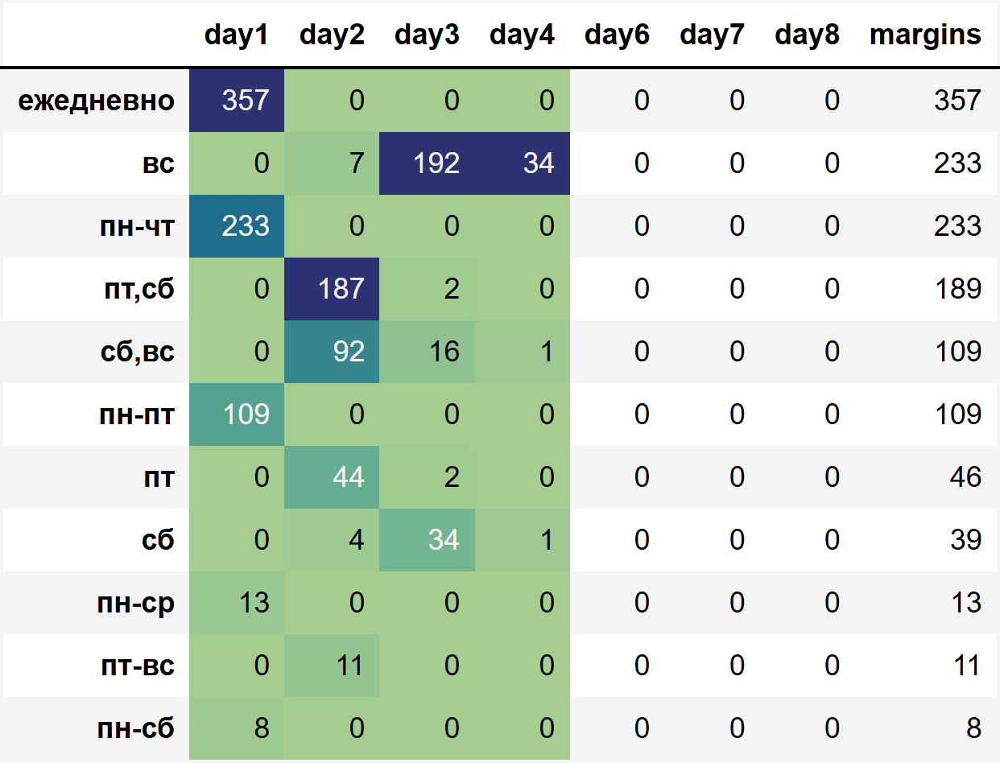


 Часы работы категории бар,паб:


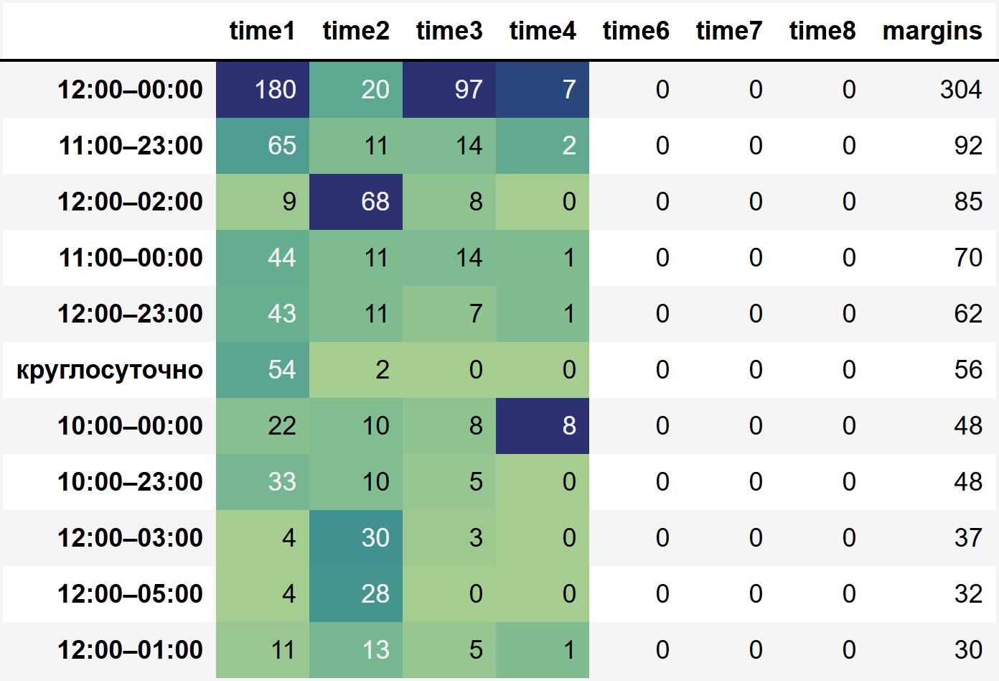


 Дни работы категории булочная:


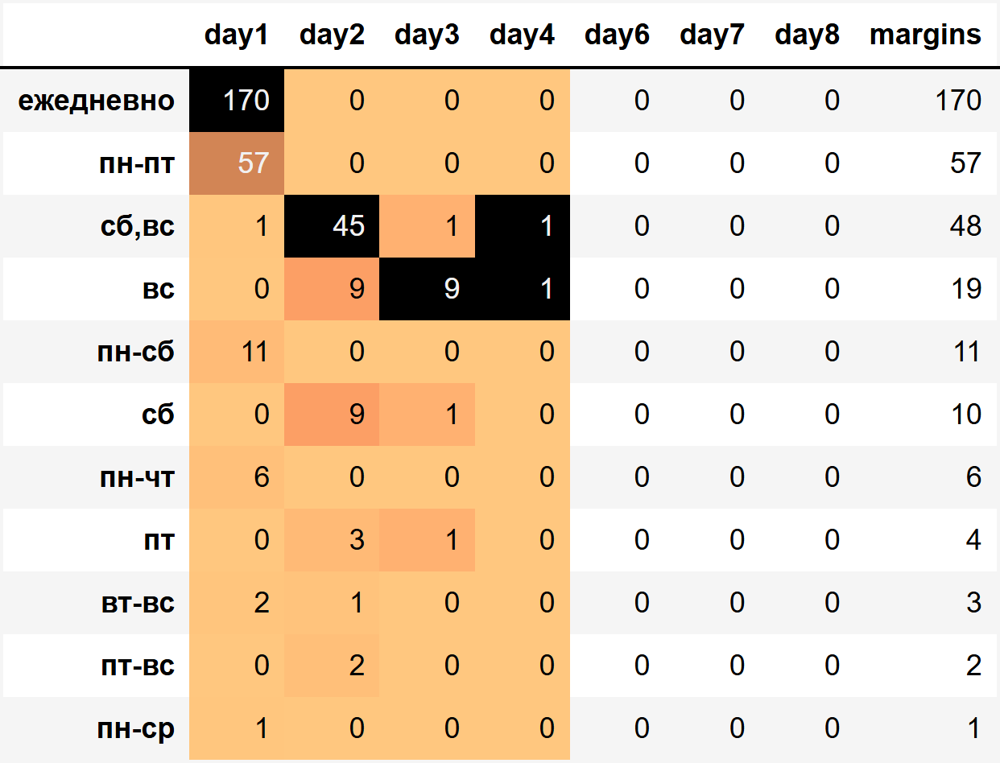


 Часы работы категории булочная:


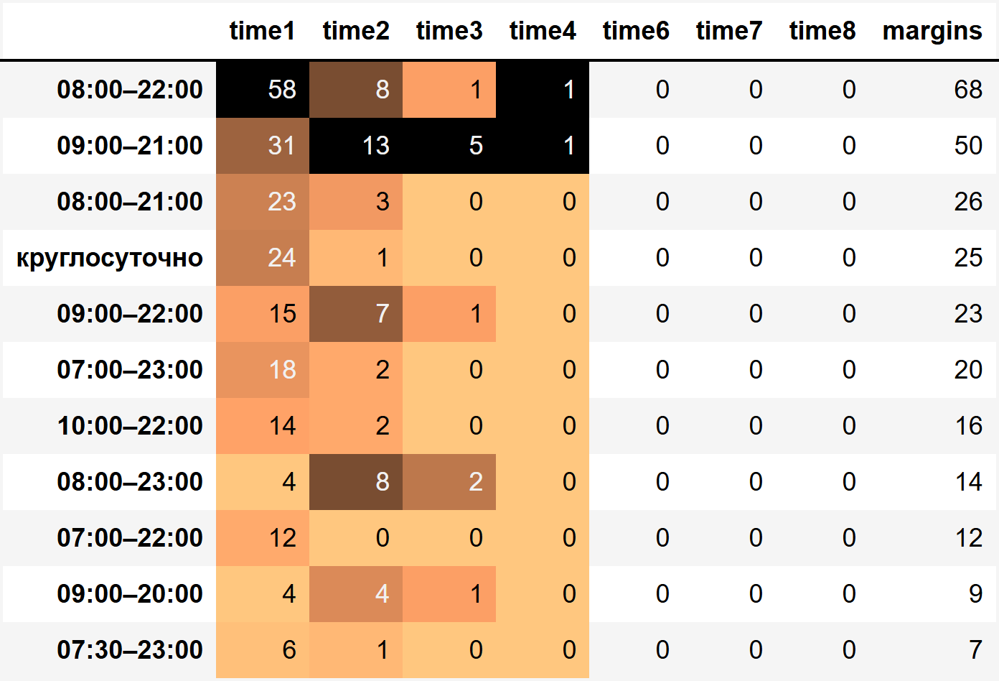


 Дни работы категории быстрое питание:


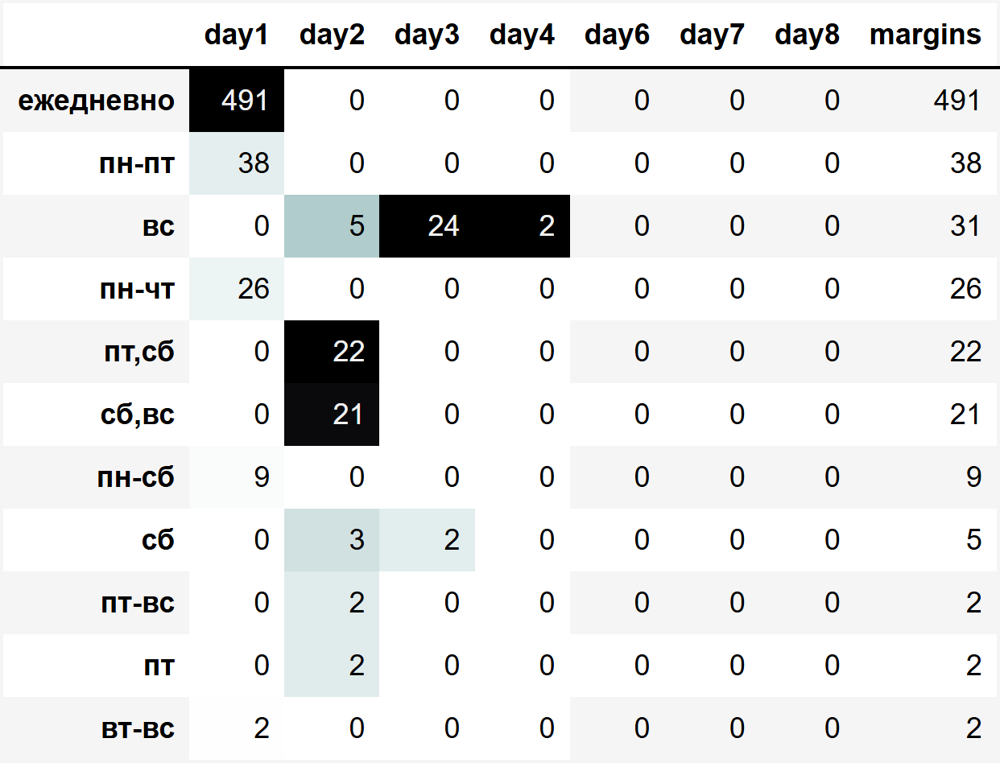


 Часы работы категории быстрое питание:


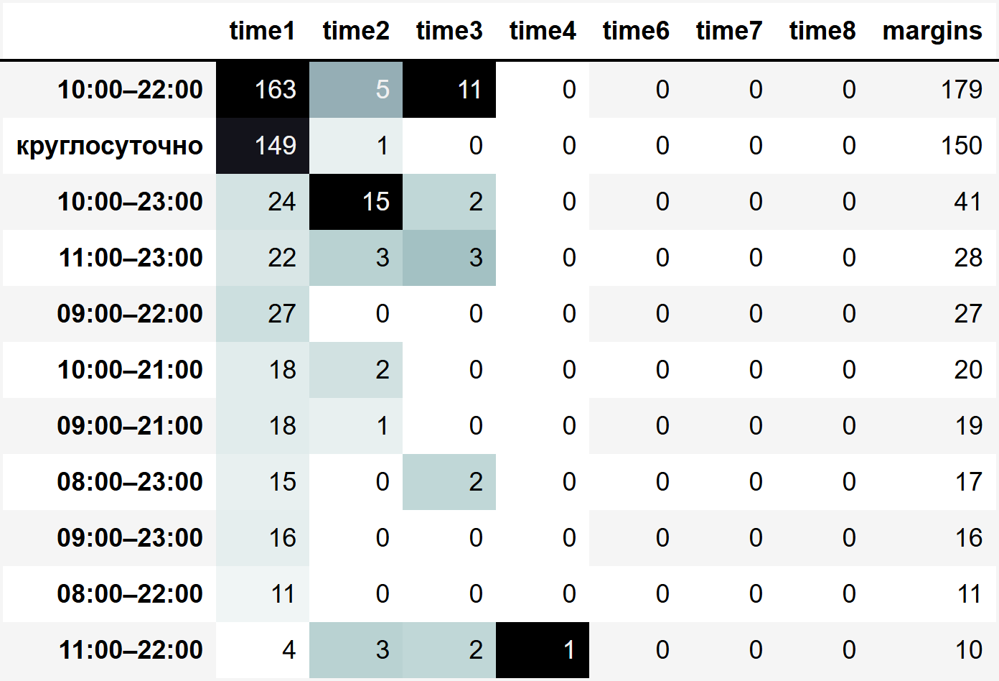

In [140]:
# настраиваем категории объектов общественного питания и задаём индивидуальные палитры
categories_config = {
    'кафе': 'OrRd',
    'столовая': 'Blues',
    'ресторан': 'Greens',
    'кофейня': 'RdPu',
    'пиццерия': 'Wistia',
    'бар,паб': 'crest',
    'булочная': 'copper_r',
    'быстрое питание': 'bone_r'
}

# списки столбцов для удобства
day_cols = ['day1', 'day2', 'day3', 'day4', 'day6', 'day7', 'day8']
time_cols = ['time1', 'time2', 'time3', 'time4', 'time6', 'time7', 'time8']
day_subset = ['day1', 'day2', 'day3', 'day4']
time_subset = ['time1', 'time2', 'time3', 'time4']

# вспомогательная функция: расчёт частотности, сортировка и обрезка
def freq_table(df, cols, top_n=11):
    return (df[cols].agg({c: 'value_counts' for c in cols})
              .fillna(0).astype(int)
              .assign(margins=lambda x: x.sum(axis=1))
              .sort_values(by=cols, ascending=False)
              .sort_values(by='margins', ascending=False)
              [1:].head(top_n))

# убираем всевозможные ограничения по высоте для таблиц
table_style = [{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}]

# цикл по категориям заведений общественного питания
for cat, cmap in categories_config.items():
    df_cat = sked.query('category == @cat')

    # вложенный цикл по типу отчёта (дни / часы)
    for cols, subset, suffix, title in [
        (day_cols, day_subset, 'days', 'Дни работы категории'),
        (time_cols, time_subset, 'hours', 'Часы работы категории')
    ]:
        # расчёт частотности вхождений, сортировка и топ-11 значений частотности
        tab = (df_cat[cols].agg({c: 'value_counts' for c in cols})
                .fillna(0).astype(int)
                .assign(margins=lambda x: x.sum(axis=1))
                .sort_values(by=cols, ascending=False)
                .sort_values(by='margins', ascending=False)
                [1:].head(11))

        # применяем градиент к указанным ранее колонкам
        styled = tab.style.background_gradient(subset=subset, cmap=cmap).set_table_styles(table_style)
        filename = f'schedule_{cat}_{suffix}.png'
        
        # экспорт изображений
        dfi.export(styled, filename, table_conversion='chrome', max_rows=len(tab), fontsize=9, dpi=400)

        # последовательный вывод для репрезентативности материала
        print(f'\n {title} {cat}:')
        display(Image(filename=filename, width=500))

Из полученных данных выделим самые распространённые дни и время работы для каждой категории объекта общественного питания. И на основании этих "бест практис" установим взаимосвязь между графиком работы каждой категории и дислокацией по округам.


 Количество типовых объектов по режимам работы в разрезе административных округов: 



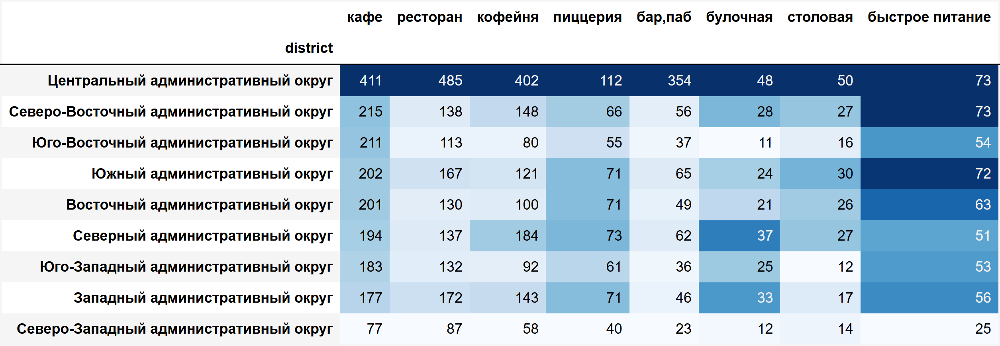

In [141]:
# объекты категории `кафе` с типовым графиком и режимом работы
sked_caffe = sked.query('(category == "кафе") & ((day1 == "ежедневно") | (day1 == "пн-пт") | \
(day2 == "сб,вс") | (time1 == "круглосуточно") | (time1 == "10:00–22:00") | (time1 == "11:00–23:00") \
| (time1 == "10:00–23:00") | (time2 == "10:00–22:00") | (time2 == "10:00–23:00") \
| (time2 == "08:00–22:00"))')['district'].value_counts().to_frame(name='кафе')

# объекты категории `ресторан`
sked_rest = sked.query('(category == "ресторан") & ((day1 == "ежедневно") | (time1 == "10:00–22:00") \
| (time1 == "11:00–23:00") | (time1 == "10:00–23:00"))')['district'].value_counts().to_frame(name='ресторан')

# объекты категории `кофейня`
sked_coffee = sked.query('(category == "кофейня") & ((day1 == "ежедневно") | (day1 == "пн-пт") \
| (day2 == "сб,вс") | (time1 == "10:00–22:00") | (time1 == "08:00–22:00") | (time1 == "08:00–21:00") \
| (time2 == "09:00–22:00") | (time2 == "09:00–21:00") \
| (time2 == "10:00–22:00"))')['district'].value_counts().to_frame(name='кофейня')

# объекты категории `пиццерия`
sked_pizza = sked.query('(category == "пиццерия") & ((day1 == "ежедневно") | (day1 == "пн-пт") \
| (day1 == "пн-чт") | (day2 == "пт,сб") | (day2 == "сб,вс") | (day3 == "вс") | (time1 == "10:00–23:00") \
| (time1 == "10:00–22:00") | (time1 == "11:00–23:00") | (time2 == "10:00–23:00") | (time2 == "10:00–00:00") \
| (time3 == "10:00–23:00") | (time3 == "10:00–22:00"))')['district'].value_counts().to_frame(name='пиццерия')

# объекты категории `бар,паб`
sked_pub = sked.query('(category == "бар,паб") & ((day1 == "ежедневно") | (day1 == "пн-пт") | (day1 == "пн-чт") \
| (day2 == "пт,сб") | (day2 == "сб,вс") | (day3 == "вс") | (day4 == "вс") | (time1 == "12:00–00:00") | \
(time1 == "11:00–23:00") | (time1 == "круглосуточно") | (time2 == "12:00–02:00") | (time3 == "12:00–00:00") | \
(time4 == "10:00–00:00") | (time4 == "12:00–00:00"))')['district'].value_counts().to_frame(name='бар,паб')

# объекты категории `булочная`
sked_bakery = sked.query('(category == "булочная") & ((day1 == "ежедневно") | (day1 == "пн-пт") \
| (time1 == "08:00–22:00") | (time1 == "09:00–21:00") | (time2 == "09:00–21:00") | (time2 == "08:00–23:00") \
| (time2 == "08:00–22:00"))')['district'].value_counts().to_frame(name='булочная')

# объекты категории `столовая` (исправлен баг с day1 вместо time1)
sked_eatery = sked.query('(category == "столовая") & ((day1 == "пн-пт") | (time1 == "09:00–17:00") \
| (time1 == "09:00–18:00") | (time1 == "08:00–18:00") | (time1 == "08:00–17:00") \
| (time1 == "08:30–17:00"))')['district'].value_counts().to_frame(name='столовая')

# объекты категории `быстрое питание`
sked_bistro = sked.query('(category == "быстрое питание") & ((day1 == "ежедневно") \
| (time1 == "10:00–22:00") | (time1 == "10:00–23:00") | (time1 == "11:00–23:00") \
| (time1 == "круглосуточно"))')['district'].value_counts().to_frame(name='быстрое питание')

# собираем таблицу по округам
sked_graph_loc = pd.concat([sked_caffe, sked_rest, sked_coffee, sked_pizza, sked_pub, sked_bakery, sked_eatery, sked_bistro], axis=1)

# градиентная заливка
styled_table = sked_graph_loc.style.background_gradient(subset=sked_graph_loc.columns, cmap='Blues').format(precision=0)

# убираем ограничения высоты
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Количество типовых объектов по режимам работы в разрезе административных округов: \n')

# экспорт в изображение
dfi.export(styled_table, 'schedule_by_district_heatmap.png', table_conversion='chrome', max_rows=len(sked_graph_loc), fontsize=9, dpi=400)
display(Image(filename='schedule_by_district_heatmap.png', width=900))

**Выводы:** самые распространённые форматы и графики работы каждой категории объекта общественного питания:
* для `кафе` характерным является ежедневный круглосуточный формат работы или очень длинный рабочий день с 10:00 до 22:00. Также весьма распространённый вариант работы: кафе работает с понедельника по пятницу в тчение 12 часов, а в субботу и воскресенье (или только в один из этих выходных дней) делает удлинённый рабочий день со сдвигом до 23 или 24 часов вечера. 
* для `ресторанов` в соответствии с их ориентированностью не только на пищу телесную, но и некоторую пищу духовную, чаще всего характерен ежедневный график работы с 10/11 утра до 22/23 часов вечера или 4-х/5-ти дневный формат с 10/11 до 23 часов, а в пятницу, субботу, воскресенье заведения открыты с 11 до 24 часов, а то и вовсе до 5 утра следующего дня.
* большинство `кофеен` выбирает формат пятидневки с удлинёнными выходными днями. В такой кофейне открытие для посетителей состоится либо в 8 утра, либо в 10 утра, последнего клиента ждут до 22 часов вечера. Второй по популярности формат: ежедневный график работы с 9/10 утра и до 22 часов вечера.
* `пиццерии` открыты ежедневно с 10 до 22/23 часов вечера, или работают по системе пятидневка с 10/11 утра до 23/24 часов, а в выходные они открываются на час позже и также работают до 23/24 часов. 
* в `бар` посетители могут попасть ежедневно с 12 до 24/2 часов. Ещё одна распространённая схема организации работы - это четырёх или пятидневный формат с 12 до 23, затем в субботу бары работают по удлинённому в ночь графику до 2/4 утра, а в воскресенье вновь возвращаются  к режиму с 12 до 23 часов.
* для `булочных` в равной мере характерным является ежедневный формат работы с 8 до 22 часов, или пятидневка с 9 до 21, а в выходные (субботу и воскресенье) они открыты по сокращенному на час режиму.
* нельзя придумать более режимного объекта питания, чем `столовая`. Дух ГОСТов и СанПинов витает над посетителями строго по расписанию с понедельника по пятницу с 8/8.30/9 утра до 17/18 часов вечера.
* объекты `быстрого питания` в соответствии со своей сутью и наименованием категории, работают для посетителей ежедневно с 10/11 до 22/23 часов или круглосуточно.

Нами была подготовлена сводная таблица количественных значений каждой категории объекта общественного питания в разрезе административного района. Расчёты позволили нам сделать вывод о наличии и сохранении определённого стандарта работы в отношении столовых и заведений быстрого питания. в угоду быстрому темпу жизни Центрального админитративного округа остальные категории заведений ориентированы либо на постоянное, либо на длительный временной диапазон возможности приёма посетителей. Однако, здесь мы также можем отметить одну характерную особенность, связанную с закрытием первичной потребности посетителя в приёме пищи, а именно: булочные, рестораны, кофейни на территории ЦАО в два раза чаще выбирают для себя очень длинный график работы. Кафе, пиццерии и бары, как заведения, предназначенные не только для приёма пищи, но и длительного времяпрепровождения и отдыха, устанавливают длительный режим работы на территории ЦАО в 2.5 - 3.3 раза чаще, чем на территорииях остальных административных округов. Этому, безусловно, основной причиной является выский темп жизни ЦАО по сравнению с условной периферией других округов. 

<a id=3.15></a>
### 3.15. Бизнес-рекомендации

Москва — крупнейший деловой центр России. На долю столицы приходится 17,6 процента всей российской экономики. Валовый региональный продукт (ВРП) Москвы (аналог ВВП для субъектов России) в 2017 году составил 15,725 триллиона рублей, ближайшие соседи — Санкт-Петербург с 3,86 триллиона рублей и Московская область с 3,8 триллиона рублей. Невзирая на многочисленные экономические сложности, обусловленные западными санкциями и падением цен на нефть, в Москве сохраняется динамичный темп развития оптовой и розничной торговли, в последнюю непосредственно входит рыночный сегмент общественного питания.

Самими многочисленными и распространёнными объектами общественного питания являются кафе, они занимают порядка 30% рынка общепита. Незначительную конкуренцию им могут составить рестораны, которые присутствуют в размере 24%. Тройку лидеров с большим отрывом замыкают кофейни, они составляют порядка 17% всех заведений общественного питания Москвы. Средний сегмент по численности включает в себя бары, пиццерии и объекты быстрого питания. Каждая из этих катгорий представлена порядка 600 - 700 объектами. Самые малочисленные, но со своей сложившейся аудиторией посетителей - столовые и булочные. В общем количестве объектов питания Москвы таких заведений насчитывается от 250 до 300.

Полученная диаграмма количественных значений наглядно иллюстрирует не просто популярность той или иной категории у посетителей как таковую, но и саму суть этой популярности: градация объектов общественного питания основана на количестве времени, которое посетитель проводит на объекте, а также связана с уровнем эмоциональной вовлечённости посетителя в ходе визита.

Сколько человек может вместить тот или иной объект общественного питания? Заведений с максимальной посадкой на весь датафрейм - всего 11 адресов, объектов с большой посадкой - всего 375 адресов. Следовательно, мы имеем дело с 11 относительно новыми строениями, в которых по типовому образцу организованы большие зоны фудкортов, на которых одномоментно могут пристутствовать до 20 различных объектов питания. Этот аргумент усилен дополнительным расчётом количества сетевых объектов общественного питания. Как мы видим на представленной выше таблице, количество сетевых заведений на таких объектах с общей большой зоной фудкорта составляет от 70% до 90%.

Так или иначе, количество посадочных мест является одним из главных характерных признаков, позволяющих оценить «масштаб» деятельности как отдельного заведения, так и целой сети точек питания. Мини-заведения, в которых от одного до шести посадочных мест — самая малочисленная доля рынка общепита Москвы. В датафрейме таких заведений насчитывается 115 объектов, или ~1.4%. Считаем необходимым отметить, что малое количество посадочных мест не является признаком убыточности такого заведения: формат перекуса "кофе и булочка с собой" стал всемирным трендом. Посадку до 45 человек готовы предоставить порядка 41.6% всех объектов (в общем массиве данных насчитывается порядка 3500 таких заведений). Большинство заведений готовы принять одномоментно от 50 до 80 человек. Всего таких объектов питания порядка 3300 единиц, или 39%. Объекты с одновременной посадкой от 220 до 250 человек в большинстве своём представлены ресторанами и барами. Таких объектов всего 79, что составляет менее 1% общего массива данных. Многочисленная посадка гостей свыше 250 человек одновременно характерная для точек питания, присутствующих в крупных торгово-развлекательных центрах с общей зоной фудкорта. На весь массив данных таких объектов насчитывается 400, что составляет 4.75%.

В разрезе каждой категории объекта общественного питания мы можем констатировать следующее:
* для категории кафе типовое количество посадочных мест находится в диапазоне от 30 до 60. Выше этой пороговой отметки находятся сетевые кафе с бошьшими зонами фудкортов, посадка на которых по объективным техническим причинам может исчисляться как сотнями, так и в редких случаях тысячами человек и достигать отметки 1288 мест.
* для категории ресторансамый распространённый вариант посадаки составляет диапазон от 75 до 100 мест. Выше отметки 100 - 120 мест находится люксовый сегмент и сетевые рестораны с большими зонами фудкортов. Выше отметки в 500 посадочных мест расположились сетевые рестораны в торговых и развлекательных центрах.
* кофейни в виду своей узкой специфики ассортимента по умолчанию не могут претендовать на большие значения количества посадочных мест. Распространённая норма посадки составляет порядка 80 - 90 мест. Эту тенденцию задают сетевые кофейни.
* для категории бар,паб распространённая норма посадки от 80 до 85 человек. В виду специфики ассортимента и возрастного ценза данный тип объекта общественного питания не может быть размещён в общедоступных торговых и развлекательных центрах, поэтому большие по количеству посадочных мест (более 300 единиц) бары или пабы встречаются довольно редко.
* пиццерия также является профилированной по ассортименту категорией объектов общественного питания и типовое количество посадки здесь находится в диапазоне от 50 до 80 мест. Все значения выше этой отметки мало характерны для этой категории. На весь массив данных таких "исключительно больших" по посадке пиццерий насчитывается всего лишь 157.
* рассчитанные на массового посетителя обхекты быстрого питания в большинстве своём готовы предложить от 60 до 80 посадочных мест единовременно. "Тяжеловесы" с большим количеством посадочных мест (до 350 единиц) размещены в торговых и развлекательных центрах.
* в столовой мы можем отметить сильную тенденцию к нормативности количества посадочных мест: от 75 до 80. Заведений в этой категории, готовых накормить одновременно более 80 человек - всего 70 объектов.
* булочная, предлагающая посетителям свежую ароматную выпечку, в основной массе ориентируется на 50 - 70 посадочных мест. история с маленьким количеством посадочных мест (менее 50 единиц) не характерна для этой категории объектов, на весь массив данных таких объектов насчитывается всего лишь 62. То же самое мы можем сказать и про булочные, где посадка больше 70 мест - таких объектов 64 штуки.

Вне зависимости от категории, специфики, места расположения, графика работы и ценовой политики объекта общественного питания, для всех объектов общественного питания характерным является диапазон количества посадочных мест от 50 до 80 мест. При этом, несетевых объектов общественного питания почти в полтора раза больше, чем сетевых.

Чаще всего сетевую модель реализуют булочные, таких брендов почти 65%. По своей численности им почти не уступают сетевые пиццерии и кофейни, в обоих категориях таких брендов более 52%. Остальные категории в части сетевого формата существования не превышают порога 50%, при этом меньше всего в сетевой форме существует баров и пабов - только 23.4% из общей массы объектов общественного питания.

К числу топ-15 популярных сетевых заведений общественного питания в Москве относятся: 'Шоколадница', "Домино'с Пицца", 'Додо Пицца', 'Яндекс Лавка', 'One Price Coffee', 'Cofix', 'Prime', 'Хинкальная', 'КОФЕПОРТ', 'Кулинарная лавка братьев Караваевых', 'Теремок', 'Чайхана', 'CofeFest', 'Буханка',  'Му-Му'.  На первый взгляд, главный признак, который объединяет все вышеперечисленные сети питания - их распространённость и многочисленность. Рассмотрим основные потребительские параметры и на основании полученных результатов попробуем составить "социальный портрет" фаворита пользователей.

Мы получили не только топ-15 популярных сетей общественного питания в Москве, но и на основании дополнительных расчётов и пользовательских характеристик объектов, составили портрет идеального соотношения цены и качества заведения.
Относительно графика работы объекта: заведение открыто ежедневно в период с 10:00–22:00 (100 объектов) или 08:00–23:00 (56 объектов). Для посетителей оборудовано 80 мест. Ценовой сегмент заведения: средний. Средний счёт от 300 до 500 рублей, цена чашки капучино может варьироваться от 60 до 100 рублей, а может быть в районе 250 рублей в случае, если это профильный объект питания (кафе, кофейня). Рейтинг у такого объекта зачастую находится в диапазоне от 4.1 до 4.3 включительно. Относительное большинство таких народных любимцев – это кофейня, расположенная в Центральном административном округе. 

Если полученные описательные характеристики перенести на почву реальности, то абсолютным и по праву заслуженным признанием покупателей пользуется бренд Шоколадница. Некоторую конкуренцию ему могут составить кофейни сети One Price Coffee и Cofix.
Частная картина распределения заведений общественного питания в разрезе топ-15 самых популярных сетей и в общем по всем формам (и сетевым, и несетевым) подтверждает доминирование Центрального административного округа над остальными округами Москвы. На долю Центрального округа приходится порядка 27% общего количества заведений Москвы, второе место по численности на уровне 10% занимают ряд округов, а именно Северный, Северо-Восточный, Западный, Южный. Их догоняют Восточный, Юго-Восточный, Юго-Западный административные округа, количество заведений на этих территориях не превышает 8% - 9% от общего количества заведений Москвы. Особняком держится Северо-Западный административный округ с большим количеством промзон действующих и заброшенных: суммарное количество объектов общественного питания на этой территории составляет всего 409 объектов, что составляет порядка 5% от общей численности объектов питания Москвы в целом.

На основании полученных средних значений рейтинга каждого типа объекта общественного питания мы наблюдаем очень плавный рост значений в пределах 0.4. В этом случае мы не можем говорить о наличии критической разницы между рейтингами разных категорий объектов общепита, но эта, казалось бы, маленькая деталь хорошо дополняет тезис о соотношении рейтинга заведения и количества проведённого в нём времени посетителем.

Полученные нами расчёты складываются во вполне осмысленную и характерную картину. Центральный административный округ в силу своего динамичного развития предоставляет сервис общественного питания на высоком и выше среднего уровне, поэтому средний рейтинг находится на отметке 4.38. Северный и Северо-Западный административные округа немногим уступают, однако и там достаточно высокий средний рейтинг заведений: пользовательская оценка находится в диапазоне от 4.21 до 4.24. Хуже всего дела обстоят в Юго-Восточном административном округе: лесопарковая зона, горно-обогатительный комбинат, агрохимстанции и трасса М-5 едва ли могут конкурировать с деловым и культурным центром столицы. Средний рейтинг заведений здесь едва-едва переваливает за отметку 4.1.

Проспект Мира является доминантой по количеству объектов питания, здесь сосредоточено почти 15% всех заведений топ-15, а именно 184 торговые точки. Незначительную конкуренцию ему может составить Профсоюзная улица, на которой расположились 122 объекта, или порядка 10% всех заведений из списка топ-15 улиц. Третье место по популярности делят между собой проспект Вернадского и Ленинский проспект. На долю каждого из них приходится более 8% всех объектов общественного питания топа. Перечисленные улицы - лишь 4 позиции из 15, обозначенных в условиях данной исследовательской задачи. Исходя из полученных результатов в абсолютных и относительных показателях. Количественные показатели свидетельствуют о незначительной целесообразности выделения топ-15 улиц с большим количеством объектов общественного питания. Гораздо более выразительные и характерные результаты могут быть получены в аналогичном разрезе формата топ-10.

На перечисленных выше улицах из топ-15 мы видим спектр заведений, характерный для рекреационных зон городского пространства. Из категорий общепита превалируют кафе, рестораны, кофейни. На десяток меньше - пиццерий и баров. Объекты быстрого питания, булочные, столовые мало распространены и плохо вписываются в культурный код этих пространств. 

Для того, чтобы составить своего рода социальный портрет заведений, в единственном числе присутствующих на той или иной улицы Москвы, мы предварительно отфильтруем общий массив данных, и затем последовательно изучим основные характерные потребительские черты объектов.

в результате исследования нами было установлено наличие 490 улиц в Москве, на которых расположен единственный объект общественного питания. Такое положение дел является характерным для 5.8% всех объектов. Полагаем возможным выдвинуть предположение, что в числе таких объектов находятся "отстающие" и "опережающие", настолько сильно территориально удалённые и расположенные на краю мира (например, Иду лесом И В парке вкуснее) объекты общепита, у которых в виду этого нет конкурентов, а также уникальные объекты, владельцы которых обладают исключительными правами на строительство в данном конкретном месте (Буфет Ботанического сада, к примеру). Эта изолированность от конкуренции других объектов общественного питания не только той же категории, что и сам объект, но и в целом, создаёт выгодные условия для владельцев данного бизнеса.

На выявленных 490 улицах с 1 объектом общепита в большинстве расположены кафе (176 объектов), рестораны и кофейни. Таких объектов насчитывается порядка 90 в каждой категории. Бары и столовые представлены почти в 2 раза реже: их численность находится на отметке 40 объектов также в каждой указанной категории. Редко встречаются пиццерии и булочные (от 10 до 15 объектов), и этому есть логическое объяснение: будучи монополистом в сфере предоставления услуг по питанию в определённом районе города, объект будет скорее всего ориентирован на широкий ассортимент блюд и длительное время пребывания посетителя. Поэтому, кафе, ресторанов и кофеен на таких улицах ощутимо больше, чем булочных, пиццерий и даже объектов быстрого питания.
Относительно локализации таких улиц: общее правило доминанты Центрального административного округа подтверждается и на этом срезе данных. В ЦАО насчитывается 147 улиц с 1 объектом общепита. В полтора раза меньше таких улиц было выявлено в Восточном, Северо-Восточном и Северном административном округах (порядка 60 улиц в каждом). Меньше всего таких «единичных» объектов в Северо-Западном административном округе (21 улица) и Юго-Западном административном округе (20 улиц). Сказывается специфика градостроительной деятельности: промышленная зона и спальные районы едва ли располагают к активному отдыху, включающему посещение кафе или ресторана.

Относительно формата организации деятельности условно типового единственного заведения общепита на отдельно взятой улице. Чаще всего, это некруглосуточный (455 штук против 35 штук) и несетевой объект торговли (345 против 145 штук). Из сетевых чаще всего встречаются объекты бренда Кафе, дарксторы Яндекс Лавки с доставкой готовых ресторанных блюд, кофейни CofeFest и Drive Café.
Абсолютная доминанта: ежедневный график работы с круглосуточным или удлинённым режимом: с 10.00 до 22.00 (±2 часа, вплоть до полуночи). Такой объект чаще всего обладает залом на 80 или 60 человек. В заведении – средний ценовой порог. Средний счёт составляет от 1000 до 2000 рублей, а средний чек – от 1250 рублей до 1500 рублей, чашка кофе может обойтись посетителю в 150 рублей – 200 рублей.

Стоит отметить, что монополия на услуги питания влечёт за собой обязательство держать высокий уровень сервиса во избежание статуса «одноразового» заведения. Рейтинги большинства таких объектов-«одиночек» находится в диапазон 4.2 - 4.4, и очень редко опускается до 3.9.

Что собой представляет динамика цен на услуги общепита в разрезе административных округов и в разрезе удалённости от центра города Москва? На основании расчётов средних значений цен в разрезе административных округов нами были получены и визуализированы в виде фоновой картограммы данные, свидетельствующие о высокой ценовой категории в Центральном и Западном административных округах. 

Центральный административный округ по целому ряду причин демонстрирует высокий уровень средних цен: стоимость квадратного метра в центре столицы, интенсивный трафик посетителей, развитая транспортная сеть, пешеходная доступность рекреационных и туристических зон, незначительная удалённость от деловых центров, высокая плотность расположения административных учреждений, вузов, объектов культуры.

Высокий средний чек в заведениях Западного административного округа связан с наличием в составе одиозных протуберанцев и эксклавов, таких, как Сколково и Рублёвка, исторически являющих собой территории дачной и усадебной застройки советской, а позднее российской элиты, фешенебельные коттеджные посёлки знаменитостей и писателей, резиденции высших должностных лиц государства (к примеру, Горки-2, Горки-10). К этой же административной единице относится и огромнейший комплекс аэропорта Внуково.

На территориях остальных административных районов ценовой диапазон существенно ниже в силу характера и плотности типовой застройки.

График динамики ценового диапазона в зависимости от удалённости от центра Москвы наглядно показывает прямую зависимость стоимости товаров и услуг заведения от удалённости до географического центра Москвы. Также на графике мы видим провал на отметке в 6 километров и на отметке 17.0 - 17.3 километра. Оба провала напрямую связаны с расположением на этих расстояниях от центра Москвы ТТК (Третьего транспортного кольца) и МКАД (Московской кольцевой автомобильной дороги). По обе стороны от каждого провала на графике - характерные снижения с последующим ростом стоимости на услуги из-за непосредственного близкого расположения автодороги и удаления от неё.

Ранее нами были изучены верхний и нижний сегмент рынка общественного питания Москвы, где:
* очень низкая конкуренция (490 улиц с 1 объектом);
* очень высокая конкуренция (15 топ-улиц с максимальной концентраций объектов общепита).

Осталось изучить локации со слабой конкуренцией. Поскольку, потенциальными точками роста могут стать те улицы, на которых расположено мало объектов общественного питания или объекты питания работают в некомфортном для посетителей графике, или рейтинг заведения, даже с учётом удачной локации и приемлемого графика, оставляет желать лучшего. Открытие нового заведения общественного питания в таких условиях может стать прибыльным.

Заведений с плохим и очень плохим рейтингом (ниже отметки 4.0) насчитывается 1168, что составляет почти 14% всех объектов общественного питания Москвы. Сгруппируем эти данные по улицам и изучим количество объектов на них. В случае, если на улице будет только один объект - исключим её из этого тематического блока исследования. Из полученного датафрейма уберём улицы, где уже есть хотя бы одна кофейня и в итоге получим «середнячковый» материал для исследования.

С помощью последовательной группировки данных по локализации и категориям заведений общественного питания мы смогли выделить несколько административных районов и улиц на них, где объекты общественного питания представлены слабо и имеют относительно низкий рейтинг. Следовательно, это территории, на которых в перспективе возможно размещение не столько пилотного объекта общепита, который планирует открывать фонд «Shut Up and Take My Money», сколько обозначение зоны роста для второго или даже третьего заведения в сети. Мы установили, что в разрезе административных округов в данном случае речь идёт о САО, СВАО, ЮЗАО, СЗАО и вышеперечисленных улицах.

Типичный портрет низкорейтингового заведения составлен на основе 590 объектов. Относительно режима работы мы можем утверждать, что все эти заведения работают для посетителей ежедневно и по удлинённому времени с 7/8/10 утра до 21/22/23 часов или вовсе круглосуточно. Посадка в таких заведениях балансирует около значения 50 мест ±15 мест. «Тяжеловесами» выступают столовые по 100 мест и бары на 200 человек. Общую картину дополняют сведения о среднем чеке в этих заведениях. Посетители этих заведений готовы потратить за одно посещение 250 – 500 рублей, и этот диапазон характерен вообще для всех категорий объектов с низким рейтингом. Средний чек в ресторане здесь соответствует отметке 300 рублей, одновременно с этим в кафе с низким рейтингом посетители тратят от 700 до 1000 рублей. Вероятно, уровень качества сервиса в кафе существенно выше или мы имеем дело с сетевыми заведениями, формат работы с посетителями в которых стандартизирован и сохраняет высокую планку на территории всей Москвы в равной мере. Если переложить полученные численные характеристики на жизненные реалии, получатся небольшие заведения, в которые посетители приходят только за пищей телесной, а пища духовная, атмосфера, дизайн и все остальные сопутствующие фрагменты эмоциональной картины восприятия заведения либо отсутствуют напрочь (в лучшем случае) или находятся в таком удручающем состоянии, что и без того средненькое заведение теряет баллы… и посетителей.

Cамые распространённые форматы и графики работы каждой категории объекта общественного питания:
* для кафе характерным является ежедневный круглосуточный формат работы или очень длинный рабочий день с 10:00 до 22:00. Также весьма распространённый вариант работы: кафе работает с понедельника по пятницу в течение 12 часов, а в субботу и воскресенье (или только в один из этих выходных дней) делает удлинённый рабочий день со сдвигом до 23 или 24 часов вечера. 
* для ресторанов в соответствии с их ориентированностью не только на пищу телесную, но и некоторую пищу духовную, чаще всего характерен ежедневный график работы с 10/11 утра до 22/23 часов вечера или 4-/5-дневный формат с 10/11 до 23 часов, а в пятницу, субботу, воскресенье заведения открыты с 11 до 24 часов, а то и вовсе до 5 утра следующего дня.
* большинство кофеен выбирает формат пятидневки с удлинёнными выходными днями. В такой кофейне открытие для посетителей состоится либо в 8 утра, либо в 10 утра, последнего клиента ждут до 22 часов вечера. Второй по популярности формат: ежедневный график работы с 9/10 утра и до 22 часов вечера.
* пиццерии открыты ежедневно с 10 до 22/23 часов вечера, или работают по системе пятидневка с 10/11 утра до 23/24 часов, а в выходные они открываются на час позже и также работают до 23/24 часов. 
* в бар посетители могут попасть ежедневно с 12 до 24/2 часов. Ещё одна распространённая схема организации работы - это четырёх или пятидневный формат с 12 до 23, затем в субботу бары работают по удлинённому в ночь графику до 2/4 утра, а в воскресенье вновь возвращаются к режиму с 12 до 23 часов.
* для булочных в равной мере характерным является ежедневный формат работы с 8 до 22 часов, или пятидневка с 9 до 21, а в выходные (субботу и воскресенье) они открыты по сокращенному на час режиму.
* нельзя придумать более режимного объекта питания, чем столовая. Дух ГОСТов и СанПинов витает над посетителями строго по расписанию с понедельника по пятницу с 8/8.30/9 утра до 17/18 часов вечера.
* объекты быстрого питания в соответствии со своей сутью и наименованием категории, работают для посетителей ежедневно с 10/11 до 22/23 часов или круглосуточно.

Нами была подготовлена сводная таблица количественных значений каждой категории объекта общественного питания в разрезе административного района. Расчёты позволили нам сделать вывод о наличии и сохранении определённого стандарта работы в отношении столовых и заведений быстрого питания. в угоду быстрому темпу жизни Центрального административного округа остальные категории заведений ориентированы либо на постоянное, либо на длительный временной диапазон возможности приёма посетителей. 

Однако, здесь мы также можем отметить одну характерную особенность, связанную с закрытием первичной потребности посетителя в приёме пищи, а именно: булочные, рестораны, кофейни на территории ЦАО в два раза чаще выбирают для себя очень длинный график работы. Кафе, пиццерии и бары, как заведения, предназначенные не только для приёма пищи, но и длительного времяпрепровождения и отдыха, устанавливают длительный режим работы на территории ЦАО в 2.5 - 3.3 раза чаще, чем на территориях остальных административных округов. Этому, безусловно, основной причиной является высокий темп жизни ЦАО по сравнению с условной периферией других округов.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=4></a>
## Шаг 4. Детализация исследования: открытие кофейни

Основателям фонда «Shut Up and Take My Money» не даёт покоя успех сериала «Друзья». Их мечта — открыть такую же крутую и доступную, как «Central Perk», кофейню в Москве. Будем считать, что заказчики не боятся конкуренции в этой сфере, ведь кофеен в больших городах уже достаточно. Попробуем определить, осуществима ли мечта клиентов.

<a id=4.1></a>
### 4.1. Кофейня на карте: количество и расположение

In [142]:
# сделаем профильный срез данных по типу заведения
caf = rest.query('category == "кофейня"')

In [143]:
#расчёт количества кофеен
caf.shape[0]

1413

In [144]:
# количественная представленность кофеен в разрезе административных округов
caf.groupby('district').agg({'name':'count'}).sort_values(by='name', ascending=False)

,name
district,
Центральный административный округ,428
Северный административный округ,193
Северо-Восточный административный округ,159
Западный административный округ,150
Южный административный округ,131
Восточный административный округ,105
Юго-Западный административный округ,96
Юго-Восточный административный округ,89
Северо-Западный административный округ,62


In [145]:
# количественная представленность кофеен в разрезе улиц
caf.groupby('street').agg({'name':'count'}).sort_values(by='name', ascending=False).head(10)

,name
street,
проспект Мира,36
Ленинградский проспект,25
Ленинский проспект,23
Профсоюзная улица,18
проспект Вернадского,16
Каширское шоссе,16
Варшавское шоссе,14
Новослободская улица,13
Ленинградское шоссе,13


In [146]:
# количественная представленность кофеен в разрезе адресных единиц
caf.groupby('address').agg({'name':'count'}).sort_values(by='name', ascending=False).head(10)

,name
address,
"Москва, Каширское шоссе, 61Г",7
"Москва, Ленинградское шоссе, 16Ас4",5
"Москва, Кутузовский проспект, 57",5
"Москва, Береговой проезд, 5А, корп. 1",5
"Москва, Ходынский бульвар, 4",5
"Москва, Хорошёвское шоссе, 27",5
"Москва, площадь Киевского Вокзала, 2",5
"Москва, улица Измайловский Вал, 2",4
"Москва, Поречная улица, 10",4


In [147]:
# топ-30: расчёт плотности ВСЕХ КАТЕГОРИЙ заведений в плане локализации на территории города Москва
rest.groupby('address').agg({'name':'count'}).sort_values(by='name', ascending=False).head(30)

,name
address,
"Москва, проспект Вернадского, 86В",28
"Москва, Усачёва улица, 26",26
"Москва, Ярцевская улица, 19",20
"Москва, площадь Киевского Вокзала, 2",20
"Москва, Пресненская набережная, 2",16
"Москва, Лесная улица, 20, стр. 3",16
"Москва, проспект Мира, 211к2",16
"Москва, Хорошёвское шоссе, 27",16
"Москва, Щёлковское шоссе, вл75",16


Подобно пересечению диаграмм Эйлера-Венна, пересечение адресных единиц с высокой плотностью заведений общепита всех категорий и кофеен в частности поможет нам выявить потенциальные точки пресыщения и потенциальные точки роста.

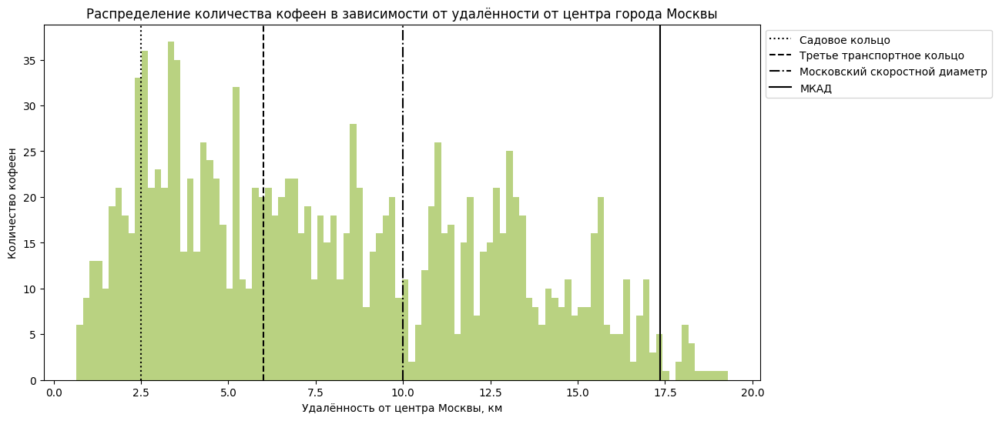

In [148]:
# визуализация распределения количества кофеен в зависимости от удалённости от центра города Москвы
plt.figure(figsize=(12,6))
caf['distance'].hist(bins=100, grid=False, color='#8BB42D', alpha=0.6)
plt.axvline(x=2.5, color='black', linestyle=':', label='Садовое кольцо')
plt.axvline(x=6, color='black', linestyle='--', label='Третье транспортное кольцо')
plt.axvline(x=10, color='black', linestyle='-.', label='Московский скоростной диаметр')
plt.axvline(x=17.35, color='black', linestyle='-', label='МКАД')
plt.legend(bbox_to_anchor = (1,1))
plt.title('Распределение количества кофеен в зависимости от удалённости от центра города Москвы')
plt.xlabel('Удалённость от центра Москвы, км')
plt.ylabel('Количество кофеен')
plt.show()

На графике отчётливо видна тенденция к сокращению количества кофеен по мере роста расстояния от центра Москвы. Стоит также отметить, на графике имеются характерные провалы значений на отметке 6 км, 10 км, 17.5 км. На указанных расстояниях пролегаю автотранспортные кольцевые дороги и обширные парковые, лесопарковые территории.

**Вывод:** В датафрейме представлено 1413 кофеен, что составляет 16.81% численности всех объектов общественного питания Москвы на момент середины 2022 года. Абсолютное большинство кофеен, а именно 428 объекта, располагаются в центральном административном округе. В два раза меньше кофеен в Северном административном округе, но и там показатель существенно выше остальных: 193 кофейни! В Северо-Восточном и Западном административном округах количество кофеен также велико и составляет порядка 150-160 кофеен для каждого. Существенное скопление кофеен отмечается на проспекте Мира, Ленинградском и Ленинском проспектах: на каждой из этих улиц мы выявили от 23 до 36 кофеен.  Если рассматривать вопрос о более тесном соседстве, то по следующим адресам мы видим от 5 до 7 кофеен одновременно:
* ТРЦ «Каширская Плаза», Каширское шоссе, 61Г
* ТРЦ «Метрополис», Ленинградское шоссе, 16Ас4
* ТРК «Авиапарк», Ходынский бульвар, 4
* ТРЦ «Океания», Кутузовский проспект, 57
* ТЦ «ФилиГрад», Береговой проезд, 5А, корп. 1
* ТРЦ «Европейский», площадь Киевского Вокзала, 2
* ТР «Хорошо», Хорошёвское шоссе, 27

Это крупные торгово-развлекательные центры и комплексы, в состав которых входят и бизнес-центры. Идеальное сочетание высокой интенсивности трафика посетителей, комфортный режим работы как самого ТРЦ, так и заведений, расположенных на его площади, благоустройство прилегающей и внутренней территории, наличие больших и удобных рекреационных зон в пределах пешеходной доступности и, безусловно, обеспечение транспортной доступности, делает кофейни в ТРЦ одной из самых экономически выгодных категорий объектов общественного питания.

<a id=4.2></a>
### 4.2. Круглосуточные кофейни

In [149]:
# расчёт количества круглосуточных кофеен в абсолютных значениях
caf['is_24/7'].value_counts().to_frame()

,count
is_24/7,
False,1354
True,59


In [150]:
# расчёт количества круглосуточных кофеен в относительных значениях
round(caf['is_24/7'].value_counts(normalize=True), 2).to_frame()

,proportion
is_24/7,
False,0.96
True,0.04


In [151]:
# создаём отфильтрованный датафрейм с круглосуточными кофейнями
allday_caf = caf[(caf['is_24/7'] == True)]

# выводим характерные черты для этой специфичной группы кофеен
allday_caf.groupby('name').agg({'address':'count', 'rating':'mean', 'seats':'mean', 
                                'middle_coffee_cup':'mean', 'chain':'sum'}).fillna(0).sort_values(by='address', ascending=False)

,address,rating,seats,middle_coffee_cup,chain
name,,,,,
Шоколадница,17,4.19,109.38,261.00,17
Кофемания,8,4.46,110.17,0.00,8
Wild Bean Cafe,6,3.78,12.50,170.00,6
Wild Bean,5,4.06,10.00,170.00,5
Кофе Хауз,3,4.07,100.00,280.00,3
Cofix,2,4.05,200.00,0.00,2
You&coffee,2,4.45,20.00,0.00,2
Кофе с собой,2,4.50,24.00,110.00,2
"One more, please",1,4.30,20.00,230.00,0


In [152]:
# дисклокация круглосуточных кофеен
display(allday_caf['district'].value_counts().head())
allday_caf['street'].value_counts().head(10)

district
Центральный административный округ     26
Западный административный округ         9
Юго-Западный административный округ     7
Северный административный округ         5
Восточный административный округ        5
Name: count, dtype: int64

street
Кутузовский проспект      3
Комсомольская площадь     3
Ленинский проспект        3
Ярославское шоссе         2
Павелецкая площадь        2
Зелёный проспект          2
Кудринская площадь        2
Ленинградский проспект    2
Бутырская улица           1
Долгоруковская улица      1
Name: count, dtype: int64

**Вывод:** 96% кофеен открыты для посетителей по графику и только 4% ориентированы на людей, которых жажда кофе настигля после полуночи. Скромное меньшинство круглосуточных кофеен, а таких объектов на всю Москву насчитывается порядка 60, представлено широко известными и популярными у жителей сетевыми заведениями: признанный лидер `Шоколадница`, `Кофемания`, `Wild Bean Cafe`, `Кофе Хауз`. У каждой из упомянутых сетей как минимум 3 круглосуточных кофейни, а у `Шоколадницы` — все 17.
Из-за круглосуточного режима работы естественным и логичным видится более высокий ценник на чашку кофе: вместо "дневного" варианта в 135-165 рублей "ночные" ценники чаще всего стартуют от отметки в 170 рублей и достигают 280 рублей. У абсолютного большинства круглосуточных кофеен высокий рейтинг и посадка на 50-80 человек. Кофейных полуночников можно встретить, ожидаемо, в Центральном административном округе и чуть реже в Западном и Юго-Западном административных округах. Повышенная концентрация кофеманов отмечатеся на Кутузовском проспекте, Комсомольской площади, Ленинском и Ленинградском проспектах. Вопреки очень узкой специализации, деятельность таких кофеен в контексте налаженного сетевого формата оправдывает себя. На все 280 рублей за чашечку кофе.

<a id=4.3></a>
### 4.3. Рейтинги кофеен в разрезе административных районов


 Описательная статистика рейтингов кофеен в разрезе административных районов: 



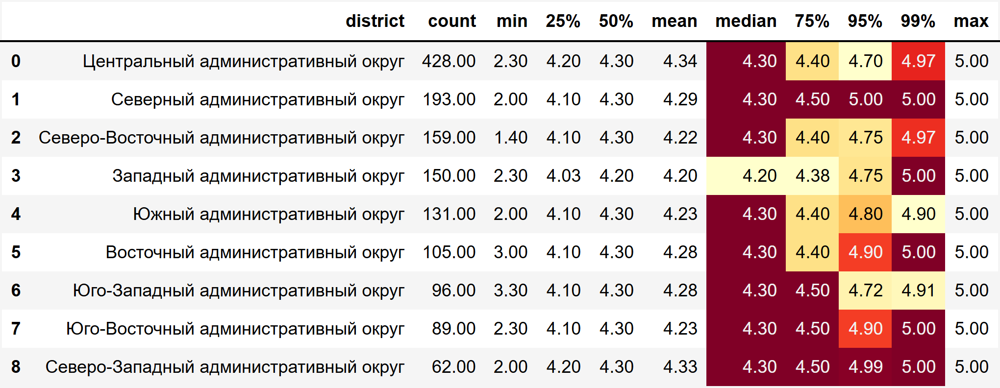

In [153]:
# описательная статистика рейтингов кофеен в разрезе административных районов
caf_rat = caf.groupby('district')['rating'].describe().sort_values(by='count', ascending=False).reset_index()

districts = ['Центральный административный округ', 'Северный административный округ', 'Южный административный округ',
             'Западный административный округ', 'Северо-Восточный административный округ', 'Восточный административный округ',
             'Юго-Западный административный округ', 'Юго-Восточный административный округ', 'Северо-Западный административный округ']

data = {}
for district in districts:
    data[district] = caf.query(f'district == "{district}"')['rating']

# вычисляем медиану и перцентили для каждого округа
medians = [data[district].median() for district in districts]
percentile_95 = [np.percentile(data[district], 95) for district in districts]
percentile_99 = [np.percentile(data[district], 99) for district in districts]

# добавляем данные о медиане и перцентилях в таблицу `caf_rat`
caf_rat['median'] = medians
caf_rat['95%'] = percentile_95
caf_rat['99%'] = percentile_99

# собираем и выводим исчерпывающие статистические данные
styled_table = caf_rat[['district', 'count', 'min', '25%', '50%', 'mean', 'median', '75%', '95%', '99%', 'max']].\
    style.background_gradient(subset=['median', '75%', '95%', '99%'], cmap='YlOrRd').format(precision=2)

# снимаем возможные CSS-ограничения высоты таблицы
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Описательная статистика рейтингов кофеен в разрезе административных районов: \n')

# экспорт изображения
dfi.export(styled_table, 'caf_rat_adm.png', table_conversion='chrome', max_rows=len(seats_by_cat), fontsize=9, dpi=400)

# отображение сохранённого изображения
display(Image(filename='caf_rat_adm.png', width=900))

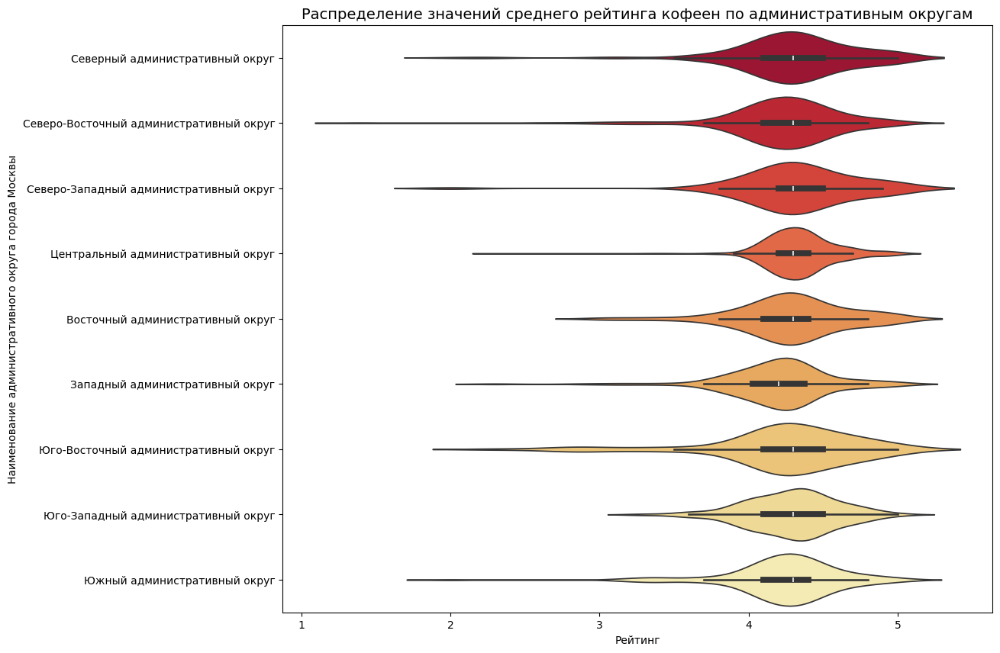

In [154]:
# визуализация распределения средних рейтингов по кофейням
plt.figure(figsize=(12,10))
plt.title('Распределение значений среднего рейтинга кофеен по административным округам', fontsize=14)
sns.violinplot(y=caf['district'], x=caf['rating'], palette='YlOrRd_r');
plt.ylabel('Наименование административного округа города Москвы')
plt.xlabel('Рейтинг')
plt.show()

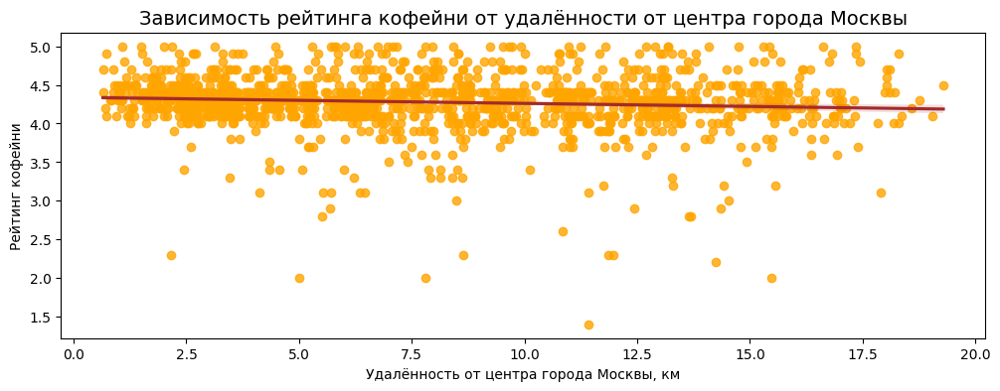

In [155]:
# визуализация зависимости рейтинга кофейни от удалённости от центра Москвы
plt.figure(figsize=(12,4))
sns.regplot(x='distance', y='rating', data=caf, line_kws={'color': 'brown'}, scatter_kws={'color': 'orange'})
plt.title('Зависимость рейтинга кофейни от удалённости от центра города Москвы', fontsize=14)
plt.ylabel('Рейтинг кофейни')
plt.xlabel('Удалённость от центра города Москвы, км')
plt.show()

**Вывод:** рейтинг заведения по своей сути является числовым выражением совокупности факторов, а именно качества обслуживания посетителей, графика работы, времени работы, стоимости блюд и напитков, дислокации заведения и его доступности для маломобильных групп населения, дизайна интерьера и прилегающей территории. Поставленный пользователем звёздный балл так или иначе выражает результирующую оценку силы эмоционального впечатления, полученного по итогу посещения. В разрезе административных округов мы наблюдаем сбалансированное значение рейтинга для каждой территории: средний и медианный рейтинг кофеен крепко держится на отметке 4.2 - 4.3. Это показатель высокого среднего класса заведений.

Высокая пользовательская оценка - явление типичное для Центрального административного округа. Его добрые традиции в этом плане поддердживают заведения в Северном и Северо-Восточном административных округах, где рейтинг выше 4.4 тажке весьма распространённое явление. Для Северного административного округа характерно присутствие крупных спортивных и промышленных объектов (Северный речной вокзал, СК Динамо, арена ЦСКА, заводы и предприятия авиационного, космического, пищевого и строительного профилей). Для Северного административного округа с его агломерацией заводских комплексов характерно одновременное пребывание большого количества людей в типовом рабочем режиме дня, и, следовательно, спрос на заведения общественного питания на этой территории был, есть и будет существенным. Северно-Восточный округ собрал на своей территории большое количество достопримечательностей, что выводит рекреационную функцию этого округа на первое место. Здесь находятся: 
* Выставка достижений народного хозяйства (ВДНХ), многие павильоны которой являются памятниками архитектуры
* Останкинская телебашня и одноимённый телецентр
* Первая в России монорельсовая транспортная система
* Ростокинский акведук
* Усадьба Шереметьевых. Памятник русской архитектуры XVIII века
* Усадьба «Свиблово»
* Главный ботанический сад РАН
* Скульптурная композиция Веры Мухиной «Рабочий и колхозница», стоящая на крыше одноимённого музейно-выставочного центра (с 2017 года центр административно подчинён ВДНХ и считается её павильоном)
* Мемориальный дом-музей академика С. П. Королёва
* Музейно-мемориальный комплекс «Аллея Космонавтов»

Значительное количество жителей и гостей города стремятся посетить этот район, и, безусловно, спрос на заведения общественного питания зедсь будет также стабильно высоким. Одновременно с этим, нами был сформирован перечень топ-15 улиц, на которых расположено самое большое количество заведений общественного питания. Лидер этого списка - Проспект Мира - также пролегает на территории Северо-Восточного округа.

<a id=4.4></a>
### 4.4. На какую стоимость чашки капучино стоит ориентироваться при открытии и почему?

Поскольку перед нами была поставлена задача по формированию рекомендаций в целях открытия кофейни, изучим распределение значения средней стоимости чашки кофе в кофейнях в разрезе административных округов.

In [156]:
# описательная статистика признака `middle_coffee_cup`: выявление аномалий
caf['middle_coffee_cup'].describe()

count    521.00
mean     175.06
std       89.75
min       60.00
25%      124.00
50%      170.00
75%      225.00
max     1568.00
Name: middle_coffee_cup, dtype: float64


 Описательная статистика средней стоимости чашки кофе в разрезе административных районов: 



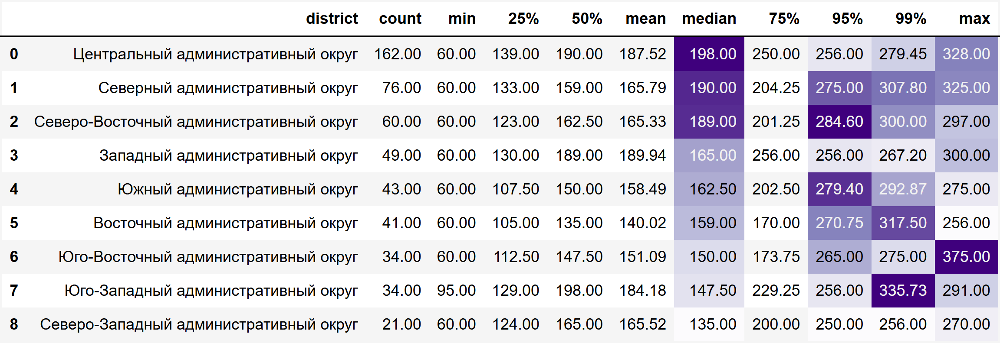

In [157]:
# описательная статисткиа признака `middle_coffee_cup`
# удаляем пропуски значений средней цены и удаляем строки, где была заполнено нулевая цена
caf_price = caf.dropna(subset=['middle_coffee_cup']).reset_index(drop=True)
caf_price = caf.drop(np.where(caf['middle_coffee_cup'] == 0)[0])
caf_price = caf[caf['middle_coffee_cup'] < 1568.0] # удаляем аномальное значение стоимости чашки кофе в 1568 рублей

# описательная статистика стоимости чашки кофе в разрезе административных округов
caf_mid = caf_price.groupby('district')['middle_coffee_cup'].describe().\
sort_values(by='count', ascending=False).reset_index()


# список с названиями округов
districts = ['Юго-Западный административный округ', 'Центральный административный округ', 'Западный административный округ',
             'Северо-Западный административный округ', 'Северо-Восточный административный округ', 'Северный административный округ',
             'Южный административный округ', 'Юго-Восточный административный округ', 'Восточный административный округ']

# создаём словарь с данными о среднем чеке в каждом округе
data = {}
for district in districts:
    data[district] = caf_price.query(f'district == "{district}"')['middle_coffee_cup']

# вычисляем медиану и перцентили для каждого округа
medians = [data[district].median() for district in districts]
percentile_95 = [np.percentile(data[district], 95) for district in districts]
percentile_99 = [np.percentile(data[district], 99) for district in districts]

# добавляем данные о медиане и перцентилях в таблицу `bill`
caf_mid['median'] = medians
caf_mid['95%'] = percentile_95
caf_mid['99%'] = percentile_99

# собираем и выводим исчерпывающие статистические данные
styled_table = caf_mid[['district', 'count', 'min', '25%', '50%', 'mean', 'median', '75%', '95%', '99%', 'max']].\
style.background_gradient(subset = ['median', '95%', '99%', 'max'], cmap='Purples').format(precision=2)

# снимаем возможные CSS-ограничения высоты таблицы
styled_table = styled_table.set_table_styles([{'selector': 'table', 'props': [('height', 'auto'), ('max-height', 'none')]}])

print('\n Описательная статистика средней стоимости чашки кофе в разрезе административных районов: \n')

# экспорт изображения
dfi.export(styled_table, 'caf_mid_price_adm.png', table_conversion='chrome', max_rows=len(seats_by_cat), fontsize=9, dpi=400)

# отображение сохранённого изображения
display(Image(filename='caf_mid_price_adm.png', width=900))


In [158]:
# медианная стоимость чашки кофе в разрезе административных округов
mid_caf = caf.groupby('district').agg({'middle_coffee_cup':'median'}).\
sort_values(by='middle_coffee_cup', ascending=False).reset_index()
mid_caf

,district,middle_coffee_cup
0,Юго-Западный административный округ,198.00
1,Центральный административный округ,190.00
2,Западный административный округ,189.00
3,Северо-Западный административный округ,165.00
4,Северо-Восточный административный округ,162.50
5,Северный административный округ,159.00
6,Южный административный округ,150.00
7,Юго-Восточный административный округ,147.50
8,Восточный административный округ,135.00


In [159]:
# загружаем JSON-файл с границами округов Москвы
state_geo = 'https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson'

# moscow_lat - широта центра Москвы, moscow_lng - долгота центра Москвы
moscow_lat, moscow_lng = 55.751244, 37.618423

# создаём карту Москвы
moscow_cup_caf = Map(location=[moscow_lat, moscow_lng], zoom_start=10)

# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
Choropleth(geo_data=state_geo, data=mid_caf, columns=['district', 'middle_coffee_cup'], 
           key_on='feature.name', fill_color='YlOrBr', fill_opacity=0.6,
    legend_name='Средняя стоимость чашки кофе по административным округам').add_to(moscow_cup_caf)

# выводим фотоновую картограмму
moscow_cup_caf

Очевидным и понятным является факт неравомерного распределения диапазона цен не только в зависимости от административного округа как такового, но и от удалённости кофейни от центра Москвы в разрезе административного округа.

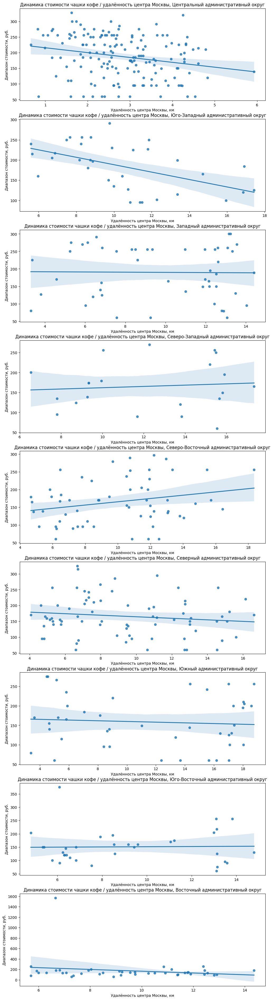

In [160]:
# визуализация зависимости стоимости чашки кофе в зависимости от удалённости от центра Москвы, тенденция по округам
# создадим фигуру и подмножества осей
fig, axs = plt.subplots(9, 1, figsize=(12, 48))

# список названий административных округов
districts = ['Центральный административный округ', 'Юго-Западный административный округ', 'Западный административный округ',
             'Северо-Западный административный округ', 'Северо-Восточный административный округ', 'Северный административный округ',
             'Южный административный округ', 'Юго-Восточный административный округ', 'Восточный административный округ']

# проходим циклом по списку и строим график regplot на каждом подмножестве осей
for i, district in enumerate(districts):
    sns.regplot(x='distance', y='middle_coffee_cup', data=caf.query(f'district == "{district}"'), ax=axs[i])
    axs[i].set_title(f'Динамика стоимости чашки кофе / удалённость центра Москвы, {district}')
    axs[i].set_xlabel('Удалённость центра Москвы, км', fontsize=10)
    axs[i].set_ylabel('Диапазон стоимости, руб.', fontsize=10)

plt.show()

In [161]:
# расчёт динамики цен в зависимости от удалённости от центра Москвы, все категории объектов
rating_mid_km = (rest.query('category != "кофейня"').pivot_table(index='distance', values='middle_avg_bill', aggfunc='mean')).reset_index()
rating_mid_km['distance'] = rating_mid_km['distance'].round()
rating_mid_km = rating_mid_km.groupby('distance').agg({'middle_avg_bill':'mean'}).reset_index()

# расчёт динамики цен в зависимости от удалённости от центра Москвы, все категории объектов
caf_price_km = (rest.query('category != "кофейня"').pivot_table(index='distance', values='middle_coffee_cup', aggfunc='mean')).reset_index()
caf_price_km['distance'] = caf_price_km['distance'].round()
caf_price_km = caf_price_km.groupby('distance').agg({'middle_coffee_cup':'mean'}).reset_index()

rating_mid_km

,distance,middle_avg_bill
0,0.00,1175.00
1,1.00,1382.22
2,2.00,1420.48
3,3.00,1075.84
4,4.00,1114.66
5,5.00,924.12
6,6.00,758.95
7,7.00,788.71
8,8.00,870.96
9,9.00,921.72


In [162]:
# расчёт динамики цен в зависимости от удалённости от центра Москвы, кофейни
caf_rating_mid_km = (rest.query('category=="кофейня"').pivot_table(index='distance', values='middle_avg_bill', aggfunc='mean')).reset_index()
caf_rating_mid_km['distance'] = caf_rating_mid_km['distance'].round()
caf_rating_mid_km = caf_rating_mid_km.groupby('distance').agg({'middle_avg_bill':'mean'}).reset_index()

# расчёт динамики цен в зависимости от удалённости от центра Москвы, кофейни
caf_caf_price_km = (rest.query('category=="кофейня"').pivot_table(index='distance', values='middle_coffee_cup', aggfunc='mean')).reset_index()
caf_caf_price_km['distance'] = caf_caf_price_km['distance'].round()
caf_caf_price_km = caf_caf_price_km.groupby('distance').agg({'middle_coffee_cup':'mean'}).reset_index()

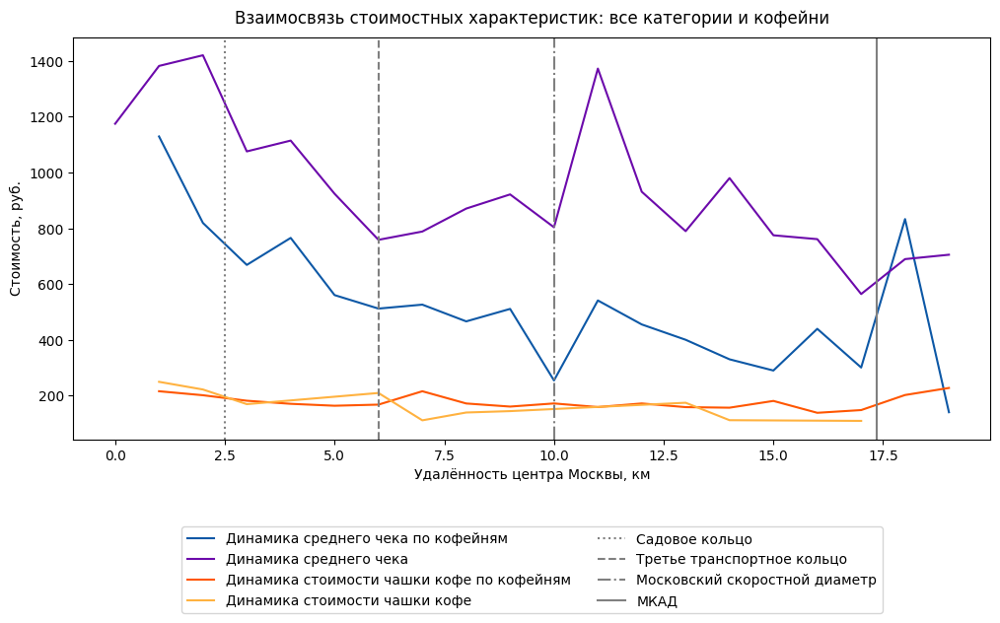

In [163]:
# визуализация динамики стоимости среднего чека и стоимости чашки кофе, кофейни
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(caf_rating_mid_km['distance'], caf_rating_mid_km['middle_avg_bill'], color='#0D58A6',
        label='Динамика среднего чека по кофейням')
ax.plot(rating_mid_km['distance'], rating_mid_km['middle_avg_bill'], color='#6C0AAB',
        label='Динамика среднего чека')
ax.plot(caf_caf_price_km['distance'], caf_caf_price_km['middle_coffee_cup'], color='#FF5600',
        label='Динамика стоимости чашки кофе по кофейням')
ax.plot(caf_price_km['distance'], caf_price_km['middle_coffee_cup'], color='#FFB240',
        label='Динамика стоимости чашки кофе')
plt.axvline(x=2.5, color='gray', linestyle=':', label='Садовое кольцо')
plt.axvline(x=6, color='gray', linestyle='--', label='Третье транспортное кольцо')
plt.axvline(x=10, color='gray', linestyle='-.', label='Московский скоростной диаметр')
plt.axvline(x=17.35, color='gray', linestyle='-', label='МКАД')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.subplots_adjust(bottom=0.20)
ax.set_title('Взаимосвязь стоимостных характеристик: все категории и кофейни', pad=10)
ax.set_xlabel('Удалённость центра Москвы, км')
ax.set_ylabel('Стоимость, руб.')
plt.show();

**Вывод:** 
На основании общего массива данных и профильного среза по категории кофеен, мы получили числовое и визуальное подтверждение умозрительного предположения о наличии взаимосвязи стоимости среднего чека и чашки кофе в зависимости от удалённости от центра города Москвы. И если стоимость блюд сильно зависит от локации объекта питания, то стоимость чашки кофе, словно золотой стандарт, почти не меняется на всей дистанции. Также мы можем утверждать, что для кофеен характерным является средний чек ниже, чем в ресторанах, кафе и прочих категориях общественного питания. 

Стоимость чашки кофе является распространённой метрикой не только качества самого кофе, но и уровня заведения. Мы установили общую тенденцию на увеличение средней стоимости чашки кофе в зависимости от приближения к центру столицы. Эта тенденция носит радиальный характер и распределена в виде круговых сегментов в соответствии с территориальными границами соответствующего административного округа. Наиболее распространённая, и, следовательно, характерная стоимость чашки капучино для ЦАО, САО, СВАО, ЗАО и ЮАО составляет 275 рублей. Авторские напитки здесь будут стоить в пределах 300-330 рублей. Для остальных административных округов картина приблизительно сходная: стоимость чашки капучино на территории ВАО, ЮВАО, ЮЗАО, СЗАО стоимость чашки капучино составит 260 рублей, авторские напитки для ценителей прекрасного обойдётся в 275-300 рублей.
Построенные нами графики линейной зависимости стоимости чашки кофе от удалённости от центра города Москвы. Для ЦАО и ЮЗАО характерна динамика стоимости в пределах ±100 рублей, но эти изменения в масштабах территории ЦАО выглядят очень плавными, а для ЮЗАО эта динамика распространяется на 16 километров протяжённости и выглядит как резкое падение. Сохранение сбалансированной стоимости чашки капучино характерно для ЗАО, СЗАО, САО, ЮАО, ЮВАО, ВАО.

Медианная стоимость капучино в ЦАО составляет 190 ₽, а в ЮЗАО — 198 ₽. Однако, если мы ориентируемся на верхний квартиль (75-й перцентиль) и сегмент авторских напитков, где формируется основная маржа, то целевой диапазон цен для ЦАО составит 275–330 рублей. Для спальных районов (ВАО, ЮВАО) комфортный диапазон — 220–260 рублей.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=5></a>
## Шаг 5. Подготовка презентации
Нами была подготовлена презентация, в которой обозначены ключевые выводы, тезисы и наблюдения, потенциально интересные для инвесторов. 

Презентация: <a href="https://disk.yandex.ru/i/KTE_k7p0HrOmQA">Исследование рынка заведений общественного питания Москвы</a>

<br>[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=6></a>
## Шаг 6. Выводы

**Главные выводы для инвесторов**

1. **Рынок и ниша:** рынок Москвы насыщен (8400+ заведений), лидируют кафе и рестораны. Кофеен ~17%, но именно они показывают самую высокую плотность и маржинальность.
2. **Локация:** абсолютная доминанта — ЦАО (27% рынка). Проспект Мира — главная "кофейная артерия". Альтернатива — зоны фудкортов в крупных ТРЦ (Каширская Плаза, Авиапарк).
3. **Конкуренты:** главные игроки — сети ("Шоколадница", "Cofix", "One Price Coffee"). Средний чек в ЦАО выше, но и конкуренция жестче.
4. **Ценообразование:** медианный капучино стоит ~190 ₽. Чтобы отстроиться от масс-маркета и покрыть аренду в центре, нужно целиться в сегмент 250–300 ₽ (авторские напитки, спешелти).
5. **Зоны роста:** районы с низким рейтингом существующих заведений и слабой конкуренцией (САО, СВАО, СЗАО вне Садового кольца).

## Список использованных источников и литературы

1. <a href="https://bg.ru/bg/business/situation/1521-coffee">Большой город // Соколова А. Стоит ли сейчас открывать кофейню и сколько придётся вложить</a>
2. <a href="https://kontur.ru/press/news/analitica/2022/4/8287">СКБ Контур / Как изменился средний чек в общепите за последние два года</a>
3. <a href="https://journal.tinkoff.ru/coffeehouse/">Тинькофф Журнал // Малютин Н. Сколько стоит открыть кофейню и стоит ли это делать</a>
4. <a href="https://journal.tinkoff.ru/kofe-i-knigi/">Тинькофф Журнал // Горшенин Д. Я мечтал о книжном магазине, открыл кофейню и закрылся через полгода</a>
5. <a href="https://journal.tinkoff.ru/proval-coffee-to-go/">Тинькофф Журнал // Втюрин И. Как я открыл кофейню, заработал деньги и выгорание</a>
6. <a href="https://journal.tinkoff.ru/93gradusa/">Тинькофф Журнал // Сулейманов М. Как потерять миллион рублей на кофейной точке</a>
7. <a href="https://rosretail.com/blog/kak-otkryt-kofejnyu">rosretail.com // Герасимов П. Как открыть кофейню с нуля?</a>
8. <a href="https://topfranchise.ru/biznes-idei/articles/biznes-ideya-kofeyni-poshagovaya-instruktsiya-kak-otkryt-kofeynyu-s-nulya-v-2022-godu/">topfranchise.ru // Правкина К. Бизнес-идея кофейни: пошаговая инструкция, как открыть кофейню с нуля в 2022 году</a>